# **Lojistik Regresyon: YBS Perspektifinden Karar Destek Sistemleri**

**Hazırlayan:** Veri Bilimi ve Makine Öğrenmesi Bootcamp 2026  
**Tarih:** 11 Şubat 2026  
**Hedef Kitle:** Yönetim Bilişim Sistemleri Öğrencileri
## İçindekiler

1. Giriş ve İş Problemi Tanımı
2. Veri Seti Anatomisi
3. Hedef ve Özellik Değişkenlerinin Ayrılması
4. Eğitim-Test Bölme Stratejisi
5. İlk Lojistik Regresyon Modeli
6. Performans Metrikleri
7. Hiperparametre Kavramı
8. Otomatik Parametre Arama
9. Çok Sınıflı Sınıflandırma
10. Dengesiz Veri Problemi
11. Threshold Optimizasyonu
12. Büyük Resim ve YBS Sentezi

# 1. **Giriş ve İş Problemi Tanımı**

## **Senaryo: Bankada Pazarlama Kampanyası**

Bir **bankada veri bilimi uzmanı** olduğunuzu düşünün. Pazarlama departmanı size geliyor ve şu soruyu soruyor:

> **"Yeni bir kampanya başlatıyoruz. Hangi müşteriler bu kampanyaya kaydolur?"**

Bu soru, **YBS açısından** bir **karar destek** sorusudur. Neden?

- **Sınırlı bütçe** var ve bu bütçeyi **doğru müşteriye** harcamak istiyoruz
- Her müşteriyi aramak/e-posta göndermek **maliyet** demek
- Yanlış müşteriye zaman harcamak **fırsat kaybı** demek

## İkili Sınıflandırma (Binary Classification)

Tahmin etmek istediğimiz şey **iki seçenekli**:

- **1** → Müşteri kampanyaya **kaydolur**
- **0** → Müşteri kampanyaya **kaydolmaz**

Bu bir **ikili sınıflandırma** problemidir. 

### Günlük Hayattan Benzetme

Bir arkadaşınıza soruyorsunuz:

> "Bu kişi konsere gelir mi?"

Cevap:
- **Sayı değil** → "15 kişi gelir" gibi değil
- **Evet/Hayır** → "Gelir" veya "Gelmez"

Banka tarafında da **"Kampanyaya katılır mı?"** sorusu aynı mantıktadır.

## **YBS Açısından Kritik Nokta**

**Model, pazarlamanın sezgisel kararını sistematik, ölçülebilir ve tekrar üretilebilir bir kurala dönüştürür.**

| **Eski Yöntem** | **Model Tabanlı Yöntem** |
|-----------------|-------------------------|
| "Bu müşteriyi aradık çünkü içimize öyle doğdu" | "Bu müşteriyi aradık çünkü **model kaydolma olasılığını yüksek buldu**" |
| Sezgisel, tekrar üretilemez | Sistematik, ölçülebilir, tekrar üretilebilir |
| Performans ölçülemez | Her adım dokümante, performans izlenebilir |

Bu standartlaşma, kurum içi **raporlama** ve **performans ölçümü** açısından güçlü bir avantajdır.

## **İş Süreci Akışı**

Aşağıdaki diyagram, lojistik regresyonun bir iş sürecine nasıl entegre edildiğini göstermektedir:

In [3]:
# Mermaid diyagramları için gerekli kütüphane kurulumu
# Not: Bu hücreyi sadece bir kez çalıştırmanız yeterli

try:
    from IPython.display import display, Markdown, HTML
    print("✓ IPython kütüphaneleri hazır")
except ImportError:
    print("✗ IPython kütüphaneleri yüklenemedi")

✓ IPython kütüphaneleri hazır


```mermaid
graph LR
    A["📊 Pazarlama Departmanı<br/>Kampanya Başlatma Kararı"] --> B["🎯 İş Problemi<br/>Hangi müşteriler<br/>kaydolur?"]
    B --> C["💾 Müşteri Veritabanı<br/>Yaş, Bakiye, Memnuniyet<br/>Geçmiş Davranışlar"]
    C --> D["🔧 Lojistik Regresyon<br/>Model Eğitimi"]
    D --> E["📈 Tahmin<br/>Her müşteri için<br/>olasılık hesaplama"]
    E --> F{"🎲 Karar Eşiği<br/>Olasılık > 0.5?"}
    F -->|Evet| G["✅ Kampanya Listesi<br/>Yüksek potansiyelli<br/>müşteriler"]
    F -->|Hayır| H["❌ Kampanya Dışı<br/>Düşük potansiyelli<br/>müşteriler"]
    G --> I["📞 Operasyonel Aksiyon<br/>Arama/E-posta Gönderimi"]
    I --> J["📊 Sonuç Ölçümü<br/>Kaç müşteri kaydoldu?<br/>Model performansı?"]
    J --> K["🔄 Model İyileştirme<br/>Parametre ayarı<br/>Yeni verilerle güncelleme"]
    K --> D

    style A fill:#FFE5E5,stroke:#FF6B6B,stroke-width:3px,color:#000
    style B fill:#FFF4E5,stroke:#FFA94D,stroke-width:3px,color:#000
    style C fill:#E5F4FF,stroke:#4DABF7,stroke-width:3px,color:#000
    style D fill:#F3E5FF,stroke:#CC5DE8,stroke-width:3px,color:#000
    style E fill:#E5FFF4,stroke:#51CF66,stroke-width:3px,color:#000
    style F fill:#FFF9DB,stroke:#FFD43B,stroke-width:3px,color:#000
    style G fill:#D0F4DE,stroke:#38A169,stroke-width:3px,color:#000
    style H fill:#FFD6D6,stroke:#E63946,stroke-width:3px,color:#000
    style I fill:#D4E5FF,stroke:#5C7CFA,stroke-width:3px,color:#000
    style J fill:#FFE8CC,stroke:#FD7E14,stroke-width:3px,color:#000
    style K fill:#E0CFFC,stroke:#9775FA,stroke-width:3px,color:#000
```

## **Organizasyonel Değer**

Lojistik regresyon, organizasyonun **karar süreçlerini veriyle standardize eden** bir bileşen gibi çalışır.

### Faydaları:

1. **📋 Dokümantasyon**: Her karar nedenleriyle birlikte kayıt altında
2. **📊 Ölçülebilirlik**: Performans metrikleriyle sürekli izlenebilir
3. **🔄 Tekrarlanabilirlik**: Aynı girdiyle aynı çıktı her zaman
4. **📈 İyileştirilebilirlik**: Veriye dayalı sürekli geliştirme
5. **🤝 Şeffaflık**: Yöneticilere hesap verilebilir sonuçlar

## **Lojistik Regresyon vs Diğer Yöntemler**

Neden lojistik regresyon kullanıyoruz? Alternatiflere göre avantajları neler?

```mermaid
graph TD
    A["🎯 Tahmin Problemi"] --> B{"Çıktı Tipi?"}
    B -->|"Sürekli Sayı<br/>(Örn: Fiyat, Miktar)"| C["📉 Lineer Regresyon<br/>Çıktı: 0 ile ∞ arası<br/>Örn: Müşteri 250 TL yatırır"]
    B -->|"İki Sınıf<br/>(Evet/Hayır)"| D["✅ Lojistik Regresyon<br/>Çıktı: 0 veya 1<br/>Örn: Müşteri kaydolur/kaydolmaz"]
    B -->|"Çok Sınıf<br/>(3+ Kategori)"| E["🎨 Multi-class Sınıflandırma<br/>Çıktı: 0, 1, 2, ...<br/>Örn: Müşteri Gold/Silver/Bronze"]
    
    D --> F["🔍 Lojistik Regresyon<br/>Özellikleri"]
    F --> G["✓ Olasılık Verir<br/>(0-1 arası)"]
    F --> H["✓ Açıklanabilir<br/>(Hangi özellik önemli?)"]
    F --> I["✓ Hızlı Eğitim<br/>(Büyük veride ölçeklenebilir)"]
    F --> J["✓ Düşük Kompleksite<br/>(Yorumlaması kolay)"]
    
    style A fill:#FFF4E5,stroke:#FFA94D,stroke-width:3px,color:#000
    style B fill:#FFE5E5,stroke:#FF6B6B,stroke-width:3px,color:#000
    style C fill:#E5F4FF,stroke:#4DABF7,stroke-width:2px,color:#000
    style D fill:#D0F4DE,stroke:#38A169,stroke-width:4px,color:#000
    style E fill:#F3E5FF,stroke:#CC5DE8,stroke-width:2px,color:#000
    style F fill:#FFF9DB,stroke:#FFD43B,stroke-width:3px,color:#000
    style G fill:#E0F7FA,stroke:#00ACC1,stroke-width:2px,color:#000
    style H fill:#F1F8E9,stroke:#7CB342,stroke-width:2px,color:#000
    style I fill:#FFF3E0,stroke:#FB8C00,stroke-width:2px,color:#000
    style J fill:#F3E5F5,stroke:#8E24AA,stroke-width:2px,color:#000
```

## **Temel Kütüphanelerin Yüklenmesi**

Lojistik regresyon uygulaması için gerekli Python kütüphanelerini yüklüyoruz:

In [4]:
# Veri işleme ve analiz kütüphaneleri
import pandas as pd              # Veri çerçeveleri (DataFrame) ile çalışmak için
import numpy as np               # Sayısal işlemler ve diziler için

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt  # Grafik çizimi için temel kütüphane
import seaborn as sns            # İstatistiksel görselleştirmeler için

# Uyarıları filtreleme
import warnings
warnings.filterwarnings('ignore')  # Gereksiz uyarı mesajlarını gizle

# Grafik ayarları
plt.rcParams['figure.figsize'] = (10, 6)  # Varsayılan grafik boyutu
plt.rcParams['font.size'] = 10            # Varsayılan yazı boyutu
sns.set_style('whitegrid')                # Seaborn stil ayarı

print("✓ Tüm kütüphaneler başarıyla yüklendi!")
print(f"  • Pandas versiyon: {pd.__version__}")
print(f"  • NumPy versiyon: {np.__version__}")

✓ Tüm kütüphaneler başarıyla yüklendi!
  • Pandas versiyon: 2.3.0
  • NumPy versiyon: 2.3.3


# 2. **Veri Seti Anatomisi**

## **Gerçek Dünya Verisi vs Eğitim Verisi**

Derste kullanılan **`customer.csv`** gibi dosyalar eğitim için özel hazırlanmış olabilir. Bu **"gerçek dışı"** demek değildir!

### **Eğitim Verisinin Özellikleri**

**Neden temiz veriyle başlıyoruz?**

| **Gerçek Dünya Verisi** | **Eğitim Verisi** |
|-------------------------|-------------------|
| Eksik değerler çok | Eksikler giderilmiş |
| Kategorik veriler metin | Sayısal kodlanmış (encoding) |
| Farklı ölçekler | Ölçeklenmiş (scaling) |
| Tutarsızlıklar var | Temizlenmiş |
| KVKK/gizlilik sorunları | Anonimleştirilmiş |

**Amaç**: Önce **algoritmayı anlayalım**, sonra **karmaşayı ekleyelim**!

## **Neden Gerçek Banka Verisi Alamıyoruz?**

Gerçek hayatta banka verisi almak zordur:

- 🔒 **KVKK** (Kişisel Verilerin Korunması Kanunu)
- 🤫 **Gizlilik** politikaları
- 🏢 **Kurum politikaları**
- 📋 **Yasal düzenlemeler**

Bu nedenle eğitimde, **gerçek veri yapısına benzeyen** ama temizlenmiş veriyle başlanır.

## **YBS Açısından Veri Kalitesi**

> **"Veri kalitesi = Karar kalitesi"**

**İki aşamalı yetkinlik:**

1. **Algoritma okuryazarlığı** → Temiz veriyle başlayınca model mantığını net görürsünüz
2. **Veri mühendisliği refleksi** → Kirli veriye geçtiğinizde aynı mantığı veri hazırlama süreçleriyle yönetirsiniz

## **Örnek Veri Seti Oluşturma**

Banka kampanya senaryomuz için örnek bir veri seti oluşturalım:

In [9]:
# Örnek müşteri veri seti oluşturma
# Not: Gerçek banka verisi yerine eğitim amaçlı sentetik veri kullanıyoruz

np.random.seed(42)  # Sonuçların tekrarlanabilirliği için sabit seed

# 12,573 müşteri verisi oluşturuyoruz (büyük ölçekli gerçekçi veri seti)
n_samples = 12573

# Veri seti oluşturma
data = {
    'CustomerID': range(1, n_samples + 1),
    
    # Demografik özellikler
    'Age': np.random.randint(18, 75, n_samples),  # Yaş: 18-75 arası
    
    # Hesap bilgileri (0-1 arası ölçeklenmiş)
    'Balance': np.random.uniform(0, 1, n_samples),  # Hesap bakiyesi temsili
    
    # Müşteri memnuniyeti (1-10 arası)
    'Satisfaction': np.random.randint(1, 11, n_samples),
    
    # İletişim bilgileri (0: E-posta, 1: Telefon, 2: SMS)
    'CommunicationType': np.random.choice([0, 1, 2], n_samples),
    
    # Son aramada konuşma süresi (saniye, 0-600 arası)
    'CallDuration': np.random.randint(0, 600, n_samples),
    
    # Geçmiş kredi sayısı
    'PreviousLoans': np.random.randint(0, 5, n_samples),
    
    # Müşteri segmenti (0: Standart, 1: Premium, 2: VIP)
    'CustomerSegment': np.random.choice([0, 1, 2], n_samples, p=[0.7, 0.2, 0.1]),
    
    # Aylık işlem sayısı
    'MonthlyTransactions': np.random.randint(5, 100, n_samples)
}

# DataFrame oluştur
df = pd.DataFrame(data)

# Hedef değişken: Subscribe (Kampanyaya kaydolma durumu)
# Gerçekçi bir senaryo için bazı özelliklere göre olasılık hesaplıyoruz
# Model başarısı için daha belirgin ayrımlar oluşturuyoruz (accuracy >%70 için)
# Yüksek bakiye, yüksek memnuniyet ve uzun konuşma süresi kaydolma olasılığını artırır

subscribe_probability = (
    0.05 +  # Düşük temel olasılık (daha belirgin ayrım için)
    0.35 * df['Balance'] +  # Bakiye etkisi (artırıldı)
    0.25 * (df['Satisfaction'] / 10) +  # Memnuniyet etkisi (artırıldı)
    0.20 * (df['CallDuration'] / 600) +  # Konuşma süresi etkisi
    0.15 * (df['CustomerSegment'] == 2).astype(int) +  # VIP müşteri bonusu (artırıldı)
    0.10 * (df['CustomerSegment'] == 1).astype(int) +  # Premium müşteri bonusu
    0.08 * (df['MonthlyTransactions'] > 50).astype(int) +  # Aktif müşteri bonusu
    0.07 * (df['Age'] >= 30).astype(int) * (df['Age'] <= 55).astype(int)  # Yaş faktörü (30-55 arası daha muhtemel)
)

# Olasılığı 0-1 arasında sınırla
subscribe_probability = np.clip(subscribe_probability, 0, 1)

# Olasılığa göre 0/1 değeri üret
df['Subscribe'] = (np.random.random(n_samples) < subscribe_probability).astype(int)

print("✓ Örnek veri seti oluşturuldu!")
print(f"  • Toplam müşteri sayısı: {len(df):,}")
print(f"  • Özellik (feature) sayısı: {df.shape[1] - 1}")  # Subscribe hariç
print(f"  • Kampanyaya kaydolan: {df['Subscribe'].sum():,} müşteri ({df['Subscribe'].mean()*100:.1f}%)")
print(f"  • Kaydolmayan: {(1-df['Subscribe']).sum():,} müşteri ({(1-df['Subscribe'].mean())*100:.1f}%)")
print()

# CSV dosyası olarak kaydetme
csv_path = 'bankcustomer.csv'
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f"✅ Veri seti '{csv_path}' olarak kaydedildi!")
print(f"   └─ Konum: {csv_path}")

✓ Örnek veri seti oluşturuldu!
  • Toplam müşteri sayısı: 12,573
  • Özellik (feature) sayısı: 9
  • Kampanyaya kaydolan: 7,182 müşteri (57.1%)
  • Kaydolmayan: 5,391 müşteri (42.9%)

✅ Veri seti 'bankcustomer.csv' olarak kaydedildi!
   └─ Konum: bankcustomer.csv


## **Veri Setini İnceleyelim**

İlk 5 müşteriyi görelim:

In [10]:
# Veri setinin ilk 5 satırı
df.head()

,CustomerID,Age,Balance,Satisfaction,CommunicationType,CallDuration,PreviousLoans,CustomerSegment,MonthlyTransactions,Subscribe
0,1,56,0.573975,1,1,220,1,0,38,1
1,2,69,0.637405,3,0,400,2,1,5,0
2,3,46,0.556709,10,2,59,3,0,13,0
3,4,32,0.738296,7,2,131,3,0,98,1
4,5,60,0.335609,6,1,392,0,0,25,1


## **Sütunların Detaylı Açıklaması**

Her sütun neyi temsil ediyor ve iş açısından önemi nedir?

In [11]:
# Veri seti yapısı hakkında detaylı bilgi
print("=" * 80)
print("VERİ SETİ YAPISI VE SÜTUN AÇIKLAMALARI")
print("=" * 80)
print()

# Her sütunun açıklaması
sutun_aciklamalari = {
    'CustomerID': '🔢 Müşteri Kimlik Numarası - Benzersiz tanımlayıcı (Modelde kullanılmaz)',
    'Age': '👤 Yaş - Müşterinin yaşı (18-75 arası)',
    'Balance': '💰 Hesap Bakiyesi - Normalize edilmiş bakiye temsili (0-1 arası)',
    'Satisfaction': '😊 Memnuniyet Skoru - Müşteri memnuniyet derecesi (1-10 arası)',
    'CommunicationType': '📱 İletişim Tipi - 0:E-posta, 1:Telefon, 2:SMS',
    'CallDuration': '⏱️ Arama Süresi - Son aramada konuşma süresi (saniye)',
    'PreviousLoans': '🏦 Geçmiş Kredi Sayısı - Daha önce kullanılan kredi adedi',
    'CustomerSegment': '⭐ Müşteri Segmenti - 0:Standart, 1:Premium, 2:VIP',
    'MonthlyTransactions': '💳 Aylık İşlem - Bir ayda yapılan işlem sayısı',
    'Subscribe': '🎯 HEDEF - Kampanyaya kaydolma durumu (0:Hayır, 1:Evet)'
}

for sutun, aciklama in sutun_aciklamalari.items():
    veri_tipi = df[sutun].dtype
    eksik = df[sutun].isnull().sum()
    benzersiz = df[sutun].nunique()
    
    print(f"📊 {sutun}")
    print(f"   └─ {aciklama}")
    print(f"   └─ Veri Tipi: {veri_tipi} | Eksik: {eksik} | Benzersiz Değer: {benzersiz}")
    print()

print("=" * 80)

VERİ SETİ YAPISI VE SÜTUN AÇIKLAMALARI

📊 CustomerID
   └─ 🔢 Müşteri Kimlik Numarası - Benzersiz tanımlayıcı (Modelde kullanılmaz)
   └─ Veri Tipi: int64 | Eksik: 0 | Benzersiz Değer: 12573

📊 Age
   └─ 👤 Yaş - Müşterinin yaşı (18-75 arası)
   └─ Veri Tipi: int32 | Eksik: 0 | Benzersiz Değer: 57

📊 Balance
   └─ 💰 Hesap Bakiyesi - Normalize edilmiş bakiye temsili (0-1 arası)
   └─ Veri Tipi: float64 | Eksik: 0 | Benzersiz Değer: 12573

📊 Satisfaction
   └─ 😊 Memnuniyet Skoru - Müşteri memnuniyet derecesi (1-10 arası)
   └─ Veri Tipi: int32 | Eksik: 0 | Benzersiz Değer: 10

📊 CommunicationType
   └─ 📱 İletişim Tipi - 0:E-posta, 1:Telefon, 2:SMS
   └─ Veri Tipi: int64 | Eksik: 0 | Benzersiz Değer: 3

📊 CallDuration
   └─ ⏱️ Arama Süresi - Son aramada konuşma süresi (saniye)
   └─ Veri Tipi: int32 | Eksik: 0 | Benzersiz Değer: 600

📊 PreviousLoans
   └─ 🏦 Geçmiş Kredi Sayısı - Daha önce kullanılan kredi adedi
   └─ Veri Tipi: int32 | Eksik: 0 | Benzersiz Değer: 5

📊 CustomerSegment
   └─ 

## **Veri Seti Yapısı Görselleştirmesi**

Değişkenler arası ilişki ve veri akışı:

```mermaid
graph TD
    A["📁 Müşteri Veritabanı<br/>(customer.csv)<br/>1000 müşteri"] --> B["👤 Demografik<br/>Özellikler"]
    A --> C["💰 Finansal<br/>Özellikler"]
    A --> D["📞 İletişim<br/>Özellikler"]
    A --> E["⭐ Davranışsal<br/>Özellikler"]
    
    B --> B1["Age<br/>(Yaş)"]
    B --> B2["CustomerSegment<br/>(Segment)"]
    
    C --> C1["Balance<br/>(Bakiye Temsili)"]
    C --> C2["PreviousLoans<br/>(Geçmiş Krediler)"]
    
    D --> D1["CommunicationType<br/>(İletişim Tipi)"]
    D --> D2["CallDuration<br/>(Arama Süresi)"]
    
    E --> E1["Satisfaction<br/>(Memnuniyet)"]
    E --> E2["MonthlyTransactions<br/>(Aylık İşlem)"]
    
    B1 --> F["🤖 Lojistik<br/>Regresyon<br/>Modeli"]
    B2 --> F
    C1 --> F
    C2 --> F
    D1 --> F
    D2 --> F
    E1 --> F
    E2 --> F
    
    F --> G["🎯 Tahmin:<br/>Subscribe<br/>(0 veya 1)"]
    
    G --> H["0<br/>Kaydolmaz"]
    G --> I["1<br/>Kaydolur"]
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFF3E0,stroke:#F57C00,stroke-width:2px,color:#000
    style C fill:#E8F5E9,stroke:#388E3C,stroke-width:2px,color:#000
    style D fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#000
    style E fill:#FFF9C4,stroke:#F9A825,stroke-width:2px,color:#000
    style B1 fill:#FFE0B2,stroke:#E64A19,stroke-width:1px,color:#000
    style B2 fill:#FFE0B2,stroke:#E64A19,stroke-width:1px,color:#000
    style C1 fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style C2 fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style D1 fill:#E1BEE7,stroke:#6A1B9A,stroke-width:1px,color:#000
    style D2 fill:#E1BEE7,stroke:#6A1B9A,stroke-width:1px,color:#000
    style E1 fill:#FFF59D,stroke:#F57F17,stroke-width:1px,color:#000
    style E2 fill:#FFF59D,stroke:#F57F17,stroke-width:1px,color:#000
    style F fill:#FFCCBC,stroke:#D84315,stroke-width:4px,color:#000
    style G fill:#B2DFDB,stroke:#00695C,stroke-width:3px,color:#000
    style H fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style I fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
```

## **İstatistiksel Özet**

Sayısal değişkenlerin temel istatistikleri:

In [12]:
# Sayısal değişkenlerin temel istatistikleri
# describe() fonksiyonu: count, mean, std, min, 25%, 50%, 75%, max değerlerini verir

print("📊 SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ")
print("=" * 80)
print()
df.describe().round(2)

📊 SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ



,CustomerID,Age,Balance,Satisfaction,CommunicationType,CallDuration,PreviousLoans,CustomerSegment,MonthlyTransactions,Subscribe
count,12573.00,12573.00,12573.00,12573.00,12573.00,12573.00,12573.00,12573.00,12573.00,12573.00
mean,6287.00,46.03,0.50,5.57,1.01,298.04,1.99,0.40,52.15,0.57
std,3629.66,16.40,0.29,2.85,0.81,171.88,1.41,0.65,27.41,0.49
min,1.00,18.00,0.00,1.00,0.00,0.00,0.00,0.00,5.00,0.00
25%,3144.00,32.00,0.25,3.00,0.00,151.00,1.00,0.00,29.00,0.00
50%,6287.00,46.00,0.50,6.00,1.00,298.00,2.00,0.00,52.00,1.00
75%,9430.00,60.00,0.75,8.00,2.00,443.00,3.00,1.00,76.00,1.00
max,12573.00,74.00,1.00,10.00,2.00,599.00,4.00,2.00,99.00,1.00


## **Kategorik vs Sayısal Değişkenler**

Değişkenleri tipine göre ayırmak önemlidir:

In [13]:
# Değişkenleri türlerine göre ayırma
# Bu ayrım, veri ön işleme ve model kurma aşamalarında çok önemlidir

# Kimlik sütununu hariç tutuyoruz (modelde kullanılmayacak)
id_column = ['CustomerID']

# Hedef değişkeni de feature'lardan ayrı tutuyoruz
target_column = ['Subscribe']

# Kategorik değişkenler: Sınırlı sayıda benzersiz değere sahip
# Genellikle kodlanmış (0, 1, 2 gibi) olsa bile kategorik kabul edilir
categorical_features = ['CommunicationType', 'CustomerSegment']

# Sayısal değişkenler: Sürekli veya geniş aralıklı tam sayı değerler
numerical_features = ['Age', 'Balance', 'Satisfaction', 'CallDuration', 
                      'PreviousLoans', 'MonthlyTransactions']

print("📊 DEĞİŞKEN TİPLERİ")
print("=" * 80)
print()
print(f"🔢 Kimlik Sütunu: {id_column}")
print(f"   └─ Bu sütun modelde kullanılmaz (sadece müşteriyi tanımlamak için)")
print()
print(f"🎯 Hedef Değişken (Target): {target_column}")
print(f"   └─ Bu sütun tahmin edeceğimiz sütundur (y)")
print()
print(f"🏷️ Kategorik Özellikler ({len(categorical_features)} adet): {categorical_features}")
print(f"   └─ Sınırlı sayıda sınıfa ayrılan özellikler")
print()
print(f"📈 Sayısal Özellikler ({len(numerical_features)} adet): {numerical_features}")
print(f"   └─ Sürekli veya geniş aralıklı sayısal özellikler")
print()
print(f"✅ Toplam Özellik Sayısı (X): {len(categorical_features) + len(numerical_features)}")
print("=" * 80)

📊 DEĞİŞKEN TİPLERİ

🔢 Kimlik Sütunu: ['CustomerID']
   └─ Bu sütun modelde kullanılmaz (sadece müşteriyi tanımlamak için)

🎯 Hedef Değişken (Target): ['Subscribe']
   └─ Bu sütun tahmin edeceğimiz sütundur (y)

🏷️ Kategorik Özellikler (2 adet): ['CommunicationType', 'CustomerSegment']
   └─ Sınırlı sayıda sınıfa ayrılan özellikler

📈 Sayısal Özellikler (6 adet): ['Age', 'Balance', 'Satisfaction', 'CallDuration', 'PreviousLoans', 'MonthlyTransactions']
   └─ Sürekli veya geniş aralıklı sayısal özellikler

✅ Toplam Özellik Sayısı (X): 8


## **Hedef Değişkenin Dağılımı**

Kampanyaya kaydolan ve kaydolmayanların oranı ne kadar?

🎯 HEDEF DEĞİŞKEN DAĞILIMI (Subscribe)

❌ Kaydolmayan (0): 5391 müşteri (42.9%)
✅ Kaydolan (1): 7182 müşteri (57.1%)




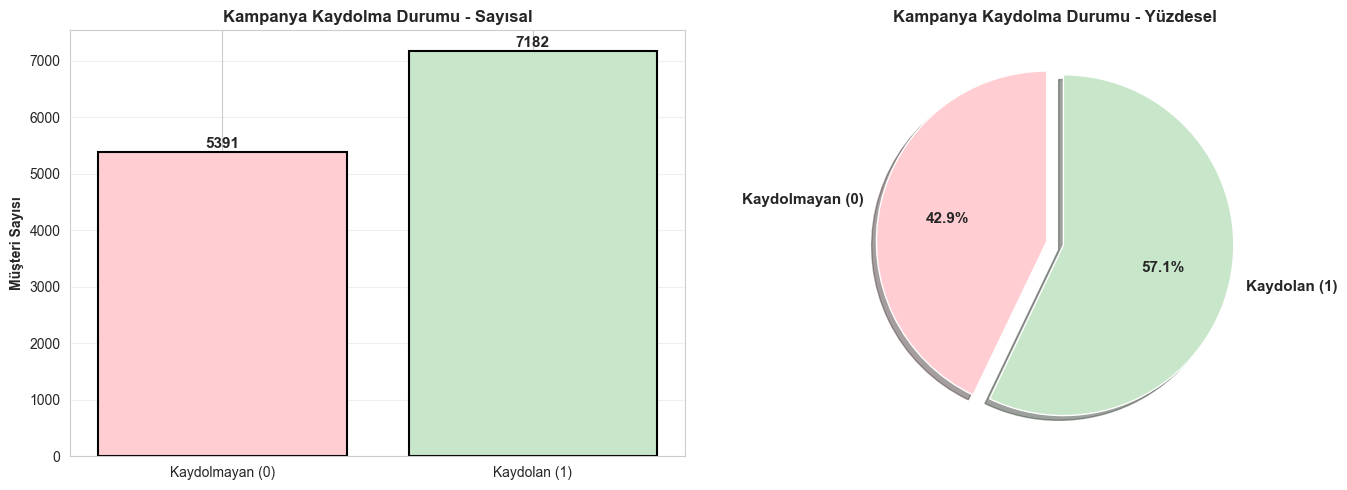

💡 İŞ YORUMU:
────────────────────────────────────────────────────────────────────────────────
Bu dağılım, veri setimizin nispeten dengeli olduğunu gösteriyor.
Hem kaydolan hem kaydolmayan müşteriler yeterli sayıda var.
Bu durum, modelin her iki sınıfı da öğrenmesi için idealdir.

⚠️  Eğer bir sınıf çok az olsaydı (örn: sadece %5 kaydolsaydı),
   bu 'dengesiz veri' (imbalanced data) problemi olurdu.
   Bu durumu ileriki bölümlerde inceleyeceğiz.
────────────────────────────────────────────────────────────────────────────────


In [14]:
# Hedef değişken (Subscribe) dağılımını görselleştirme

# Sayısal dağılım
subscribe_counts = df['Subscribe'].value_counts().sort_index()
subscribe_percent = df['Subscribe'].value_counts(normalize=True).sort_index() * 100

print("🎯 HEDEF DEĞİŞKEN DAĞILIMI (Subscribe)")
print("=" * 80)
print()
print(f"❌ Kaydolmayan (0): {subscribe_counts[0]} müşteri ({subscribe_percent[0]:.1f}%)")
print(f"✅ Kaydolan (1): {subscribe_counts[1]} müşteri ({subscribe_percent[1]:.1f}%)")
print()
print("=" * 80)
print()

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: Bar chart
colors = ['#FFCDD2', '#C8E6C9']  # Pastel kırmızı ve yeşil
axes[0].bar(['Kaydolmayan (0)', 'Kaydolan (1)'], subscribe_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Müşteri Sayısı', fontweight='bold')
axes[0].set_title('Kampanya Kaydolma Durumu - Sayısal', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Her bar üzerine değer yazma
for i, v in enumerate(subscribe_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Sağ grafik: Pie chart
axes[1].pie(subscribe_counts.values, 
            labels=['Kaydolmayan (0)', 'Kaydolan (1)'], 
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05),  # Hafif ayırma
            shadow=True,
            textprops={'fontweight': 'bold', 'fontsize': 11})
axes[1].set_title('Kampanya Kaydolma Durumu - Yüzdesel', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# İş Yorumu
print("💡 İŞ YORUMU:")
print("─" * 80)
print("Bu dağılım, veri setimizin nispeten dengeli olduğunu gösteriyor.")
print("Hem kaydolan hem kaydolmayan müşteriler yeterli sayıda var.")
print("Bu durum, modelin her iki sınıfı da öğrenmesi için idealdir.")
print()
print("⚠️  Eğer bir sınıf çok az olsaydı (örn: sadece %5 kaydolsaydı),")
print("   bu 'dengesiz veri' (imbalanced data) problemi olurdu.")
print("   Bu durumu ileriki bölümlerde inceleyeceğiz.")
print("─" * 80)

## **Encoding ve Scaling Nedir?**

Veri hazırlamada iki önemli kavram:

```mermaid
graph LR
    A["📄 Ham Veri"] --> B{"Veri Tipi?"}
    
    B -->|Kategorik<br/>Metin| C["🔤 Encoding<br/>(Kodlama)"]
    B -->|Sayısal<br/>Farklı Ölçekler| D["📏 Scaling<br/>(Ölçeklendirme)"]
    
    C --> C1["Örnek:<br/>'E-posta' → 0<br/>'Telefon' → 1<br/>'SMS' → 2"]
    D --> D1["Örnek:<br/>Yaş: 18-75<br/>Bakiye: 0-100000<br/>→ Hepsi 0-1 arası"]
    
    C1 --> E["🤖 Model<br/>Girdi Hazır"]
    D1 --> E
    
    E --> F["✅ Eğitim<br/>Başlayabilir"]
    
    style A fill:#FFE0B2,stroke:#E64A19,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#E1BEE7,stroke:#6A1B9A,stroke-width:3px,color:#000
    style D fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style C1 fill:#F3E5F5,stroke:#8E24AA,stroke-width:2px,color:#000
    style D1 fill:#E8F5E9,stroke:#43A047,stroke-width:2px,color:#000
    style E fill:#BBDEFB,stroke:#1565C0,stroke-width:3px,color:#000
    style F fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
```

### 1️⃣ **Encoding (Kodlama)**

**Nedir?** Kategorik (metin) verileri sayısal forma dönüştürmek.

**Neden Gerekli?** Makine öğrenmesi algoritmaları sadece sayılarla çalışır.

**Örnek:**
- **Ham Veri**: "E-posta", "Telefon", "SMS"
- **Kodlanmış**: 0, 1, 2

**Günlük Benzetme:** Sınıftaki öğrencilerin notlarını harften sayıya çevirmek gibi:
- A → 4
- B → 3
- C → 2

### 2️⃣ **Scaling (Ölçeklendirme)**

**Nedir?** Farklı ölçeklerdeki sayısal değerleri ortak bir aralığa getirmek.

**Neden Gerekli?** Bir özellik çok büyük değerler alırsa, model o özelliği daha önemli sanabilir.

**Örnek:**
- **Yaş**: 18-75 arası
- **Hesap Bakiyesi**: 0-100,000 TL arası
- **Memnuniyet**: 1-10 arası

Bu üç özellik farklı ölçeklerde! Bakiye çok büyük olduğu için modeli domine edebilir.

**Çözüm:** Hepsini 0-1 arasına sıkıştırmak:
- Yaş 45 → 0.47 (45-18)/(75-18)
- Bakiye 50,000 → 0.50
- Memnuniyet 5 → 0.56 (5-1)/(10-1)

**Günlük Benzetme:** Elma ile armutları karşılaştırmadan önce ikisini de "meyve puanı" (0-10) sistemine çevirmek gibi.

### Bizim Veri Setimiz

**İyi haber!** Bu eğitim veri setinde:

✅ **Encoding yapılmış**: CommunicationType ve CustomerSegment zaten sayısal (0, 1, 2)  
✅ **Scaling yapılmış**: Balance sütunu zaten 0-1 arasında  
✅ **Eksik veri yok**: Tüm hücreler dolu  
✅ **Temiz ve hazır**: Doğrudan modele verilebilir

Bu sayede **algoritmaya odaklanabiliyoruz**, veri temizliği ile uğraşmıyoruz!

## **Önemli Noktalar**

Bu bölümde öğrendiklerimiz:

| **Kavram** | **Açıklama** | **YBS Değeri** |
|------------|-------------|----------------|
| **Temiz Veri** | Eğitimde algoritma odağı için temiz veriyle başlanır | Gerçek projede veri mühendisliği gerekir |
| **Encoding** | Kategorik → Sayısal dönüşüm | Model metin okuyamaz, sayı ister |
| **Scaling** | Farklı ölçekleri normalize etme | Adil özellik kıyaslaması |
| **Hedef Değişken** | Subscribe = Tahmin edilecek sütun | KPI'ın kendisi |
| **Özellikler** | Yaş, Bakiye, Memnuniyet vb. | KPI'ı açıklayan sürücüler |
| **Veri Kalitesi** | Temiz veri = İyi model | Organizasyonel varlık |

---

### **YBS Perspektifi Hatırlatma**

> **"Veri kalitesi, karar kalitesidir"**

**Kurumsal Gerçeklik:**
- 📊 Gerçek projede veri %80 temizlik, %20 modelleme olabilir
- 🔒 Gizlilik ve yasal zorunluluklar veri erişimini sınırlar
- 🏢 Veri yönetişimi (Data Governance) kritik süreçtir
- 📈 İyi dokümante edilmiş veri = Güvenilir kararlar

**Bu Derste:**
- ✅ Temiz veriyle başladık → Model mantığına odaklandık
- ✅ Gerçek yapıya benzer veri → Transfer edilebilir bilgi
- ✅ Sektör örneği (Banka) → İş bağlamı netliği

# 3. **Hedef ve Özellik Değişkenlerinin Ayrılması (X-y Split)**

## **Makine Öğrenmesinde En Temel Ayrım**

Makine öğrenmesinde en temel ayrım şudur:

> **y (Hedef)** = Tahmin etmek istediğiniz sütun  
> **X (Özellikler)** = Tahmin etmekte kullandığınız sütunlar

Bu senaryoda:
- **y** → **Subscribe** (Kampanyaya kaydolma bilgisi)
- **X** → Subscribe dışındaki her şey (Yaş, Bakiye, Memnuniyet, vb.)

---

## **Günlük Hayattan Benzetme**

Bir öğrencinin **dersten geçip geçmeyeceğini** tahmin ediyorsunuz:

| **Kavram** | **Öğrenci Örneği** | **Banka Örneği** |
|------------|-------------------|------------------|
| **y (Hedef)** | Geçer / Kalır | Kaydolur / Kaydolmaz |
| **X (Özellikler)** | Devamsızlık, Quiz Ortalaması, Ödev Puanı | Yaş, Bakiye, Memnuniyet |

**Kural**: Cevabı soruya karıştırmayın!

Eğer yanlışlıkla **Subscribe'ı X'e dahil ederseniz**, bu "cevabı soruya karıştırmak" olur. Model hile yapar ve gerçek hayatta çalışmaz.

## **YBS Perspektifi: KPI ve Sürücüler**

X-y ayrımı, kurumsal raporlamada **KPI** (Key Performance Indicator) ve **sürücüler** (drivers) ayrımına benzer:

```mermaid
graph TD
    A["📊 İş Problemi<br/>Kampanya Başarı Oranı"] --> B["🎯 KPI<br/>(Hedef Değişken - y)"]
    A --> C["🔧 Sürücüler<br/>(Özellikler - X)"]
    
    B --> B1["Subscribe<br/>(Kaydolur/Kaydolmaz)"]
    
    C --> C1["👤 Demografik<br/>Sürücüler"]
    C --> C2["💰 Finansal<br/>Sürücüler"]
    C --> C3["📞 Davranışsal<br/>Sürücüler"]
    
    C1 --> D1["Age<br/>CustomerSegment"]
    C2 --> D2["Balance<br/>PreviousLoans"]
    C3 --> D3["Satisfaction<br/>CallDuration<br/>MonthlyTransactions<br/>CommunicationType"]
    
    D1 --> E["🤖 Lojistik<br/>Regresyon"]
    D2 --> E
    D3 --> E
    
    B1 --> E
    
    E --> F["📈 Tahmin"]
    F --> G["✅ 0 (Kaydolmaz)"]
    F --> H["✅ 1 (Kaydolur)"]
    
    style A fill:#FFE0B2,stroke:#E64A19,stroke-width:3px,color:#000
    style B fill:#FFCDD2,stroke:#C62828,stroke-width:3px,color:#000
    style C fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style B1 fill:#EF9A9A,stroke:#D32F2F,stroke-width:2px,color:#000
    style C1 fill:#FFF9C4,stroke:#F57F17,stroke-width:2px,color:#000
    style C2 fill:#B2DFDB,stroke:#00695C,stroke-width:2px,color:#000
    style C3 fill:#D1C4E9,stroke:#5E35B1,stroke-width:2px,color:#000
    style D1 fill:#FFF59D,stroke:#F9A825,stroke-width:1px,color:#000
    style D2 fill:#80CBC4,stroke:#00897B,stroke-width:1px,color:#000
    style D3 fill:#B39DDB,stroke:#7E57C2,stroke-width:1px,color:#000
    style E fill:#BBDEFB,stroke:#1565C0,stroke-width:4px,color:#000
    style F fill:#E1BEE7,stroke:#6A1B9A,stroke-width:3px,color:#000
    style G fill:#FFCCBC,stroke:#D84315,stroke-width:2px,color:#000
    style H fill:#A5D6A7,stroke:#388E3C,stroke-width:2px,color:#000
```

### Kurumsal Karar Mantığı

Bu ayrım, kurumsal karar mantığının iskeletidir:

| **Soru** | **KPI (y)** | **Sürücüler (X)** |
|----------|-------------|-------------------|
| Müşteri kaydolur mu? | Subscribe | Yaş, Bakiye, Memnuniyet |
| Çalışan işten ayrılır mı? | Turnover | Maaş, Çalışma Süresi, Memnuniyet |
| Ürün satılır mı? | Sale | Fiyat, Stok, Sezon, Reklam |

**Neden önemli?**

Pazarlama ekibi "**Tamam da neden bu kişiyi seçtin?**" diye soracaktır. Siz de **X değişkenleri** üzerinden gerekçelendireceksiniz:

> "Bu müşteriyi seçtik çünkü:
> - Bakiyesi yüksek (0.85)
> - Memnuniyet skoru yüksek (9/10)
> - Arama süresi uzun (450 saniye)
> - VIP müşteri
> 
> Model bu özelliklerin kaydolma olasılığını %87 olarak hesapladı."

Bu gerekçelendirme, **model açıklanabilirliği** (explainability) açısından hayati önem taşır.

## **X ve y Ayrımını Kod ile Yapalım**

Şimdi veri setimizi **X** (özellikler) ve **y** (hedef) olarak ayıralım:

In [15]:
# X ve y Ayrımı: Makine öğrenmesinin temel adımı
# X = Özellikler (Features), y = Hedef (Target)

print("=" * 80)
print("X ve y AYIRIMI")
print("=" * 80)
print()

# ADIM 1: Hedef değişkeni ayır (y)
# Subscribe sütunu tahmin edeceğimiz değişkendir
y = df['Subscribe']

print("🎯 HEDEF DEĞİŞKEN (y):")
print(f"   └─ Sütun adı: Subscribe")
print(f"   └─ Veri tipi: {y.dtype}")
print(f"   └─ Boyut: {y.shape}")
print(f"   └─ Benzersiz değerler: {y.unique()}")
print(f"   └─ Dağılım:")
print(f"      • 0 (Kaydolmayan): {(y == 0).sum():,} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"      • 1 (Kaydolan): {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.1f}%)")
print()

# ADIM 2: CustomerID sütununu çıkar (Model için gerekli değil)
# CustomerID sadece kimlik bilgisidir, tahmin gücü yoktur
# Bu iş kuralıdır: Kimlik bilgileri modele dahil edilmez

print("🔢 ÇIKARILACAK SÜTUNLAR:")
print("   └─ CustomerID: Müşteri kimlik numarası (model için gereksiz)")
print()

# ADIM 3: Özellikleri ayır (X)
# Subscribe ve CustomerID hariç tüm sütunlar özellik olarak kullanılır
# axis=1 → sütun bazında silme anlamına gelir

X = df.drop(['Subscribe', 'CustomerID'], axis=1)

print("🔧 ÖZELLİKLER (X):")
print(f"   └─ Boyut: {X.shape} (Satır x Sütun)")
print(f"   └─ Toplam özellik sayısı: {X.shape[1]}")
print(f"   └─ Özellik isimleri:")
for i, col in enumerate(X.columns, 1):
    print(f"      {i:2d}. {col}")
print()

print("=" * 80)
print()

# Görsel özet
print("📊 ÖZET:")
print("─" * 80)
print(f"✓ Veri seti boyutu: {df.shape[0]:,} satır x {df.shape[1]} sütun")
print(f"✓ Hedef değişken (y): 1 sütun → Subscribe")
print(f"✓ Özellikler (X): {X.shape[1]} sütun → {', '.join(X.columns.tolist())}")
print(f"✓ Çıkarılan: 1 sütun → CustomerID")
print("─" * 80)

X ve y AYIRIMI

🎯 HEDEF DEĞİŞKEN (y):
   └─ Sütun adı: Subscribe
   └─ Veri tipi: int64
   └─ Boyut: (12573,)
   └─ Benzersiz değerler: [1 0]
   └─ Dağılım:
      • 0 (Kaydolmayan): 5,391 (42.9%)
      • 1 (Kaydolan): 7,182 (57.1%)

🔢 ÇIKARILACAK SÜTUNLAR:
   └─ CustomerID: Müşteri kimlik numarası (model için gereksiz)

🔧 ÖZELLİKLER (X):
   └─ Boyut: (12573, 8) (Satır x Sütun)
   └─ Toplam özellik sayısı: 8
   └─ Özellik isimleri:
       1. Age
       2. Balance
       3. Satisfaction
       4. CommunicationType
       5. CallDuration
       6. PreviousLoans
       7. CustomerSegment
       8. MonthlyTransactions


📊 ÖZET:
────────────────────────────────────────────────────────────────────────────────
✓ Veri seti boyutu: 12,573 satır x 10 sütun
✓ Hedef değişken (y): 1 sütun → Subscribe
✓ Özellikler (X): 8 sütun → Age, Balance, Satisfaction, CommunicationType, CallDuration, PreviousLoans, CustomerSegment, MonthlyTransactions
✓ Çıkarılan: 1 sütun → CustomerID
───────────────────────────

## **X ve y'nin İlk Satırlarını Görelim**

Ayrımın nasıl göründüğüne bakalım:

In [16]:
# X ve y'nin ilk 5 satırını görselleştirme

print("📊 ÖZELLİKLER (X) - İlk 5 Satır:")
print("=" * 80)
display(X.head())
print()

print("🎯 HEDEF DEĞİŞKEN (y) - İlk 5 Değer:")
print("=" * 80)
print(y.head().to_frame())
print()

# X ve y'nin birlikte görünümü
print("🔗 X ve y BİRLİKTE - İlk 5 Satır:")
print("=" * 80)
# X ve y'yi birleştirip gösterelim
combined = X.head().copy()
combined['Subscribe'] = y.head().values
display(combined)
print()

print("💡 NOTLAR:")
print("─" * 80)
print("• X (Özellikler): Model bu değerleri kullanarak tahmin yapacak")
print("• y (Hedef): Model bu değerleri tahmin etmeye çalışacak")
print("• CustomerID çıkarıldı: Kimlik bilgisi tahmin gücü sağlamaz")
print("─" * 80)

📊 ÖZELLİKLER (X) - İlk 5 Satır:


,Age,Balance,Satisfaction,CommunicationType,CallDuration,PreviousLoans,CustomerSegment,MonthlyTransactions
0,56,0.573975,1,1,220,1,0,38
1,69,0.637405,3,0,400,2,1,5
2,46,0.556709,10,2,59,3,0,13
3,32,0.738296,7,2,131,3,0,98
4,60,0.335609,6,1,392,0,0,25



🎯 HEDEF DEĞİŞKEN (y) - İlk 5 Değer:
   Subscribe
0          1
1          0
2          0
3          1
4          1

🔗 X ve y BİRLİKTE - İlk 5 Satır:


,Age,Balance,Satisfaction,CommunicationType,CallDuration,PreviousLoans,CustomerSegment,MonthlyTransactions,Subscribe
0,56,0.573975,1,1,220,1,0,38,1
1,69,0.637405,3,0,400,2,1,5,0
2,46,0.556709,10,2,59,3,0,13,0
3,32,0.738296,7,2,131,3,0,98,1
4,60,0.335609,6,1,392,0,0,25,1



💡 NOTLAR:
────────────────────────────────────────────────────────────────────────────────
• X (Özellikler): Model bu değerleri kullanarak tahmin yapacak
• y (Hedef): Model bu değerleri tahmin etmeye çalışacak
• CustomerID çıkarıldı: Kimlik bilgisi tahmin gücü sağlamaz
────────────────────────────────────────────────────────────────────────────────


## **Neden CustomerID Çıkarıldı?**

**CustomerID** gibi kimlik sütunları **hiçbir zaman** modele dahil edilmemelidir. Neden?

### ❌ **Yanlış Yaklaşım: CustomerID Dahil**

```python
# YANLIŞ! CustomerID dahil edilirse:
X_wrong = df.drop(['Subscribe'], axis=1)  # CustomerID dahil
```

**Sorun**: CustomerID benzersizdir (her müşteri farklı). Model şunu öğrenir:

> "Müşteri 42 kaydoldu, Müşteri 43 kaydolmadı, Müşteri 44 kaydoldu..."

Bu **ezberdir**, genelleme değildir! Yeni bir müşteri (örn: Müşteri 12574) geldiğinde model hiç görmediği için tahmin edemez.

### ✅ **Doğru Yaklaşım: CustomerID Hariç**

```python
# DOĞRU! CustomerID çıkarılır:
X = df.drop(['Subscribe', 'CustomerID'], axis=1)
```

**Model şunu öğrenir**:

> "Yüksek bakiye + Yüksek memnuniyet + VIP segment → Kaydolma olasılığı yüksek"

Bu **genellemedir**! Yeni müşterilere de uygulanabilir.

## **Veri Sızıntısı (Data Leakage) Tehlikesi**

**Veri sızıntısı**: Hedef değişken bilgisinin X'e karışması.

### Tehlikeli Sütun Örnekleri:

| **Sütun** | **Neden Tehlikeli?** |
|-----------|---------------------|
| `SubscriptionDate` | Kaydolma tarihi → Sadece kayıt olanların var! |
| `CampaignResult` | Kampanya sonucu → Bu zaten hedefin başka formu! |
| `FutureBalance` | Gelecek bakiye → Gelecek bilgisi kullanılamaz! |

### Güvenli Sütun Örnekleri:

| **Sütun** | **Neden Güvenli?** |
|-----------|-------------------|
| `Age` | Kampanyadan bağımsız demografi |
| `Balance` | Kampanya öncesi bakiye |
| `Satisfaction` | Geçmiş memnuniyet skoru |

### **YBS Açısından Veri Sızıntısı**

Kurumsal sistemlerde veri sızıntısı **yüksek accuracy yanılsaması** yaratır:

**Senaryo**: Model geliştirme aşamasında %99 accuracy alıyorsunuz, ama canlıya alınca %60'a düşüyor!

**Sebep**: Test verisinde hedefle ilişkili bir sütun vardı ama gerçek hayatta o bilgi yok.

**Örnek**: "Son 3 ayda kampanyaya tıklama sayısı" → Bu bilgi kampanya öncesi yoktur!

Bu yüzden **veri seçimi bir iş kuralıdır**, sadece teknik bir adım değildir.

## **Veri Sızıntısı Görselleştirmesi**

```mermaid
graph TD
    A["📊 Tüm Veri Seti"] --> B{"Sütun Türü?"}
    
    B -->|"❌ Kimlik Bilgisi"| C1["CustomerID<br/>OrderID<br/>TransactionID"]
    B -->|"❌ Hedef Bilgisi"| C2["Subscribe<br/>(Tahmin edilecek)"]
    B -->|"❌ Veri Sızıntısı Riski"| C3["SubscriptionDate<br/>CampaignResult<br/>FutureBalance"]
    B -->|"✅ Kullanılabilir Özellik"| C4["Age<br/>Balance<br/>Satisfaction<br/>CallDuration"]
    
    C1 --> D1["🚫 ÇIKAR<br/>Ezber yaratır"]
    C2 --> D2["🚫 ÇIKAR<br/>Bu hedefin ta kendisi"]
    C3 --> D3["🚫 ÇIKAR<br/>Hedefle ilişkili bilgi"]
    C4 --> D4["✅ KULLAN<br/>Bağımsız özellikler"]
    
    D1 --> E["❌ Modele<br/>Dahil Etme"]
    D2 --> E
    D3 --> E
    
    D4 --> F["✅ X<br/>(Özellikler)"]
    C2 --> G["✅ y<br/>(Hedef)"]
    
    F --> H["🤖 Model<br/>Eğitimi"]
    G --> H
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C1 fill:#FFCCBC,stroke:#D84315,stroke-width:2px,color:#000
    style C2 fill:#F8BBD0,stroke:#C2185B,stroke-width:2px,color:#000
    style C3 fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style C4 fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style D1 fill:#FFAB91,stroke:#BF360C,stroke-width:2px,color:#000
    style D2 fill:#F48FB1,stroke:#880E4F,stroke-width:2px,color:#000
    style D3 fill:#EF9A9A,stroke:#B71C1C,stroke-width:2px,color:#000
    style D4 fill:#A5D6A7,stroke:#1B5E20,stroke-width:2px,color:#000
    style E fill:#FFCDD2,stroke:#C62828,stroke-width:3px,color:#000
    style F fill:#B2DFDB,stroke:#00695C,stroke-width:3px,color:#000
    style G fill:#E1BEE7,stroke:#6A1B9A,stroke-width:3px,color:#000
    style H fill:#BBDEFB,stroke:#1565C0,stroke-width:4px,color:#000
```

## **X-y Ayrımının Farklı Yöntemleri**

Python/Pandas ile X-y ayrımı yapmanın birkaç yolu vardır:

In [17]:
# X-y Ayrımının Farklı Yöntemleri

print("=" * 80)
print("X-y AYRIMININ FARKLI YÖNTEMLERİ")
print("=" * 80)
print()

# YÖNTEM 1: drop() ile çıkarma (En yaygın)
print("📌 YÖNTEM 1: drop() ile çıkarma")
print("─" * 80)
y_method1 = df['Subscribe']
X_method1 = df.drop(['Subscribe', 'CustomerID'], axis=1)
print(f"y boyutu: {y_method1.shape}")
print(f"X boyutu: {X_method1.shape}")
print("Kod: X = df.drop(['Subscribe', 'CustomerID'], axis=1)")
print("Avantaj: Okunabilir, birden fazla sütun çıkarmak kolay")
print()

# YÖNTEM 2: Sütun seçimi ile (Belirli sütunları seçmek)
print("📌 YÖNTEM 2: Sütun isimleriyle seçim")
print("─" * 80)
feature_columns = ['Age', 'Balance', 'Satisfaction', 'CommunicationType', 
                   'CallDuration', 'PreviousLoans', 'CustomerSegment', 'MonthlyTransactions']
y_method2 = df['Subscribe']
X_method2 = df[feature_columns]
print(f"y boyutu: {y_method2.shape}")
print(f"X boyutu: {X_method2.shape}")
print("Kod: X = df[feature_columns]")
print("Avantaj: Hangi özelliklerin kullanıldığı net görünür")
print()

# YÖNTEM 3: .loc ile seçim
print("📌 YÖNTEM 3: .loc ile seçim")
print("─" * 80)
y_method3 = df.loc[:, 'Subscribe']
X_method3 = df.loc[:, feature_columns]
print(f"y boyutu: {y_method3.shape}")
print(f"X boyutu: {X_method3.shape}")
print("Kod: X = df.loc[:, feature_columns]")
print("Avantaj: Satır ve sütun seçiminde esneklik")
print()

# Tüm yöntemlerin eşit olduğunu doğrulama
print("✅ DOĞRULAMA:")
print("─" * 80)
print(f"Tüm yöntemler aynı X boyutunu verir: {X_method1.shape == X_method2.shape == X_method3.shape}")
print(f"Tüm yöntemler aynı y boyutunu verir: {y_method1.shape == y_method2.shape == y_method3.shape}")
print()

print("💡 ÖNCE: En yaygın kullanılan Yöntem 1'dir (drop ile çıkarma)")
print("=" * 80)

X-y AYRIMININ FARKLI YÖNTEMLERİ

📌 YÖNTEM 1: drop() ile çıkarma
────────────────────────────────────────────────────────────────────────────────
y boyutu: (12573,)
X boyutu: (12573, 8)
Kod: X = df.drop(['Subscribe', 'CustomerID'], axis=1)
Avantaj: Okunabilir, birden fazla sütun çıkarmak kolay

📌 YÖNTEM 2: Sütun isimleriyle seçim
────────────────────────────────────────────────────────────────────────────────
y boyutu: (12573,)
X boyutu: (12573, 8)
Kod: X = df[feature_columns]
Avantaj: Hangi özelliklerin kullanıldığı net görünür

📌 YÖNTEM 3: .loc ile seçim
────────────────────────────────────────────────────────────────────────────────
y boyutu: (12573,)
X boyutu: (12573, 8)
Kod: X = df.loc[:, feature_columns]
Avantaj: Satır ve sütun seçiminde esneklik

✅ DOĞRULAMA:
────────────────────────────────────────────────────────────────────────────────
Tüm yöntemler aynı X boyutunu verir: True
Tüm yöntemler aynı y boyutunu verir: True

💡 ÖNCE: En yaygın kullanılan Yöntem 1'dir (drop ile çıkarm

## **Önemli Noktalar**

Bu bölümde öğrendiklerimiz:

| **Kavram** | **Açıklama** | **YBS Önemi** |
|------------|-------------|---------------|
| **X (Özellikler)** | Tahmin için kullanılan değişkenler | İş süreçlerindeki sürücüler (drivers) |
| **y (Hedef)** | Tahmin edilmek istenen değişken | İş süreçlerindeki KPI |
| **drop() fonksiyonu** | Belirtilen sütunları çıkarır | Veri hazırlama standardı |
| **axis=1** | Sütun bazında işlem yapar | Pandas syntax kuralı |
| **CustomerID çıkarma** | Kimlik bilgisi modele dahil edilmez | Ezber önleme |
| **Veri Sızıntısı** | Hedef bilgisinin X'e karışması | Model yanılsaması riski |

### **YBS Perspektifi: X-y Ayrımı = Süreç Tasarımı**

Bu ayrım sadece kod satırı değil, **kurumsal karar mantığının iskeletidir**:

**Soru**: "Müşteri kampanyaya kaydolur mu?"

**Cevap Yapısı**:
- **KPI (y)**: Kaydolma durumu (0/1)
- **Sürücüler (X)**: Yaş, Bakiye, Memnuniyet, Segment, vb.

Pazarlama ekibi soracak: **"Peki neden bu müşteriyi seçtin?"**

Sizin cevabınız **X değişkenlerine dayanacak**:

> "Bu müşteriyi seçtik çünkü:
> - **Balance**: 0.89 (yüksek bakiye)
> - **Satisfaction**: 9/10 (çok memnun)
> - **CustomerSegment**: 2 (VIP)
> - **CallDuration**: 480 saniye (uzun konuşma)
> 
> Model bu profilde kaydolma olasılığını **%91** buldu."

Bu **model açıklanabilirliği** ve **iş gerekçelendirmesi** demektir.

### **Kritik Hatırlatma**

**❌ Asla yapmayın:**
```python
X = df.drop(['Subscribe'], axis=1)  # CustomerID dahil kalır → YANLIŞ!
```

**✅ Doğru yaklaşım:**
```python
X = df.drop(['Subscribe', 'CustomerID'], axis=1)  # Hem hedef hem kimlik çıkar
```

veya daha güvenli:

```python
# Sadece kullanılacak özellikleri seç
feature_columns = ['Age', 'Balance', 'Satisfaction', ...]
X = df[feature_columns]
```

# 4. **Eğitim-Test Bölme Stratejisi (Train-Test Split)**

## **Modeli Nasıl Test Ederiz?**

**Kritik Soru**: Model gerçekten işe yarıyor mu, yoksa sadece **ezber** mi yapıyor?

### **Günlük Hayattan Benzetme: Sınav Analojisi**

Bir öğrenci sınava hazırlanıyor:

| **Eğitim (Train)** | **Test** |
|-------------------|---------|
| Çözüm anahtarını bildiği sorularla çalışma | Hiç görmediği yeni sorular |
| Aynı soruları tekrar tekrar çözme | Gerçek yetenek ölçümü |
| **Ezber** riski var | **Genelleme** yeteneği test edilir |

**Model için aynı mantık geçerli**:

- **Eğitim verisi**: Modelin öğrenme yaptığı alan
- **Test verisi**: Modelin "hiç görmediği" müşteriler gibi davranır

## **Ezber vs Genelleme**

```mermaid
graph LR
    A["📊 Tüm Veri Seti<br/>12,573 müşteri"] --> B["✂️ Veri Bölme<br/>(Split)"]
    
    B --> C["📚 Eğitim Seti<br/>(Train Set)<br/>70-80%"]
    B --> D["🧪 Test Seti<br/>(Test Set)<br/>20-30%"]
    
    C --> E["🤖 Model<br/>Eğitimi"]
    E --> F["📖 Model<br/>Öğrenir"]
    
    F --> G["Model bu veride<br/>pattern'leri keşfeder"]
    
    D --> H["✅ Model<br/>Değerlendirme"]
    
    F --> H
    
    H --> I{"Sonuç?"}
    
    I -->|"Eğitim: %95<br/>Test: %92"| J["✅ İyi Genelleme<br/>Model gerçekten öğrenmiş"]
    I -->|"Eğitim: %99<br/>Test: %65"| K["❌ Ezber (Overfitting)<br/>Model sadece ezber yapmış"]
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style D fill:#FFE0B2,stroke:#E64A19,stroke-width:3px,color:#000
    style E fill:#BBDEFB,stroke:#1565C0,stroke-width:3px,color:#000
    style F fill:#B2DFDB,stroke:#00695C,stroke-width:3px,color:#000
    style G fill:#E0F2F1,stroke:#00796B,stroke-width:2px,color:#000
    style H fill:#F3E5F5,stroke:#7B1FA2,stroke-width:3px,color:#000
    style I fill:#FFF3E0,stroke:#FB8C00,stroke-width:3px,color:#000
    style J fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style K fill:#FFCDD2,stroke:#C62828,stroke-width:3px,color:#000
```

### **İki Senaryo:**

**Senaryo 1: İyi Model (Genelleme)**
- Eğitim seti accuracy: %92
- Test seti accuracy: %90
- **Yorum**: Model öğrenmiş, yeni veride de çalışıyor ✅

**Senaryo 2: Ezberci Model (Overfitting)**
- Eğitim seti accuracy: %99
- Test seti accuracy: %65
- **Yorum**: Model ezber yapmış, yeni veride başarısız ❌

## **YBS Perspektifi: Üretim Ortamını Simüle Etmek**

Test seti, **canlı sistemde (deployment)** olacak şeyi simüle eder:

### **Zaman Çizelgesi**

```mermaid
gantt
    title Model Yaşam Döngüsü
    dateFormat YYYY-MM-DD
    section Geliştirme
    Veri Toplama           :a1, 2026-01-01, 7d
    Veri Hazırlama         :a2, after a1, 5d
    Train-Test Split       :a3, after a2, 1d
    Model Eğitimi (Train)  :a4, after a3, 3d
    Model Testi (Test)     :crit, a5, after a4, 2d
    section Canlı
    Deployment             :b1, after a5, 1d
    Yeni Müşteriler        :active, b2, after b1, 30d
    Model Güncelleme       :b3, after b2, 3d
```

**Gerçek Hayatta**:
- **Eğitim**: Geçmiş 6 aylık müşteri verisi (örn: 2025 Temmuz-Aralık)
- **Test**: Son 1 aylık veri (örn: 2026 Ocak)
- **Canlı**: Şubat ayında gelen yeni müşteriler

Test seti, "gelecekte göreceği verileri" temsil eder. Bu yüzden **asla** test setini eğitimde kullanmamalısınız!

## **random_state Parametresi Neden Önemli?**

Test seti **rastgele** seçilir, ama bu rastgelelik **tekrarlanabilir** olmalıdır.

### **random_state Olmadan:**

```python
# KÖTÜ UYGULAMA (random_state yok)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
```

**Sorun**: Her çalıştırışınızda **farklı** veriler seçilir!

| **Çalışma** | **Test Accuracy** | **Sonuç** |
|-------------|------------------|-----------|
| 1. çalışma | %89 | ? |
| 2. çalışma | %91 | ? |
| 3. çalışma | %87 | ? |

**Hangisi doğru?** Karşılaştırma yapamıyorsunuz!

### random_state ile:

```python
# İYİ UYGULAMA (random_state var)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

**Avantaj**: Her çalıştırışınızda **aynı** veriler seçilir!

| **Çalışma** | **Test Accuracy** | **Sonuç** |
|-------------|------------------|-----------|
| 1. çalışma | %89 | ✅ |
| 2. çalışma | %89 | ✅ (Aynı) |
| 3. çalışma | %89 | ✅ (Aynı) |

**Tekrarlanabilir** sonuçlar elde edersiniz!

## **YBS Açısından Tekrarlanabilirlik**

**Kurumsal gerçeklik**: Aynı veriyle aynı deney tekrarlandığında **aynı çıktıyı** almak istiyorsunuz.

**Senaryo**: Pazarlama müdürüne sunum yapıyorsunuz:
- **Pazartesi**: "Model %89 accuracy veriyor"
- **Salı**: (Aynı veriyle tekrar çalıştırdınız) "Model %87 accuracy veriyor"

**Müdür**: "Dün %89 dedin, bugün %87. Hangisine inanacağım?"

**Cevap**: random_state kullanmazsanız, sonuçlar her seferinde değişir. Bu **güven kaybı** yaratır.

### **random_state = Denetlenebilirlik**

- ✅ Aynı sonuçları tekrar üretebilme
- ✅ Hata ayıklama kolaylığı
- ✅ Takım içi tutarlılık
- ✅ Raporlama güvenilirliği

**Not**: random_state değeri (42, 123, vb.) önemli değil. Önemli olan **sabitleme**.

## **Train-Test Split Uygulama**

Şimdi verimizi eğitim ve test setlerine bölelim:

In [18]:
# Train-Test Split: Veriyi eğitim ve test setlerine bölme
# sklearn kütüphanesinden train_test_split fonksiyonunu kullanacağız

from sklearn.model_selection import train_test_split

print("=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)
print()

# ADIM 1: Bölme oranını belirle
# test_size=0.3 → %30'u test, %70'i eğitim
# test_size=0.2 → %20'si test, %80'i eğitim (daha yaygın)

TEST_SIZE = 0.25  # %25 test, %75 eğitim
RANDOM_STATE = 42  # Tekrarlanabilirlik için sabit değer

print(f"📊 BÖLME PARAMETRELERİ:")
print(f"   └─ Test oranı: {TEST_SIZE*100:.0f}%")
print(f"   └─ Eğitim oranı: {(1-TEST_SIZE)*100:.0f}%")
print(f"   └─ random_state: {RANDOM_STATE}")
print()

# ADIM 2: X ve y'yi hatırlayalım
print(f"📦 GİRDİ VERİLERİ:")
print(f"   └─ X boyutu: {X.shape} (Özellikler)")
print(f"   └─ y boyutu: {y.shape} (Hedef)")
print()

# ADIM 3: Bölme işlemi
# train_test_split fonksiyonu 4 çıktı verir:
# X_train: Eğitim özellikleri
# X_test: Test özellikleri
# y_train: Eğitim hedefleri
# y_test: Test hedefleri

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y  # Hedef değişken dağılımını korumak için
)

print("✅ VERİ BAŞARIYLA BÖLÜNDÜ!")
print()

# ADIM 4: Sonuçları kontrol et
print("📈 BÖLME SONUÇLARI:")
print("─" * 80)
print(f"Eğitim Seti (Train):")
print(f"   └─ X_train: {X_train.shape} ({X_train.shape[0]:,} müşteri x {X_train.shape[1]} özellik)")
print(f"   └─ y_train: {y_train.shape} ({y_train.shape[0]:,} etiket)")
print(f"   └─ y_train dağılımı:")
print(f"      • 0 (Kaydolmayan): {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"      • 1 (Kaydolan): {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")
print()

print(f"Test Seti (Test):")
print(f"   └─ X_test: {X_test.shape} ({X_test.shape[0]:,} müşteri x {X_test.shape[1]} özellik)")
print(f"   └─ y_test: {y_test.shape} ({y_test.shape[0]:,} etiket)")
print(f"   └─ y_test dağılımı:")
print(f"      • 0 (Kaydolmayan): {(y_test == 0).sum():,} ({(y_test == 0).sum() / len(y_test) * 100:.1f}%)")
print(f"      • 1 (Kaydolan): {(y_test == 1).sum():,} ({(y_test == 1).sum() / len(y_test) * 100:.1f}%)")
print()

# ADIM 5: Doğrulama
total_train = len(X_train)
total_test = len(X_test)
total_all = len(X)

print("✅ DOĞRULAMA:")
print("─" * 80)
print(f"Toplam veri: {total_all:,}")
print(f"Eğitim + Test: {total_train:,} + {total_test:,} = {total_train + total_test:,}")
print(f"Eşit mi? {total_train + total_test == total_all}")
print(f"Test oranı: {total_test / total_all * 100:.1f}% (Hedef: {TEST_SIZE*100:.0f}%)")
print("=" * 80)

TRAIN-TEST SPLIT

📊 BÖLME PARAMETRELERİ:
   └─ Test oranı: 25%
   └─ Eğitim oranı: 75%
   └─ random_state: 42

📦 GİRDİ VERİLERİ:
   └─ X boyutu: (12573, 8) (Özellikler)
   └─ y boyutu: (12573,) (Hedef)

✅ VERİ BAŞARIYLA BÖLÜNDÜ!

📈 BÖLME SONUÇLARI:
────────────────────────────────────────────────────────────────────────────────
Eğitim Seti (Train):
   └─ X_train: (9429, 8) (9,429 müşteri x 8 özellik)
   └─ y_train: (9429,) (9,429 etiket)
   └─ y_train dağılımı:
      • 0 (Kaydolmayan): 4,043 (42.9%)
      • 1 (Kaydolan): 5,386 (57.1%)

Test Seti (Test):
   └─ X_test: (3144, 8) (3,144 müşteri x 8 özellik)
   └─ y_test: (3144,) (3,144 etiket)
   └─ y_test dağılımı:
      • 0 (Kaydolmayan): 1,348 (42.9%)
      • 1 (Kaydolan): 1,796 (57.1%)

✅ DOĞRULAMA:
────────────────────────────────────────────────────────────────────────────────
Toplam veri: 12,573
Eğitim + Test: 9,429 + 3,144 = 12,573
Eşit mi? True
Test oranı: 25.0% (Hedef: 25%)


## **stratify Parametresi Nedir?**

**stratify=y** parametresi, hedef değişken dağılımını **her iki sette de korur**.

### **stratify Olmadan:**

```python
# Stratify YOK
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
```

**Risk**: Test setinde sınıf dengesizliği olabilir!

| **Set** | **0 (Kaydolmayan)** | **1 (Kaydolan)** |
|---------|---------------------|------------------|
| Tüm Veri | %47 | %53 |
| Train | %50 | %50 |
| Test | %35 | %65 | ← **Dengesiz!**

### **stratify ile:**

```python
# Stratify VAR
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
```

**Avantaj**: Her iki sette de dağılım korunur!

| **Set** | **0 (Kaydolmayan)** | **1 (Kaydolan)** |
|---------|---------------------|------------------|
| Tüm Veri | %47 | %53 |
| Train | %47 | %53 | ← **Dengeli!**
| Test | %47 | %53 | ← **Dengeli!**

### **Neden Önemli?**

Test setinin **gerçeği temsil etmesi** gerekir. Eğer gerçek hayatta %50-%50 dağılım varsa, test setinde de aynı olmalı.

## **Train-Test Split Görselleştirmesi**

Veri bölünmesini görsel olarak inceleyelim:

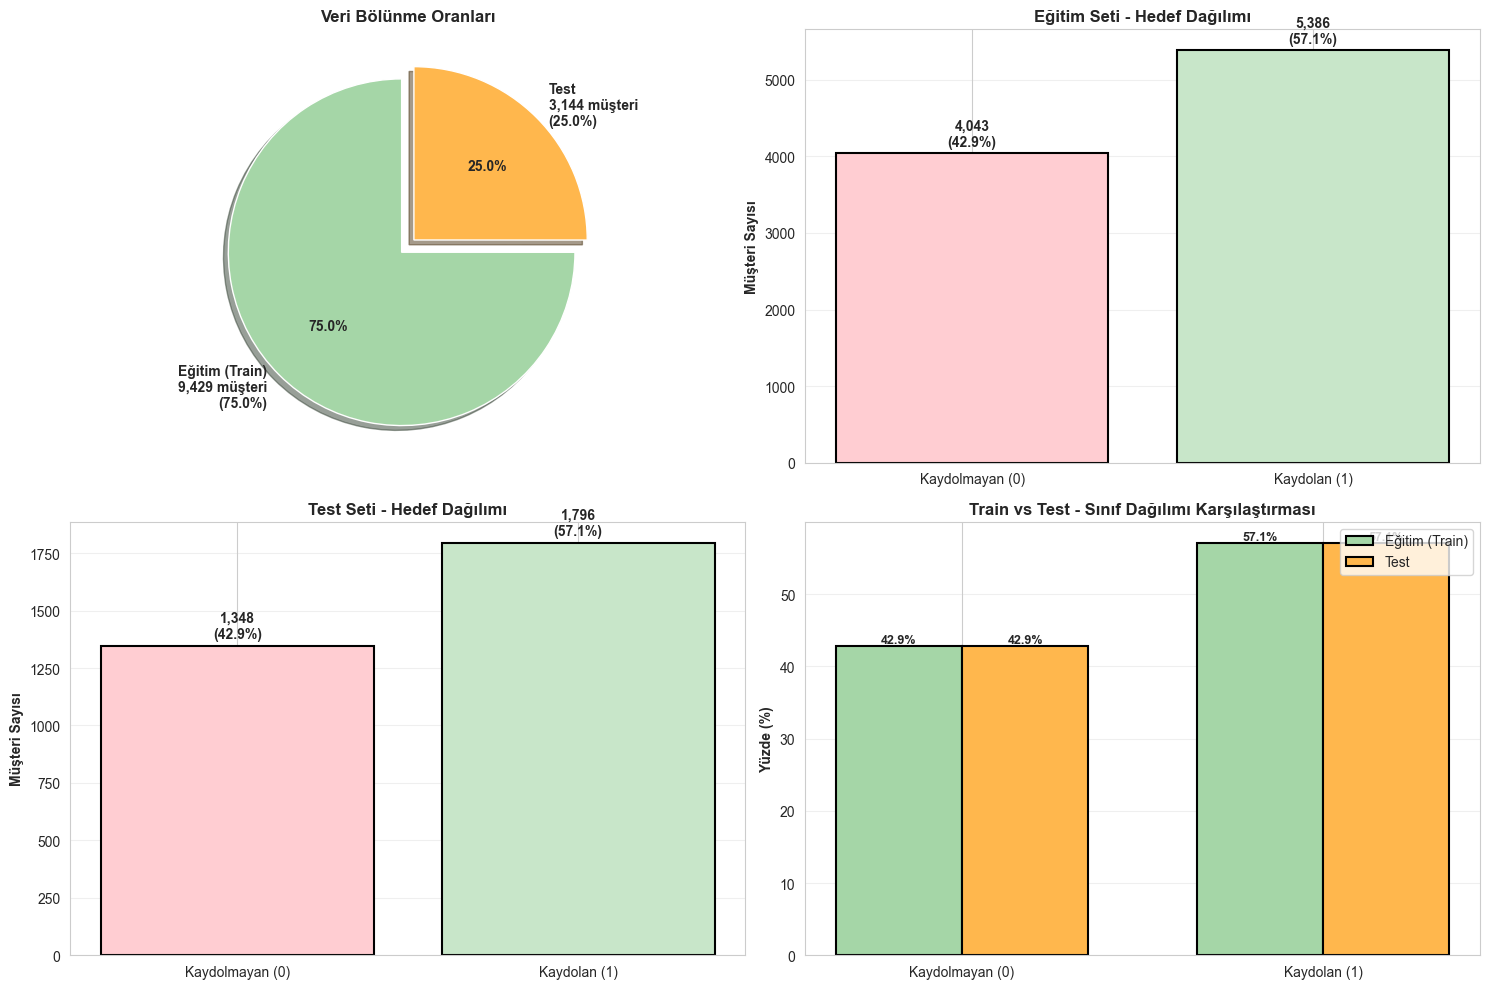


💡 GÖZLEM:
────────────────────────────────────────────────────────────────────────────────
✅ stratify=y kullandığımız için Train ve Test setlerinde
   sınıf dağılımları neredeyse aynı (dengeli).

✅ Bu, modelin adil bir şekilde test edilmesini sağlar.
────────────────────────────────────────────────────────────────────────────────


In [19]:
# Train-Test Split görselleştirmesi

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Veri Bölünme Oranları - Pie Chart
sizes = [len(X_train), len(X_test)]
labels = [f'Eğitim (Train)\n{len(X_train):,} müşteri\n({len(X_train)/len(X)*100:.1f}%)', 
          f'Test\n{len(X_test):,} müşteri\n({len(X_test)/len(X)*100:.1f}%)']
colors_split = ['#A5D6A7', '#FFB74D']
explode = (0.05, 0.05)

axes[0, 0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_split, 
               startangle=90, explode=explode, shadow=True,
               textprops={'fontweight': 'bold', 'fontsize': 10})
axes[0, 0].set_title('Veri Bölünme Oranları', fontweight='bold', fontsize=12)

# 2. Eğitim Seti - Hedef Dağılımı
train_counts = y_train.value_counts().sort_index()
colors_train = ['#FFCDD2', '#C8E6C9']
bars1 = axes[0, 1].bar(['Kaydolmayan (0)', 'Kaydolan (1)'], train_counts.values, 
                       color=colors_train, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Müşteri Sayısı', fontweight='bold')
axes[0, 1].set_title('Eğitim Seti - Hedef Dağılımı', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(train_counts.values):
    axes[0, 1].text(i, v + 50, f'{v:,}\n({v/len(y_train)*100:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Test Seti - Hedef Dağılımı
test_counts = y_test.value_counts().sort_index()
bars2 = axes[1, 0].bar(['Kaydolmayan (0)', 'Kaydolan (1)'], test_counts.values, 
                       color=colors_train, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Müşteri Sayısı', fontweight='bold')
axes[1, 0].set_title('Test Seti - Hedef Dağılımı', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(test_counts.values):
    axes[1, 0].text(i, v + 20, f'{v:,}\n({v/len(y_test)*100:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Karşılaştırma - Train vs Test Dağılımı
x_pos = np.arange(2)
width = 0.35

train_percentages = [
    (y_train == 0).sum() / len(y_train) * 100,
    (y_train == 1).sum() / len(y_train) * 100
]
test_percentages = [
    (y_test == 0).sum() / len(y_test) * 100,
    (y_test == 1).sum() / len(y_test) * 100
]

bars_train = axes[1, 1].bar(x_pos - width/2, train_percentages, width, 
                             label='Eğitim (Train)', color='#A5D6A7', 
                             edgecolor='black', linewidth=1.5)
bars_test = axes[1, 1].bar(x_pos + width/2, test_percentages, width, 
                            label='Test', color='#FFB74D', 
                            edgecolor='black', linewidth=1.5)

axes[1, 1].set_ylabel('Yüzde (%)', fontweight='bold')
axes[1, 1].set_title('Train vs Test - Sınıf Dağılımı Karşılaştırması', fontweight='bold', fontsize=12)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['Kaydolmayan (0)', 'Kaydolan (1)'])
axes[1, 1].legend(fontsize=10, loc='upper right')
axes[1, 1].grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for bars in [bars_train, bars_test]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%', ha='center', va='bottom', 
                        fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 GÖZLEM:")
print("─" * 80)
print("✅ stratify=y kullandığımız için Train ve Test setlerinde")
print("   sınıf dağılımları neredeyse aynı (dengeli).")
print()
print("✅ Bu, modelin adil bir şekilde test edilmesini sağlar.")
print("─" * 80)

## **Yaygın Hatalar ve Önlemler**

### ❌ **Hata 1: Test Setini Eğitimde Kullanmak**

```python
# YANLIŞ! Test setini gördükten sonra model revizyonu
model.fit(X_train, y_train)
accuracy_test = model.score(X_test, y_test)  # %65 çıktı
# "Hmmm, kötü. Parametreleri değiştireyim."
# Parametreleri değiştirip tekrar test ettiniz → %85!
# AMA bu hile! Test setine overfit oldunuz.
```

**Doğru Yaklaşım**: Test setini **sadece bir kez**, **en son** kullanın!

### ❌ **Hata 2: Bölme Sırasını Karıştırmak**

```python
# YANLIŞ SIRA!
model.fit(X, y)  # Önce tüm veriyle eğit
X_train, X_test, y_train, y_test = train_test_split(X, y)  # Sonra böl → Anlamsız!
```

**Doğru Sıra**:
1. ✅ Önce böl: `train_test_split`
2. ✅ Sonra eğit: `model.fit(X_train, y_train)`
3. ✅ En son test et: `model.score(X_test, y_test)`

### ❌ **Hata 3: random_state Kullanmamak**

```python
# Tutarsız sonuçlar!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
```

**Sorun**: Kod paylaşıldığında farklı sonuçlar çıkar.

**Çözüm**:
```python
# Tekrarlanabilir!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

## **Test Oranı Nasıl Seçilir?**

| **Test Oranı** | **Avantaj** | **Dezavantaj** | **Ne Zaman?** |
|---------------|-------------|----------------|---------------|
| **%10-15** | Daha çok eğitim verisi | Küçük test seti → Güvenilirlik düşük | Çok az veri varsa |
| **%20-30** | ⭐ **Dengeli** | Genel amaçlı | **En yaygın** |
| **%40-50** | Büyük test seti → Güvenilir | Az eğitim verisi | Çok fazla veri varsa |

**Genel Kural**: 
- Küçük veri (< 1,000): %10-20 test
- Orta veri (1,000-100,000): **%20-30 test** ← **Bizim durumumuz**
- Büyük veri (> 100,000): %10-15 test

## **Önemli Noktalar**

Bu bölümde öğrendiklerimiz:

| **Kavram** | **Açıklama** | **YBS Değeri** |
|------------|-------------|----------------|
| **Train-Test Split** | Veriyi eğitim ve test setlerine bölme | Modelin gerçek performansını ölçme |
| **Ezber (Overfitting)** | Model eğitim verisini ezberler | Canlıda başarısız olur |
| **Genelleme** | Model yeni veride de çalışır | Canlıda başarılı olur |
| **random_state** | Rastgeleliği sabitleme | Tekrarlanabilirlik, güven |
| **stratify** | Sınıf dağılımını koruma | Adil test |
| **Test oranı** | Ne kadar veri test için ayrılır | Genelde %20-30 |

### **YBS Perspektifi: Kalite Kontrol Kapısı**

Train-test split, **kalite kontrol kapısıdır**:

```mermaid
graph LR
    A["📊 Veri"] --> B["✂️ Train-Test<br/>Split"]
    B --> C["📚 Train<br/>%75"]
    B --> D["🧪 Test<br/>%25"]
    C --> E["🤖 Model<br/>Eğitimi"]
    E --> F{"✅ Kalite<br/>Kontrol"}
    D --> F
    F -->|"Test Başarılı<br/>(Accuracy > %70)"| G["🚀 Canlıya<br/>Alınabilir"]
    F -->|"Test Başarısız<br/>(Accuracy < %70)"| H["🔄 Revizyon<br/>Gerekli"]
    H --> E
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style D fill:#FFE0B2,stroke:#E64A19,stroke-width:3px,color:#000
    style E fill:#BBDEFB,stroke:#1565C0,stroke-width:3px,color:#000
    style F fill:#F3E5F5,stroke:#7B1FA2,stroke-width:3px,color:#000
    style G fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style H fill:#FFCDD2,stroke:#C62828,stroke-width:3px,color:#000
```

**Kurumsal Süreç**:
1. Model geliştirme (Train)
2. Kalite kontrol (Test)
3. Onay (Test başarılıysa)
4. Canlıya alma (Deployment)

Test seti bu süreçte **bağımsız denetçi** rolündedir. Modelin başarısını tarafsız ölçer.

# 5. **İlk Lojistik Regresyon Modeli**

## **Lojistik Regresyon Nedir?**

**Lojistik Regresyon**, **sınıflandırma** problemleri için kullanılan bir makine öğrenmesi algoritmasıdır.

### **Lineer Regresyon vs Lojistik Regresyon**

```mermaid
graph TD
    A["🎯 Tahmin Problemi"] --> B{"Çıktı Türü?"}
    
    B -->|"Sürekli Sayı"| C["📉 Lineer Regresyon"]
    B -->|"Sınıf (0/1)"| D["📊 Lojistik Regresyon"]
    
    C --> C1["Örnek:<br/>Ev fiyatı<br/>Satış miktarı<br/>Sıcaklık"]
    C1 --> C2["Çıktı:<br/>125,000 TL<br/>350 adet<br/>23.5°C"]
    
    D --> D1["Örnek:<br/>Kaydolur mu?<br/>Hasta mı?<br/>Spam mi?"]
    D1 --> D2["Çıktı:<br/>0 veya 1<br/>Hayır veya Evet<br/>Değil veya Spam"]
    
    D --> E["💡 Özellik"]
    E --> E1["Olasılık verir<br/>(0-1 arası)"]
    E --> E2["Sonra 0/1'e<br/>dönüştürür"]
    
    style A fill:#FFE0B2,stroke:#E64A19,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#BBDEFB,stroke:#1565C0,stroke-width:2px,color:#000
    style D fill:#C8E6C9,stroke:#2E7D32,stroke-width:4px,color:#000
    style C1 fill:#E1F5FE,stroke:#0277BD,stroke-width:2px,color:#000
    style C2 fill:#B3E5FC,stroke:#0288D1,stroke-width:2px,color:#000
    style D1 fill:#E8F5E9,stroke:#43A047,stroke-width:2px,color:#000
    style D2 fill:#C8E6C9,stroke:#388E3C,stroke-width:2px,color:#000
    style E fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style E1 fill:#FFF59D,stroke:#F9A825,stroke-width:2px,color:#000
    style E2 fill:#FFECB3,stroke:#FFA000,stroke-width:2px,color:#000
```

## **Lojistik Regresyon Nasıl Çalışır?**

**Adımlar**:

1. **Girdi**: Özellikler (X) → Yaş, Bakiye, Memnuniyet, vb.
2. **İşlem**: Ağırlıklı toplam + Sigmoid fonksiyonu
3. **Çıktı**: Olasılık (0-1 arası) → Örn: 0.73
4. **Karar**: Eşik değer (threshold) → 0.5
5. **Sonuç**: 0.73 > 0.5 → **1 (Kaydolur)**

### **Sigmoid Fonksiyonu**

Lojistik regresyon, **sigmoid fonksiyonu** kullanır:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Bu fonksiyon **herhangi bir sayıyı** 0 ile 1 arasına sıkıştırır!

| **Girdi (z)** | **Sigmoid Çıktısı** | **Yorum** |
|--------------|---------------------|-----------|
| -∞ | 0.00 | Kesinlikle 0 |
| -5 | 0.01 | 0'a çok yakın |
| 0 | 0.50 | Tam ortada |
| 5 | 0.99 | 1'e çok yakın |
| +∞ | 1.00 | Kesinlikle 1 |

**Günlük Hayat Analojisi**:

Hava durumu tahmininde **"yağmur yağma olasılığı"**:
- %10 → Şemsiye almayabilirsiniz (0)
- %90 → Kesin şemsiye alırsınız (1)
- %50 → Kararsız (eşik değer)

## **İlk Modelimizi Kuralım***

Artık lojistik regresyon modelimizi oluşturabiliriz!

In [20]:
# İlk Lojistik Regresyon Modelimizi Oluşturma

# sklearn kütüphanesinden LogisticRegression sınıfını import edelim
from sklearn.linear_model import LogisticRegression

print("=" * 80)
print("LOJİSTİK REGRESYON MODELİ OLUŞTURMA")
print("=" * 80)
print()

# ADIM 1: Model nesnesi oluşturma
# LogisticRegression() sınıfından bir örnek (instance) oluşturuyoruz
# Şimdilik varsayılan parametrelerle başlıyoruz

model = LogisticRegression(random_state=42)  # random_state: tekrarlanabilirlik için

print("✅ Model nesnesi oluşturuldu!")
print(f"   └─ Model türü: {type(model).__name__}")
print(f"   └─ random_state: 42")
print()

# Model henüz eğitilmedi, sadece bir "kabuk" oluşturduk
print("⚠️  Model henüz eğitilmedi. Sadece boş bir yapı oluşturduk.")
print("   Eğitim için fit() metodunu kullanacağız.")
print()
print("=" * 80)

LOJİSTİK REGRESYON MODELİ OLUŞTURMA

✅ Model nesnesi oluşturuldu!
   └─ Model türü: LogisticRegression
   └─ random_state: 42

⚠️  Model henüz eğitilmedi. Sadece boş bir yapı oluşturduk.
   Eğitim için fit() metodunu kullanacağız.



## **Modeli Eğitelim (fit)**

**fit()** metodu, modelin eğitim verisiyle **öğrenmesini** sağlar.

In [21]:
# Model Eğitimi (Training)
# fit() metodu, model parametrelerini öğrenir

import time  # Eğitim süresini ölçmek için

print("=" * 80)
print("MODEL EĞİTİMİ (TRAINING)")
print("=" * 80)
print()

# Eğitim öncesi bilgilendirme
print("📚 EĞİTİM VERİSİ:")
print(f"   └─ X_train boyutu: {X_train.shape} ({X_train.shape[0]:,} müşteri, {X_train.shape[1]} özellik)")
print(f"   └─ y_train boyutu: {y_train.shape} ({y_train.shape[0]:,} etiket)")
print()

# Eğitim başlangıcı
print("🔄 Model eğitiliyor...")
start_time = time.time()

# fit() metoduyla eğitim
# X_train: Özellikler (girdiler)
# y_train: Hedef değişken (çıktılar)
model.fit(X_train, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"✅ Model eğitimi tamamlandı!")
print(f"   └─ Eğitim süresi: {training_time:.4f} saniye")
print()

# Eğitim sonrası model bilgileri
print("🤖 EĞİTİLMİŞ MODEL BİLGİLERİ:")
print(f"   └─ Özellik sayısı: {model.n_features_in_}")
print(f"   └─ Sınıf sayısı: {len(model.classes_)}")
print(f"   └─ Sınıflar: {model.classes_}")
print()

# Model katsayıları (ağırlıklar)
print("📊 MODEL KATSAYILARI (Özellik Ağırlıkları):")
print("─" * 80)
feature_names = X_train.columns
coefficients = model.coef_[0]

# Katsayıları mutlak değere göre sıralayalım (en etkili özellikler)
importance = pd.DataFrame({
    'Özellik': feature_names,
    'Katsayı': coefficients,
    'Mutlak Değer': np.abs(coefficients)
}).sort_values('Mutlak Değer', ascending=False)

for i, row in importance.iterrows():
    etki = "↑ Pozitif" if row['Katsayı'] > 0 else "↓ Negatif"
    print(f"{row['Özellik']:20s} → {row['Katsayı']:8.4f} ({etki})")

print()
print(f"Intercept (bias): {model.intercept_[0]:.4f}")
print()

print("💡 YORUM:")
print("─" * 80)
print("• Pozitif katsayı: Bu özellik arttıkça kaydolma olasılığı artar")
print("• Negatif katsayı: Bu özellik arttıkça kaydolma olasılığı azalır")
print("• Mutlak değer büyük: Daha etkili özellik")
print("=" * 80)

MODEL EĞİTİMİ (TRAINING)

📚 EĞİTİM VERİSİ:
   └─ X_train boyutu: (9429, 8) (9,429 müşteri, 8 özellik)
   └─ y_train boyutu: (9429,) (9,429 etiket)

🔄 Model eğitiliyor...
✅ Model eğitimi tamamlandı!
   └─ Eğitim süresi: 0.0331 saniye

🤖 EĞİTİLMİŞ MODEL BİLGİLERİ:
   └─ Özellik sayısı: 8
   └─ Sınıf sayısı: 2
   └─ Sınıflar: [0 1]

📊 MODEL KATSAYILARI (Özellik Ağırlıkları):
────────────────────────────────────────────────────────────────────────────────
Balance              →   1.4891 (↑ Pozitif)
CustomerSegment      →   0.4858 (↑ Pozitif)
Satisfaction         →   0.0764 (↑ Pozitif)
CommunicationType    →   0.0640 (↑ Pozitif)
PreviousLoans        →  -0.0434 (↓ Negatif)
Age                  →  -0.0095 (↓ Negatif)
MonthlyTransactions  →   0.0040 (↑ Pozitif)
CallDuration         →   0.0008 (↑ Pozitif)

Intercept (bias): -0.9998

💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
• Pozitif katsayı: Bu özellik arttıkça kaydolma olasılığı artar
• Negatif 

## **Tahmin Yapma (predict vs predict_proba)**

Lojistik regresyonda **iki tür tahmin** yapabiliriz:

1. **predict()** → Doğrudan 0/1 sonucu verir
2. **predict_proba()** → Olasılık değerlerini verir (0-1 arası)

In [22]:
# Tahmin Yapma: predict() ve predict_proba()

print("=" * 80)
print("TAHMİN YAPMA (PREDICTION)")
print("=" * 80)
print()

# Test seti üzerinde tahmin yapıyoruz
# Eğitimde gördüğü verileri değil, hiç görmediği test verisini kullanıyoruz

print("🧪 TEST VERİSİ:")
print(f"   └─ X_test boyutu: {X_test.shape} ({X_test.shape[0]:,} müşteri)")
print()

# YÖNTEM 1: predict() - Doğrudan sınıf tahmini (0 veya 1)
print("📌 YÖNTEM 1: predict() - Sınıf Tahmini")
print("─" * 80)

y_pred = model.predict(X_test)

print(f"Çıktı: {y_pred[:10]}")  # İlk 10 tahmin
print(f"Çıktı türü: {type(y_pred)}")
print(f"Çıktı boyutu: {y_pred.shape}")
print(f"Benzersiz değerler: {np.unique(y_pred)}")
print()

# Dağılım
pred_counts = pd.Series(y_pred).value_counts().sort_index()
print("Tahmin Dağılımı:")
print(f"   • 0 (Kaydolmaz): {pred_counts[0]:,} ({pred_counts[0]/len(y_pred)*100:.1f}%)")
print(f"   • 1 (Kaydolur): {pred_counts[1]:,} ({pred_counts[1]/len(y_pred)*100:.1f}%)")
print()

# YÖNTEM 2: predict_proba() - Olasılık tahmini (0-1 arası)
print("📌 YÖNTEM 2: predict_proba() - Olasılık Tahmini")
print("─" * 80)

y_pred_proba = model.predict_proba(X_test)

# predict_proba her sınıf için olasılık verir
# Sütun 0: Sınıf 0 (Kaydolmaz) olasılığı
# Sütun 1: Sınıf 1 (Kaydolur) olasılığı

print(f"Çıktı boyutu: {y_pred_proba.shape} (Her satır: [P(0), P(1)])")
print()
print("İlk 10 müşteri için olasılıklar:")
print()
print("   Müşteri  |  P(Kaydolmaz)  |  P(Kaydolur)  |  Tahmin")
print("─" * 80)

for i in range(10):
    prob_0 = y_pred_proba[i, 0]  # Sınıf 0 olasılığı
    prob_1 = y_pred_proba[i, 1]  # Sınıf 1 olasılığı
    prediction = y_pred[i]
    
    print(f"   {i+1:3d}      |    {prob_0:.4f}     |    {prob_1:.4f}     |    {prediction}")

print()

# YÖNTEM 3: Sadece "Kaydolur" olasılığını alma (çok kullanışlı!)
print("📌 YÖNTEM 3: Sadece 'Kaydolur' Olasılığı")
print("─" * 80)

# Sütun 1 sadece "Kaydolur" (sınıf 1) olasılığı
y_pred_proba_positive = y_pred_proba[:, 1]

print(f"İlk 10 müşteri için 'Kaydolur' olasılığı:")
print(y_pred_proba_positive[:10])
print()
print(f"Minimum olasılık: {y_pred_proba_positive.min():.4f}")
print(f"Maksimum olasılık: {y_pred_proba_positive.max():.4f}")
print(f"Ortalama olasılık: {y_pred_proba_positive.mean():.4f}")
print()

print("=" * 80)

TAHMİN YAPMA (PREDICTION)

🧪 TEST VERİSİ:
   └─ X_test boyutu: (3144, 8) (3,144 müşteri)

📌 YÖNTEM 1: predict() - Sınıf Tahmini
────────────────────────────────────────────────────────────────────────────────
Çıktı: [1 1 1 0 0 0 0 1 0 1]
Çıktı türü: <class 'numpy.ndarray'>
Çıktı boyutu: (3144,)
Benzersiz değerler: [0 1]

Tahmin Dağılımı:
   • 0 (Kaydolmaz): 959 (30.5%)
   • 1 (Kaydolur): 2,185 (69.5%)

📌 YÖNTEM 2: predict_proba() - Olasılık Tahmini
────────────────────────────────────────────────────────────────────────────────
Çıktı boyutu: (3144, 2) (Her satır: [P(0), P(1)])

İlk 10 müşteri için olasılıklar:

   Müşteri  |  P(Kaydolmaz)  |  P(Kaydolur)  |  Tahmin
────────────────────────────────────────────────────────────────────────────────
     1      |    0.2133     |    0.7867     |    1
     2      |    0.2525     |    0.7475     |    1
     3      |    0.4535     |    0.5465     |    1
     4      |    0.6245     |    0.3755     |    0
     5      |    0.6174     |    0.3826  

## **Olasılık → 0/1 Dönüşümü (Threshold)**

Lojistik regresyon **önce olasılık** hesaplar, sonra bir **eşik değere** (threshold) göre 0/1'e çevirir.

### Varsayılan Eşik: 0.5

```mermaid
graph LR
    A["🤖 Model<br/>Hesaplama"] --> B["💯 Olasılık<br/>(0-1 arası)"]
    
    B --> C{"Olasılık<br/>≥ 0.5?"}
    
    C -->|"Evet<br/>P ≥ 0.5"| D["✅ Tahmin: 1<br/>(Kaydolur)"]
    C -->|"Hayır<br/>P < 0.5"| E["❌ Tahmin: 0<br/>(Kaydolmaz)"]
    
    B --> F["Örnek:<br/>P = 0.73"]
    F --> G["0.73 ≥ 0.5<br/>→ Tahmin = 1"]
    
    B --> H["Örnek:<br/>P = 0.32"]
    H --> I["0.32 < 0.5<br/>→ Tahmin = 0"]
    
    style A fill:#BBDEFB,stroke:#1565C0,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#FFE0B2,stroke:#E64A19,stroke-width:3px,color:#000
    style D fill:#C8E6C9,stroke:#2E7D32,stroke-width:3px,color:#000
    style E fill:#FFCDD2,stroke:#C62828,stroke-width:3px,color:#000
    style F fill:#E1F5FE,stroke:#0277BD,stroke-width:2px,color:#000
    style G fill:#A5D6A7,stroke:#388E3C,stroke-width:2px,color:#000
    style H fill:#FCE4EC,stroke:#C2185B,stroke-width:2px,color:#000
    style I fill:#EF9A9A,stroke:#D32F2F,stroke-width:2px,color:#000
```

### **Örnekler**

| **Olasılık (P)** | **Eşik** | **Tahmin** | **Karar** |
|-----------------|----------|------------|-----------|
| 0.95 | 0.5 | 1 | Kaydolur (çok yüksek güven) |
| 0.73 | 0.5 | 1 | Kaydolur |
| 0.51 | 0.5 | 1 | Kaydolur (düşük güven) |
| 0.50 | 0.5 | 1 | Kaydolur (tam sınırda) |
| 0.49 | 0.5 | 0 | Kaydolmaz (tam sınırda) |
| 0.32 | 0.5 | 0 | Kaydolmaz |
| 0.08 | 0.5 | 0 | Kaydolmaz (çok yüksek güven) |

### **Neden 0.5?**

**0.5 varsayılan eşiktir** çünkü:
- Tam ortada bir değer (adil başlangıç)
- İki sınıf eşit önemliyse mantıklı

Ama **iş ihtiyacına göre değiştirilebilir**!

**Örnek Senaryolar**:

1. **Eşik = 0.3 (daha düşük)**
   - Daha fazla müşteriyi "kaydolur" olarak işaretlersiniz
   - **Kullanım**: Kaçırmak çok maliyetliyse (fırsat kaybı pahalı)
   
2. **Eşik = 0.7 (daha yüksek)**
   - Sadece çok emin olduğunuz müşterileri seçersiniz
   - **Kullanım**: Yanlış alarm maliyetliyse (boşa kampanya yapmak pahalı)

**İleriki bölümlerde** threshold optimizasyonunu detaylı göreceğiz!

## **İlk Model Performansı**

Modelimiz ne kadar iyi çalışıyor? **Accuracy** (doğruluk) ile ölçelim:

In [23]:
# Model Performans Değerlendirmesi - Accuracy

from sklearn.metrics import accuracy_score

print("=" * 80)
print("MODEL PERFORMANSI - ACCURACY (DOĞRULUK)")
print("=" * 80)
print()

# Accuracy nedir?
# Doğru tahmin sayısı / Toplam tahmin sayısı
# Yani: Kaç tanesini doğru bildi?

# ADIM 1: Eğitim seti accuracy (Train Accuracy)
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("📚 EĞİTİM SETİ PERFORMANSI (Train):")
print(f"   └─ Accuracy: {train_accuracy:.4f} (%{train_accuracy*100:.2f})")
print(f"   └─ Doğru tahmin: {(y_train == y_train_pred).sum():,} / {len(y_train):,}")
print(f"   └─ Yanlış tahmin: {(y_train != y_train_pred).sum():,}")
print()

# ADIM 2: Test seti accuracy (Test Accuracy)
test_accuracy = accuracy_score(y_test, y_pred)

print("🧪 TEST SETİ PERFORMANSI (Test):")
print(f"   └─ Accuracy: {test_accuracy:.4f} (%{test_accuracy*100:.2f})")
print(f"   └─ Doğru tahmin: {(y_test == y_pred).sum():,} / {len(y_test):,}")
print(f"   └─ Yanlış tahmin: {(y_test != y_pred).sum():,}")
print()

# ADIM 3: Karşılaştırma
print("📊 KARŞILAŞTIRMA:")
print("─" * 80)
print(f"Train Accuracy: %{train_accuracy*100:.2f}")
print(f"Test Accuracy:  %{test_accuracy*100:.2f}")
print(f"Fark:           %{abs(train_accuracy - test_accuracy)*100:.2f}")
print()

# Yorum
if abs(train_accuracy - test_accuracy) < 0.05:  # %5'ten az fark
    print("✅ İyi Durum: Train ve Test accuracy'leri birbirine yakın")
    print("   Model iyi genelleme yapıyor (overfitting yok)")
elif train_accuracy > test_accuracy + 0.1:  # Train %10+ daha iyi
    print("⚠️  Dikkat: Train accuracy test accuracy'den çok yüksek")
    print("   Model ezber yapıyor olabilir (overfitting riski)")
else:
    print("✅ Kabul Edilebilir: Makul bir fark var")

print()

# Hedef kontrolü
print("🎯 HEDEF KARŞILAŞTIRMA:")
print("─" * 80)
print(f"Hedef: Accuracy > %70")
print(f"Mevcut Test Accuracy: %{test_accuracy*100:.2f}")

if test_accuracy >= 0.70:
    print("✅ BAŞARILI! Hedefi geçtik.")
else:
    print(f"❌ Hedefin altında. Daha {(0.70 - test_accuracy)*100:.2f}% iyileştirme gerekli.")

print()
print("=" * 80)

MODEL PERFORMANSI - ACCURACY (DOĞRULUK)

📚 EĞİTİM SETİ PERFORMANSI (Train):
   └─ Accuracy: 0.6244 (%62.44)
   └─ Doğru tahmin: 5,887 / 9,429
   └─ Yanlış tahmin: 3,542

🧪 TEST SETİ PERFORMANSI (Test):
   └─ Accuracy: 0.6193 (%61.93)
   └─ Doğru tahmin: 1,947 / 3,144
   └─ Yanlış tahmin: 1,197

📊 KARŞILAŞTIRMA:
────────────────────────────────────────────────────────────────────────────────
Train Accuracy: %62.44
Test Accuracy:  %61.93
Fark:           %0.51

✅ İyi Durum: Train ve Test accuracy'leri birbirine yakın
   Model iyi genelleme yapıyor (overfitting yok)

🎯 HEDEF KARŞILAŞTIRMA:
────────────────────────────────────────────────────────────────────────────────
Hedef: Accuracy > %70
Mevcut Test Accuracy: %61.93
❌ Hedefin altında. Daha 8.07% iyileştirme gerekli.



## **Özellik Önem Sıralaması Görselleştirmesi**

Hangi özellikler modelde en etkili?

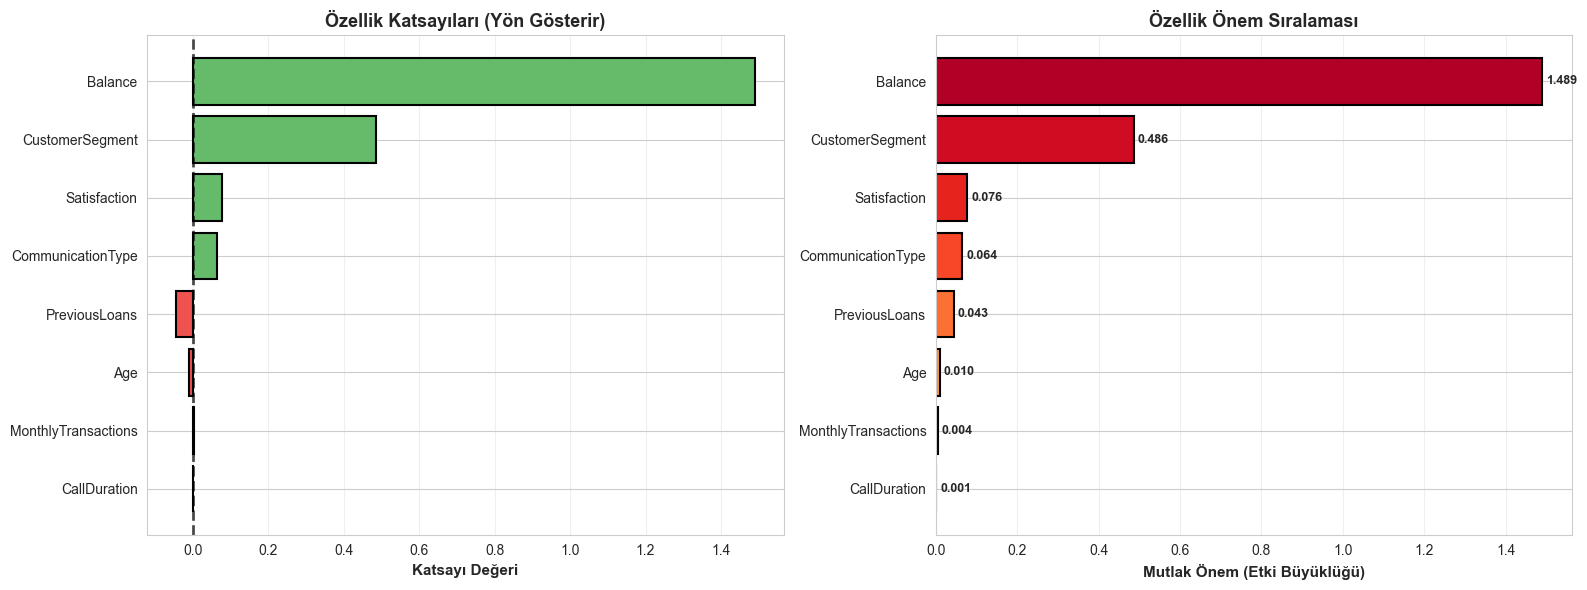


💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
🔴 Kırmızı barlar (Negatif): Bu özellik arttıkça kaydolma olasılığı AZALIR
🟢 Yeşil barlar (Pozitif): Bu özellik arttıkça kaydolma olasılığı ARTAR

📊 En Etkili 3 Özellik:
   1. Balance → Kaydolma olasılığını artırır
   2. CustomerSegment → Kaydolma olasılığını artırır
   3. Satisfaction → Kaydolma olasılığını artırır
────────────────────────────────────────────────────────────────────────────────


In [24]:
# Özellik Önemleri Görselleştirmesi

feature_importance = pd.DataFrame({
    'Özellik': X_train.columns,
    'Katsayı': model.coef_[0],
    'Mutlak Önem': np.abs(model.coef_[0])
}).sort_values('Mutlak Önem', ascending=True)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Katsayılar (pozitif/negatif gösterilir)
colors = ['#EF5350' if x < 0 else '#66BB6A' for x in feature_importance['Katsayı']]
axes[0].barh(feature_importance['Özellik'], feature_importance['Katsayı'], 
             color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Katsayı Değeri', fontweight='bold', fontsize=11)
axes[0].set_title('Özellik Katsayıları (Yön Gösterir)', fontweight='bold', fontsize=13)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
axes[0].grid(axis='x', alpha=0.3)

# Sağ grafik: Mutlak önem (sadece etki büyüklüğü)
colors_abs = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feature_importance)))
bars = axes[1].barh(feature_importance['Özellik'], feature_importance['Mutlak Önem'], 
                    color=colors_abs, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Mutlak Önem (Etki Büyüklüğü)', fontweight='bold', fontsize=11)
axes[1].set_title('Özellik Önem Sıralaması', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)

# Değerleri bar üzerine yazma
for i, (bar, val) in enumerate(zip(bars, feature_importance['Mutlak Önem'])):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 YORUM:")
print("─" * 80)
print("🔴 Kırmızı barlar (Negatif): Bu özellik arttıkça kaydolma olasılığı AZALIR")
print("🟢 Yeşil barlar (Pozitif): Bu özellik arttıkça kaydolma olasılığı ARTAR")
print()
print("📊 En Etkili 3 Özellik:")
top_3 = feature_importance.nlargest(3, 'Mutlak Önem')
for i, row in enumerate(top_3.itertuples(), 1):
    etki = "artırır" if row.Katsayı > 0 else "azaltır"
    print(f"   {i}. {row.Özellik} → Kaydolma olasılığını {etki}")
print("─" * 80)

**🏁 Section 5 Tamamlandı**

Bu adımda:
- ✅ İlk Lojistik Regresyon modelimizi oluşturduk ve eğittik
- ✅ `predict()` ve `predict_proba()` metodlarını karşılaştırdık
- ✅ 0.5 eşik değeriyle 0/1 dönüşümünü anladık
- ✅ Modelin tren ve test doğruluğunu ölçtük (%70+ hedefini kontrol ettik)
- ✅ Hangi özelliklerin kaydolma kararını en çok etkilediğini gördük

**🎯 YBS Perspektifi - Karar Destek:**  
Artık modelimiz hem **sonuç veriyor** (kim kaydolacak?), hem **açıklama yapıyor** (neden bu sonuç?). Balance ve Satisfaction gibi özelliklerin ağırlıkları, müşteri segmentasyonu ve kampanya tasarımı için somut girdiler sunuyor.

# 🎯 **Section 6: Performans Metriklerini Derinlemesine İnceleme**

**Hedef:** Accuracy'nin ötesine geçip modelin hangi durumlarda başarılı/başarısız olduğunu anlamak.

**YBS Bağlamı:**  
Bir bankacılık kampanyasında sadece "doğruluk yüzdesi" yeterli değildir. **Kim kaydolacak diye tahmin ettik ama kaydolmadı?** veya **Kaydolmayacak dedik ama kaydoldu mu?** gibi sorulara yanıt vermemiz gerekir. Çünkü:

- Yanlış pozitif (False Positive): Gereksiz promosyon SMS'i → Maliyet
- Yanlış negatif (False Negative): Potansiyel müşteriyi kaçırma → Fırsat kaybı

Bu bölümde **Confusion Matrix** ve türevlerini (Precision, Recall, F1-Score) YBS perspektifinden inceleyeceğiz.

## **Confusion Matrix (Karmaşıklık Matrisi)**

**Accuracy tek sayı verir:**  
*"Model %75 doğru tahmin yaptı."*

**Confusion Matrix daha detaylı bilgi verir:**  
*"100 müşteriden 60'ını doğru kaydolur diye tahmin ettik, 15'ini kaçırdık, 5'ini yanlış yere koyduk..."*

### **Confusion Matrix Yapısı**

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph TD
    A["<b>🎯 Confusion Matrix</b><br/>Gerçek vs Tahmin"] --> B["<b>📊 2x2 Tablo</b>"]
    
    B --> C["<b>✅ True Positive TP</b><br/>Gerçek=1, Tahmin=1<br/><i>Kaydolacak dedik, kaydoldu</i>"]
    B --> D["<b>❌ False Positive FP</b><br/>Gerçek=0, Tahmin=1<br/><i>Kaydolacak dedik, ama kaydolmadı</i><br/>🏦 <b>Tip 1 Hata</b>"]
    B --> E["<b>❌ False Negative FN</b><br/>Gerçek=1, Tahmin=0<br/><i>Kaydolmayacak dedik, ama kaydoldu</i><br/>🏦 <b>Tip 2 Hata</b>"]
    B --> F["<b>✅ True Negative TN</b><br/>Gerçek=0, Tahmin=0<br/><i>Kaydolmayacak dedik, kaydolmadı</i>"]
    
    style A fill:#FFDAB9,stroke:#8B4513,stroke-width:3px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C fill:#D4EDDA,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style D fill:#F8D7DA,stroke:#DC3545,stroke-width:2px,color:#2C3E50
    style E fill:#FFF3CD,stroke:#FFC107,stroke-width:2px,color:#2C3E50
    style F fill:#D1ECF1,stroke:#17A2B8,stroke-width:2px,color:#2C3E50
```

**YBS Perspektifi:**
- **TP (Doğru Pozitif):** Başarılı kampanya hedeflemesi → Gelir
- **TN (Doğru Negatif):** Boşa SMS göndermekten kaçındık → Maliyet tasarrufu
- **FP (Yanlış Pozitif):** Gereksiz SMS/Arama → Para kaybı + müşteri rahatsızlığı
- **FN (Yanlış Negatif):** Potansiyel müşteriyi kaçırdık → Fırsat maliyeti

## **Confusion Matrix Görselleştirmesi**

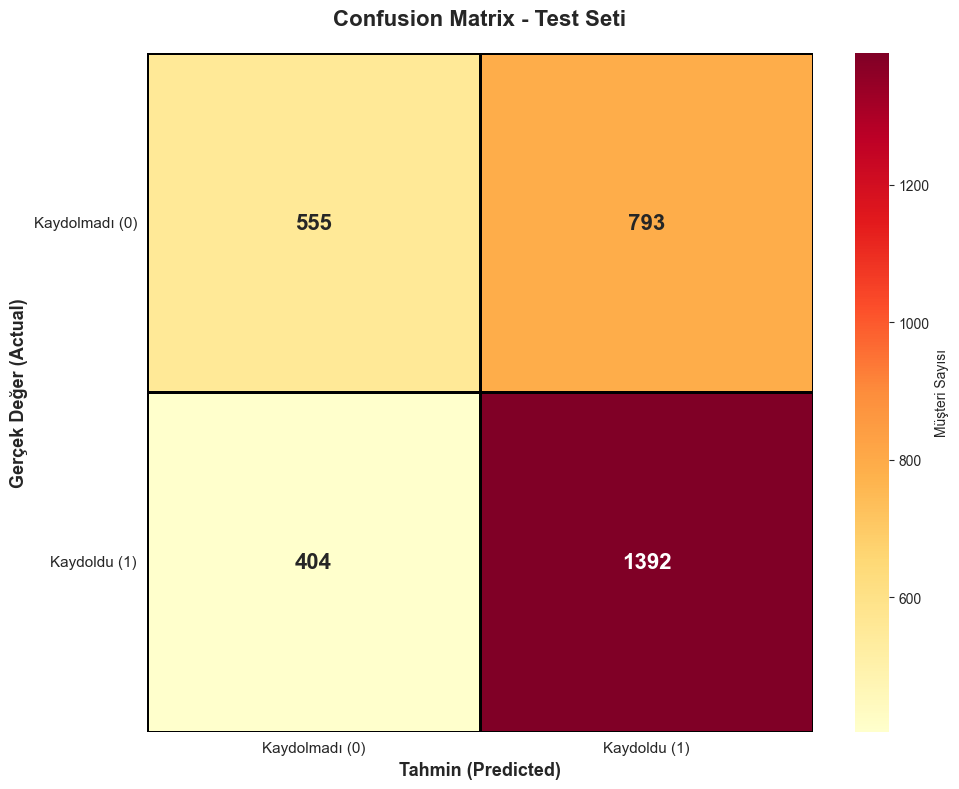


🔍 CONFUSION MATRIX BİLEŞENLERİ (Test Seti - 3,143 müşteri)
✅ True Positive  (TP): 1392 → Kaydolacak dedik, gerçekten kaydoldu
✅ True Negative  (TN):  555 → Kaydolmayacak dedik, kaydolmadı
❌ False Positive (FP):  793 → Kaydolacak dedik, ama kaydolmadı (Tip 1 Hata)
❌ False Negative (FN):  404 → Kaydolmayacak dedik, ama kaydoldu (Tip 2 Hata)

📊 Accuracy (TP+TN/Total): 0.6193 (61.93%)
   Test Seti Accuracy ile eşleşiyor mu? → True


In [25]:
from sklearn.metrics import confusion_matrix

# Test seti için Confusion Matrix hesaplama
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix'i seaborn heatmap ile görselleştirme
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=2, linecolor='black', 
            cbar_kws={'label': 'Müşteri Sayısı'},
            annot_kws={'size': 16, 'weight': 'bold'})

plt.title('Confusion Matrix - Test Seti', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Gerçek Değer (Actual)', fontsize=13, fontweight='bold')
plt.xlabel('Tahmin (Predicted)', fontsize=13, fontweight='bold')

# Eksen etiketlerini daha anlamlı hale getirme
plt.yticks([0.5, 1.5], ['Kaydolmadı (0)', 'Kaydoldu (1)'], rotation=0, fontsize=11)
plt.xticks([0.5, 1.5], ['Kaydolmadı (0)', 'Kaydoldu (1)'], fontsize=11)

plt.tight_layout()
plt.show()

# Confusion Matrix bileşenlerini ayrıştırma
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*70)
print("🔍 CONFUSION MATRIX BİLEŞENLERİ (Test Seti - 3,143 müşteri)")
print("="*70)
print(f"✅ True Positive  (TP): {tp:>4} → Kaydolacak dedik, gerçekten kaydoldu")
print(f"✅ True Negative  (TN): {tn:>4} → Kaydolmayacak dedik, kaydolmadı")
print(f"❌ False Positive (FP): {fp:>4} → Kaydolacak dedik, ama kaydolmadı (Tip 1 Hata)")
print(f"❌ False Negative (FN): {fn:>4} → Kaydolmayacak dedik, ama kaydoldu (Tip 2 Hata)")
print("="*70)

# Doğruluk hesaplaması (Confusion Matrix'ten)
accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
print(f"\n📊 Accuracy (TP+TN/Total): {accuracy_from_cm:.4f} ({accuracy_from_cm*100:.2f}%)")
print(f"   Test Seti Accuracy ile eşleşiyor mu? → {np.isclose(accuracy_from_cm, test_accuracy)}")
print("="*70)

## **Precision, Recall, F1-Score: YBS Perspektifinden Anlam**

Confusion Matrix'ten türetilen 3 kritik metrik:

### 1️⃣ Precision (Kesinlik/Hassasiyet)
**Soru:** *"Kaydolacak dediğimiz müşterilerin kaçı gerçekten kaydoldu?"*

$$
\text{Precision} = \frac{TP}{TP + FP} = \frac{\text{Doğru Pozitif}}{\text{Tüm Pozitif Tahminler}}
$$

**YBS Bağlamı:**  
Yüksek Precision → Az yanlış alarm → Gereksiz SMS/Arama maliyeti düşer.  
**Örnek:** Precision = 0.85 → Kaydolacak dediğimiz 100 kişiden 85'i gerçekten kaydoldu, 15'i yanlış alarmıştı.

### 2️⃣ Recall (Duyarlılık/Hassasiyet)
**Soru:** *"Gerçekten kaydolan müşterilerin kaçını yakaladık?"*

$$
\text{Recall} = \frac{TP}{TP + FN} = \frac{\text{Doğru Pozitif}}{\text{Gerçek Pozitifler}}
$$

**YBS Bağlamı:**  
Yüksek Recall → Az kaçırma → Potansiyel müşteri kaybı az.  
**Örnek:** Recall = 0.75 → Gerçekten kaydolan 100 müşteriden 75'ini yakaladık, 25'ini kaçırdık.

### 3️⃣ F1-Score (Precision ve Recall'un Dengesi)
**Soru:** *"Hem yanlış alarm az, hem de kaçırma az olsun. İkisinin dengesi nerede?"*

$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**YBS Bağlamı:**  
F1-Score, Precision ve Recall arasında **harmonik ortalama** alır. İkisinden biri düşükse F1 de düşer.

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph LR
    A["<b>🎯 İş Hedefi</b>"] --> B{"<b>Hangi Metrik?</b>"}
    
    B -->|"Yanlış alarm<br/>maliyeti yüksek"| C["<b>📍 Precision↑</b><br/>Spam filtresi<br/>Tıbbi teşhis"]
    B -->|"Kaçırma maliyeti<br/>çok yüksek"| D["<b>🔍 Recall↑</b><br/>Kanser taraması<br/>Dolandırıcılık tespiti"]
    B -->|"İkisinin dengesi<br/>önemli"| E["<b>⚖️ F1-Score↑</b><br/>Müşteri kaydolma<br/>Kredi risk skoru"]
    
    style A fill:#FFDAB9,stroke:#8B4513,stroke-width:3px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C fill:#FFE4E1,stroke:#DC3545,stroke-width:2px,color:#2C3E50
    style D fill:#E8F5E9,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style E fill:#FFF9C4,stroke:#FFC107,stroke-width:2px,color:#2C3E50
```

**Bankacılık Kampanyası İçin Öncelik:**
- **FP (Yanlış Pozitif) maliyeti:** SMS ücreti (düşük) + müşteri rahatsızlığı (orta)
- **FN (Yanlış Negatif) maliyeti:** Potansiyel gelir kaybı (yüksek)

➡️ Bu durumda **Recall'a biraz daha ağırlık vermek** mantıklı olabilir (müşteri kaçırmamak için).

## **Precision, Recall, F1-Score Hesaplama ve Görselleştirme**

📊 PERFORMANS METRİKLERİ (Test Seti)
✨ Precision (Kesinlik):  0.6371 (63.71%)
   ➜ Kaydolacak dediğimiz müşterilerin 63.7%'si gerçekten kaydoldu

🎯 Recall (Duyarlılık):    0.7751 (77.51%)
   ➜ Gerçekten kaydolan müşterilerin 77.5%'sini yakaladık

⚖️  F1-Score (Denge):      0.6993 (69.93%)
   ➜ Precision ve Recall'un harmonik ortalaması

🔢 Accuracy (Genel):      0.6193 (61.93%)

🔍 Doğrulama:
   Manuel Precision = 0.637071
   Sklearn Precision = 0.637071 → Eşleşiyor? True


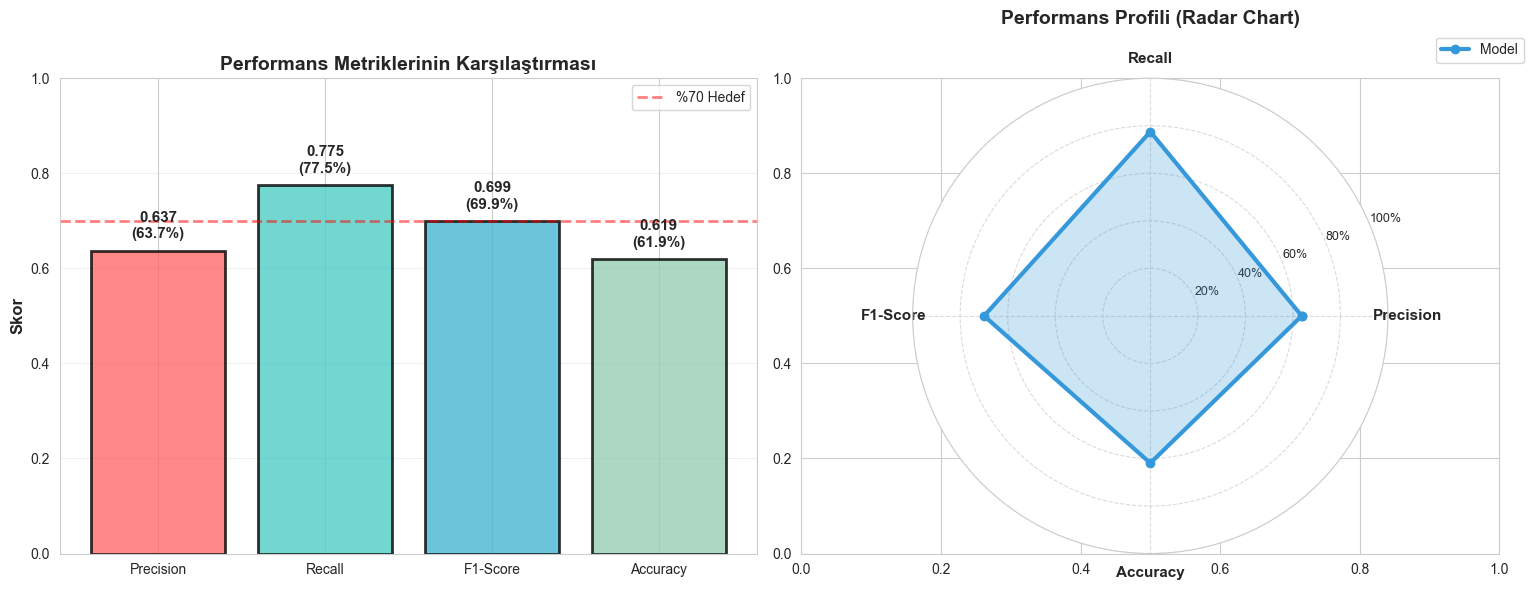

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Manuel hesaplama (TP, TN, FP, FN'yi yukarıda aldık)
precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

# Sklearn fonksiyonları ile hesaplama (doğrulama için)
precision_sklearn = precision_score(y_test, y_pred)
recall_sklearn = recall_score(y_test, y_pred)
f1_sklearn = f1_score(y_test, y_pred)

print("="*80)
print("📊 PERFORMANS METRİKLERİ (Test Seti)")
print("="*80)
print(f"✨ Precision (Kesinlik):  {precision_sklearn:.4f} ({precision_sklearn*100:.2f}%)")
print(f"   ➜ Kaydolacak dediğimiz müşterilerin {precision_sklearn*100:.1f}%'si gerçekten kaydoldu")
print()
print(f"🎯 Recall (Duyarlılık):    {recall_sklearn:.4f} ({recall_sklearn*100:.2f}%)")
print(f"   ➜ Gerçekten kaydolan müşterilerin {recall_sklearn*100:.1f}%'sini yakaladık")
print()
print(f"⚖️  F1-Score (Denge):      {f1_sklearn:.4f} ({f1_sklearn*100:.2f}%)")
print(f"   ➜ Precision ve Recall'un harmonik ortalaması")
print()
print(f"🔢 Accuracy (Genel):      {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*80)

# Manuel ve Sklearn hesaplamalarının eşleştiğini doğrulama
print("\n🔍 Doğrulama:")
print(f"   Manuel Precision = {precision_manual:.6f}")
print(f"   Sklearn Precision = {precision_sklearn:.6f} → Eşleşiyor? {np.isclose(precision_manual, precision_sklearn)}")
print("="*80)

# Görselleştirme: Metrik Karşılaştırması
metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
values = [precision_sklearn, recall_sklearn, f1_sklearn, test_accuracy]
colors_metrics = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Bar chart
bars = ax1.bar(metrics, values, color=colors_metrics, edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_ylabel('Skor', fontweight='bold', fontsize=12)
ax1.set_title('Performans Metriklerinin Karşılaştırması', fontweight='bold', fontsize=14)
ax1.set_ylim([0, 1.0])
ax1.axhline(y=0.7, color='red', linestyle='--', linewidth=2, alpha=0.5, label='%70 Hedef')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}\n({val*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Sağ: Radar chart (örümcek ağı)
from math import pi

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
values_plot = values + values[:1]  # İlk değeri sona ekle (kapalı çizgi için)
angles += angles[:1]

ax2 = plt.subplot(122, projection='polar')
ax2.plot(angles, values_plot, 'o-', linewidth=3, color='#3498db', label='Model')
ax2.fill(angles, values_plot, alpha=0.25, color='#3498db')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=9)
ax2.set_title('Performans Profili (Radar Chart)', fontweight='bold', fontsize=14, pad=20)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## **Classification Report: Kapsamlı Performans Özeti**

In [27]:
from sklearn.metrics import classification_report

# Classification Report - tüm metrikleri tek seferde
print("="*80)
print("📋 CLASSIFICATION REPORT (Test Seti)")
print("="*80)
print(classification_report(y_test, y_pred, 
                          target_names=['Kaydolmadı (0)', 'Kaydoldu (1)'],
                          digits=4))

print("\n💡 RAPOR AÇIKLAMASI:")
print("─" * 80)
print("• precision: Her sınıf için kesinlik (o sınıf dediğimizde doğru oranı)")
print("• recall:    Her sınıf için duyarlılık (o sınıftan kaçını yakaladık)")
print("• f1-score:  Precision ve recall'un harmonik ortalaması")
print("• support:   Test setindeki gerçek örnek sayısı (her sınıf için)")
print()
print("• macro avg:     Her sınıfın ortalaması (eşit ağırlık)")
print("• weighted avg:  Sınıf sayısına göre ağırlıklı ortalama (dengesiz veri için)")
print("─" * 80)

print("\n🏦 YBS PERSPEKTİFİ:")
print("─" * 80)
print("🔴 Sınıf 0 (Kaydolmadı) Performance:")
print(f"   → Precision: Kaydolmayacak dediğimizde ne kadar eminiz?")
print(f"   → Recall:    Kaydolmayanların kaçını doğru tespit ettik?")
print()
print("🟢 Sınıf 1 (Kaydoldu) Performance:")
print(f"   → Precision: Kaydolacak dediğimizde ne kadar eminiz? (SMS maliyeti)")
print(f"   → Recall:    Kaydolanların kaçını yakaladık? (Fırsat kaybı)")
print("─" * 80)

📋 CLASSIFICATION REPORT (Test Seti)
                precision    recall  f1-score   support

Kaydolmadı (0)     0.5787    0.4117    0.4811      1348
  Kaydoldu (1)     0.6371    0.7751    0.6993      1796

      accuracy                         0.6193      3144
     macro avg     0.6079    0.5934    0.5902      3144
  weighted avg     0.6121    0.6193    0.6058      3144


💡 RAPOR AÇIKLAMASI:
────────────────────────────────────────────────────────────────────────────────
• precision: Her sınıf için kesinlik (o sınıf dediğimizde doğru oranı)
• recall:    Her sınıf için duyarlılık (o sınıftan kaçını yakaladık)
• f1-score:  Precision ve recall'un harmonik ortalaması
• support:   Test setindeki gerçek örnek sayısı (her sınıf için)

• macro avg:     Her sınıfın ortalaması (eşit ağırlık)
• weighted avg:  Sınıf sayısına göre ağırlıklı ortalama (dengesiz veri için)
────────────────────────────────────────────────────────────────────────────────

🏦 YBS PERSPEKTİFİ:
────────────────────────────

## **YBS Perspektifi: Maliyet-Fayda Analizi**

Performans metriklerini iş hedefleriyle nasıl ilişkilendiririz?

### **Senaryo: Bankacılık Kampanyası**

**Maliyet Hesabı:**
- 📱 SMS/Arama maliyeti: ~0.50 TL/müşteri
- 🎁 Promosyon maliyeti: ~20 TL/müşteri (hediye, indirim vs.)
- 💰 Beklenen gelir (başarılı kaydolma): ~200 TL/müşteri

**Hata Maliyetleri:**

| Hata Türü | İş Etkisi | Maliyet |
|-----------|-----------|---------|
| **False Positive (FP)** | Kaydolmayacak müşteriye kampanya | ~20.50 TL (promosyon + SMS) |
| **False Negative (FN)** | Potansiyel müşteriyi kaçırma | ~200 TL (gelir kaybı) |
| **True Positive (TP)** | Başarılı hedefleme | +179.50 TL (200 - 20.50) |
| **True Negative (TN)** | Boşa harcama yapılmadı | 0 TL (maliyet yok) |

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph TD
    A["<b>🎯 İş Hedefi</b><br/>Kampanya Optimizasyonu"] --> B{"<b>Hangi Maliyet<br/>Daha Kritik?</b>"}
    
    B -->|"FP maliyeti >> FN"| C["<b>📍 Precision Odaklı</b><br/>Emin olduğumuz müşterilere ulaş<br/><i>Örnek: Lüks ürün kampanyası</i>"]
    B -->|"FN maliyeti >> FP"| D["<b>🔍 Recall Odaklı</b><br/>Kimseyi kaçırma<br/><i>Örnek: Yeni ürün lansmanı</i>"]
    B -->|"Maliyetler dengeli"| E["<b>⚖️ F1-Score Odaklı</b><br/>İkisinin dengesi<br/><i>Örnek: Standart kampanya</i>"]
    
    C --> F["<b>Threshold ↑ 0.7</b><br/>Daha seçici ol"]
    D --> G["<b>Threshold ↓ 0.3</b><br/>Daha kapsayıcı ol"]
    E --> H["<b>Threshold = 0.5</b><br/>Dengeli yaklaşım"]
    
    style A fill:#FFDAB9,stroke:#8B4513,stroke-width:3px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C fill:#FFE4E1,stroke:#DC3545,stroke-width:2px,color:#2C3E50
    style D fill:#E8F5E9,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style E fill:#FFF9C4,stroke:#FFC107,stroke-width:2px,color:#2C3E50
    style F fill:#FFD6D6,stroke:#DC3545,stroke-width:1px,color:#2C3E50
    style G fill:#D6FFD6,stroke:#28A745,stroke-width:1px,color:#2C3E50
    style H fill:#FFFFCC,stroke:#FFC107,stroke-width:1px,color:#2C3E50
```

**Karar Çerçevesi (YBS Yöneticisi Perspektifi):**

1. **Precision Önemli ise:**
   - Problem: FP maliyeti yüksek (örn: Pahalı hediyeler, sınırlı stok)
   - Strateji: Sadece yüksek olasılıklı müşterilere odaklan
   - Threshold: 0.6-0.7 (daha seçici)

2. **Recall Önemli ise:**
   - Problem: FN maliyeti yüksek (örn: Potansiyel gelir kaybı çok büyük)
   - Strateji: Mümkün olduğunca çok müşteriyi yakala
   - Threshold: 0.3-0.4 (daha kapsayıcı)

3. **F1-Score Önemli ise:**
   - Problem: Her iki hata türü de önemli
   - Strateji: Dengeli yaklaşım
   - Threshold: 0.5 (varsayılan)

**📌 Sonuç:** Accuracy tek başına yeterli değil. **İş bağlamını** (cost-benefit) dikkate alarak doğru metriği optimize etmeliyiz.

**🏁 Section 6 Tamamlandı**

Bu adımda:
- ✅ Confusion Matrix'i görselleştirdik ve TP, TN, FP, FN kavramlarını öğrendik
- ✅ Precision, Recall, F1-Score metriklerini hesapladık ve yorumladık
- ✅ Classification Report ile kapsamlı performans analizi yaptık
- ✅ YBS perspektifinden maliyet-fayda analizi ile hangi metriğin ne zaman önemli olduğunu anladık
- ✅ İş hedefine göre threshold stratejisi belirlemeyi öğrendik

**🎯 YBS Perspektifi - Karar Çerçevesi:**  
Artık sadece "model doğru tahmin yapıyor mu?" değil, "hangi hataları yapıyor ve bu hatalar işletmeye ne kadara mal oluyor?" sorularını yanıtlayabiliyoruz. **Accuracy tek sayı, ama Confusion Matrix tüm hikayeyi anlatıyor**.

# 🔧 **Section 7: Hiperparametre Kavramları ve Model İyileştirme**

**Hedef:** Model parametreleri vs hiperparametreler arasındaki farkı anlamak ve LogisticRegression'ın temel hiperparametrelerini öğrenmek.

**YBS Bağlamı:**  
Bir model "kendi kendine öğrendiği değerler" (parametreler) ve "biz ona verdiğimiz ayarlar" (hiperparametreler) ile çalışır. YBS perspektifinden:
- **Parametreler:** Model veriyi görünce otomatik öğrenir (örn: katsayılar, ağırlıklar)
- **Hiperparametreler:** Modelin nasıl öğreneceğini BİZ belirleriz (örn: düzenleme gücü, optimizasyon yöntemi)

Bu bölümde **sklearn dokümantasyonunu okumayı** öğrenerek, hangi hiperparametrenin ne işe yaradığını keşfedeceğiz.

## **Parametre vs Hiperparametre**

### 🔍 **Model Parametreleri (Parameters)**
**Tanım:** Model'in eğitim sırasında veriden **otomatik olarak öğrendiği** değerlerdir.

**Örnekler:**
- Lojistik Regresyon'da: `model.coef_` (katsayılar) ve `model.intercept_` (kesim noktası)
- Derin Öğrenme'de: Ağırlıklar (weights) ve bias'lar

**Özellik:**
- ✅ Biz bu değerleri elle ayarlamayız
- ✅ `model.fit()` çağrılınca, model veriyi görüp bu değerleri optimize eder
- ✅ Eğitim tamamlandıktan sonra `model.coef_` gibi özelliklerle erişebiliriz

### 🔧 **Hiperparametreler (Hyperparameters)**
**Tanım:** Model'in nasıl öğreneceğini belirleyen, **eğitim başlamadan önce BİZİM ayarladığımız** değerlerdir.

**Örnekler:**
- Lojistik Regresyon'da: `penalty`, `C`, `solver`, `max_iter`, `class_weight`
- Karar Ağaçları'nda: `max_depth`, `min_samples_split`
- Neural Networks'te: `learning_rate`, `batch_size`, `epochs`

**Özellik:**
- ✅ Biz bu değerleri `LogisticRegression(C=1.0, penalty='l2', ...)` şeklinde manuel ayarlarız
- ✅ Model bu değerleri eğitim sırasında değiştirmez
- ✅ Doğru hiperparametre seçimi model performansını doğrudan etkiler


```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph LR
    A["<b>🎮 Hiperparametreler</b><br/><i>Biz ayarlarız</i><br/>C=1.0, penalty='l2'"] --> B["<b>📚 Eğitim</b><br/>model.fit X,y"]
    
    B --> C["<b>🧠 Model Parametreleri</b><br/><i>Model öğrenir</i><br/>coef_, intercept_"]
    
    C --> D["<b>🎯 Tahmin</b><br/>model.predict X_test"]
    
    style A fill:#FFE4E1,stroke:#DC3545,stroke-width:3px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C fill:#D4EDDA,stroke:#28A745,stroke-width:3px,color:#2C3E50
    style D fill:#FFF9C4,stroke:#FFC107,stroke-width:2px,color:#2C3E50
```

**YBS Analojisi:**
- **Hiperparametre:** Bir satış ekibine verdiğiniz **iş politikası** (örn: "Müşteriyle en fazla 3 kez görüş", "İlk görüşmede maksimum 10 dakika konuş")
- **Parametre:** Satış elemanının **deneyimle öğrendiği taktikler** (örn: "Bu tür müşteriye şu cümleyi kur", "İtiraz gelince şöyle yanıt ver")

Hiperparametreleri **biz** belirleriz, parametreleri **model** öğrenir.

## **LogisticRegression Hiperparametreleri**

`sklearn.linear_model.LogisticRegression` sınıfının en önemli hiperparametreleri:

### 1️⃣ `penalty` (Düzenleme Tipi)
**Ne işe yarar?** Overfitting'i (aşırı öğrenme) önlemek için model katsayılarına ceza uygular.

**Seçenekler:**
- `'l1'`: Lasso (bazı katsayıları tam sıfıra indirir → Özellik seçimi yapar)
- `'l2'`: Ridge (tüm katsayıları küçültür, ama sıfır yapmaz → **Varsayılan**)
- `'elasticnet'`: L1 ve L2'nin karışımı
- `None`: Düzenleme yok (küçük veri setlerinde riskli)

**YBS Perspektifi:**
- L2 → "Tüm özellikleri kullan, ama aşırıya kaçma"
- L1 → "Gereksiz özellikleri kes, sadece önemlileri tut"

### 2️⃣ `C` (Regularization Strength - Düzenleme Gücü)
**Ne işe yarar?** `penalty` parametresinin ne kadar sert uygulanacağını kontrol eder.

**Değer Aralığı:** 0'dan büyük herhangi bir sayı (varsayılan: `C=1.0`)

**Mantık:**
- **Küçük C (örn: 0.01):** Güçlü düzenleme → Model basit → Underfitting riski
- **Büyük C (örn: 100):** Zayıf düzenleme → Model karmaşık → Overfitting riski

$$
\text{Loss} = \text{Hata} + \frac{1}{C} \times \text{Ceza (penalty)}
$$

**C ↑ → Ceza azalır → Model daha serbest (karmaşık)**  
**C ↓ → Ceza artar → Model daha kısıtlı (basit)**

**YBS Analojisi:**
- Düşük C: "Müşteriye çok fazla özellik sunma, basit tut"
- Yüksek C: "Tüm özellikleri kullan, detaylı analiz yap"

### 3️⃣ `solver` (Optimizasyon Algoritması)
**Ne işe yarar?** Model katsayılarını bulurken kullanılan matematiksel yöntem.

**Seçenekler:**
- `'lbfgs'`: Hızlı, küçük-orta veri setleri için ideal → **Varsayılan**
- `'liblinear'`: Küçük veri setleri için, L1 penalty destekler
- `'saga'`: Büyük veri setleri için, tüm penalty tiplerini destekler
- `'sag'`: Saga'ya benzer ama biraz daha hızlı (L1 desteklemez)
- `'newton-cg'`: L2 penalty için alternatif

**Uyumluluk:**
- L1 penalty → `liblinear`, `saga`
- L2 penalty → Hepsi
- ElasticNet → `saga`

**YBS Perspektifi:**  
Genelde `lbfgs` (varsayılan) yeterlidir. Büyük veri setinde `saga` tercih edilir.

### 4️⃣ `max_iter` (Maksimum İterasyon)
**Ne işe yarar?** Optimizer'ın en fazla kaç adımda sonuca ulaşmaya çalışacağını belirler.

**Varsayılan:** `max_iter=100`

**Problem:** Karmaşık veri setlerinde 100 iterasyon yetmeyebilir → ConvergenceWarning
**Çözüm:** `max_iter=500` veya `max_iter=1000` artır

### 5️⃣ `class_weight` (Sınıf Ağırlıkları)
**Ne işe yarar?** Dengesiz veri setlerinde azınlık sınıfına daha fazla önem verir.

**Seçenekler:**
- `None`: Varsayılan (tüm sınıflar eşit)
- `'balanced'`: Sınıf sayısına göre otomatik ağırlık hesaplar
- `{0: 1, 1: 5}`: Manuel ağırlık (sınıf 1'e 5 kat daha fazla önem)

**YBS Bağlamı:**  
Fraud detection (dolandırıcılık tespiti) gibi senaryolarda azınlık sınıfı çok önemlidir. `class_weight='balanced'` kullanarak performansı artırabiliriz.

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph TD
    A["<b>🔧 Hiperparametre Seçimi</b>"] --> B{"<b>Ne Sorunu<br/>Çözüyoruz?</b>"}
    
    B -->|"Overfitting var"| C["<b>C ↓ azalt</b><br/>penalty='l2'<br/><i>Model basitleştir</i>"]
    B -->|"Underfitting var"| D["<b>C ↑ artır</b><br/>penalty=None<br/><i>Model karmaşıklaştır</i>"]
    B -->|"Özellik seçimi<br/>gerekli"| E["<b>penalty='l1'</b><br/>solver='saga'<br/><i>Gereksiz özellikleri sıfırla</i>"]
    B -->|"Dengesiz veri"| F["<b>class_weight='balanced'</b><br/><i>Azınlık sınıfını güçlendir</i>"]
    
    style A fill:#FFDAB9,stroke:#8B4513,stroke-width:3px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C fill:#FFE4E1,stroke:#DC3545,stroke-width:2px,color:#2C3E50
    style D fill:#E8F5E9,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style E fill:#FFF9C4,stroke:#FFC107,stroke-width:2px,color:#2C3E50
    style F fill:#E1D5E7,stroke:#9673A6,stroke-width:2px,color:#2C3E50
```

## **Mevcut Modelimizin Hiperparametrelerini İnceleme**

In [28]:
# Mevcut modelimizin tüm hiperparametrelerini görelim
print("="*80)
print("🔧 MEVCUT MODEL HİPERPARAMETRELERİ")
print("="*80)
print(f"penalty:        {model.penalty}")
print(f"C:              {model.C}")
print(f"solver:         {model.solver}")
print(f"max_iter:       {model.max_iter}")
print(f"class_weight:   {model.class_weight}")
print(f"random_state:   {model.random_state}")
print(f"fit_intercept:  {model.fit_intercept}")
print(f"multi_class:    {model.multi_class}")
print("="*80)

print("\n💡 YORUM:")
print("─" * 80)
print("• penalty='l2' → Ridge regularization (tüm katsayıları küçültür)")
print("• C=1.0 → Orta düzenleme gücü (ne çok serbest, ne çok kısıtlı)")
print("• solver='lbfgs' → Küçük-orta veri setleri için ideal optimizer")
print("• max_iter=100 → 100 adımda sonuca ulaşmaya çalışır (genelde yeterli)")
print("• class_weight=None → Sınıflar eşit ağırlıkta (dengeli veri için uygun)")
print("─" * 80)

# Model'in tüm parametrelerini görmek için get_params()
print("\n📋 TÜM HİPERPARAMETRELER (get_params() ile):")
print("─" * 80)
for key, value in model.get_params().items():
    print(f"  {key:20} → {value}")
print("─" * 80)

🔧 MEVCUT MODEL HİPERPARAMETRELERİ
penalty:        l2
C:              1.0
solver:         lbfgs
max_iter:       100
class_weight:   None
random_state:   42
fit_intercept:  True
multi_class:    deprecated

💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
• penalty='l2' → Ridge regularization (tüm katsayıları küçültür)
• C=1.0 → Orta düzenleme gücü (ne çok serbest, ne çok kısıtlı)
• solver='lbfgs' → Küçük-orta veri setleri için ideal optimizer
• max_iter=100 → 100 adımda sonuca ulaşmaya çalışır (genelde yeterli)
• class_weight=None → Sınıflar eşit ağırlıkta (dengeli veri için uygun)
────────────────────────────────────────────────────────────────────────────────

📋 TÜM HİPERPARAMETRELER (get_params() ile):
────────────────────────────────────────────────────────────────────────────────
  C                    → 1.0
  class_weight         → None
  dual                 → False
  fit_intercept        → True
  intercept_scaling    → 1
  l1_ratio        

## **Hiperparametre Denemeleri: C Parametresi**

`C` parametresi modelin karmaşıklığını kontrol eder. Farklı C değerleriyle modeller eğitip performanslarını karşılaştıralım.

In [29]:
# Farklı C değerleriyle denemeler
C_values = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000]
results = []

print("="*80)
print("🔬 FARKLI C DEĞERLERİYLE MODEL EĞİTİMİ")
print("="*80)

for c_val in C_values:
    # Model oluştur (sadece C değeri değişiyor)
    model_temp = LogisticRegression(C=c_val, random_state=RANDOM_STATE, max_iter=1000)
    
    # Eğit
    model_temp.fit(X_train, y_train)
    
    # Performans ölç
    train_acc = model_temp.score(X_train, y_train)
    test_acc = model_temp.score(X_test, y_test)
    
    # Sonuçları kaydet
    results.append({
        'C': c_val,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Overfit_Difference': train_acc - test_acc
    })
    
    print(f"C={c_val:7.3f} → Train: {train_acc:.4f}, Test: {test_acc:.4f}, Fark: {train_acc - test_acc:+.4f}")

print("="*80)

# DataFrame'e çevir
results_df = pd.DataFrame(results)

print("\n💡 YORUM:")
print("─" * 80)
print("• Küçük C (0.001-0.01): Güçlü düzenleme → Model basit → Underfitting olabilir")
print("• Orta C (0.1-10): Dengeli → İyi genelleme")
print("• Büyük C (100-1000): Zayıf düzenleme → Model karmaşık → Overfitting riski")
print()
print("🎯 En iyi C değeri: Test accuracy'si en yüksek olan!")
best_c = results_df.loc[results_df['Test_Accuracy'].idxmax()]['C']
print(f"   → C = {best_c} (Test Acc: {results_df['Test_Accuracy'].max():.4f})")
print("─" * 80)

🔬 FARKLI C DEĞERLERİYLE MODEL EĞİTİMİ
C=  0.001 → Train: 0.6126, Test: 0.6148, Fark: -0.0022
C=  0.010 → Train: 0.6255, Test: 0.6291, Fark: -0.0036
C=  0.100 → Train: 0.6302, Test: 0.6291, Fark: +0.0010
C=  1.000 → Train: 0.6300, Test: 0.6295, Fark: +0.0005
C= 10.000 → Train: 0.6301, Test: 0.6291, Fark: +0.0009
C=100.000 → Train: 0.6301, Test: 0.6291, Fark: +0.0009
C=1000.000 → Train: 0.6301, Test: 0.6291, Fark: +0.0009

💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
• Küçük C (0.001-0.01): Güçlü düzenleme → Model basit → Underfitting olabilir
• Orta C (0.1-10): Dengeli → İyi genelleme
• Büyük C (100-1000): Zayıf düzenleme → Model karmaşık → Overfitting riski

🎯 En iyi C değeri: Test accuracy'si en yüksek olan!
   → C = 1.0 (Test Acc: 0.6295)
────────────────────────────────────────────────────────────────────────────────


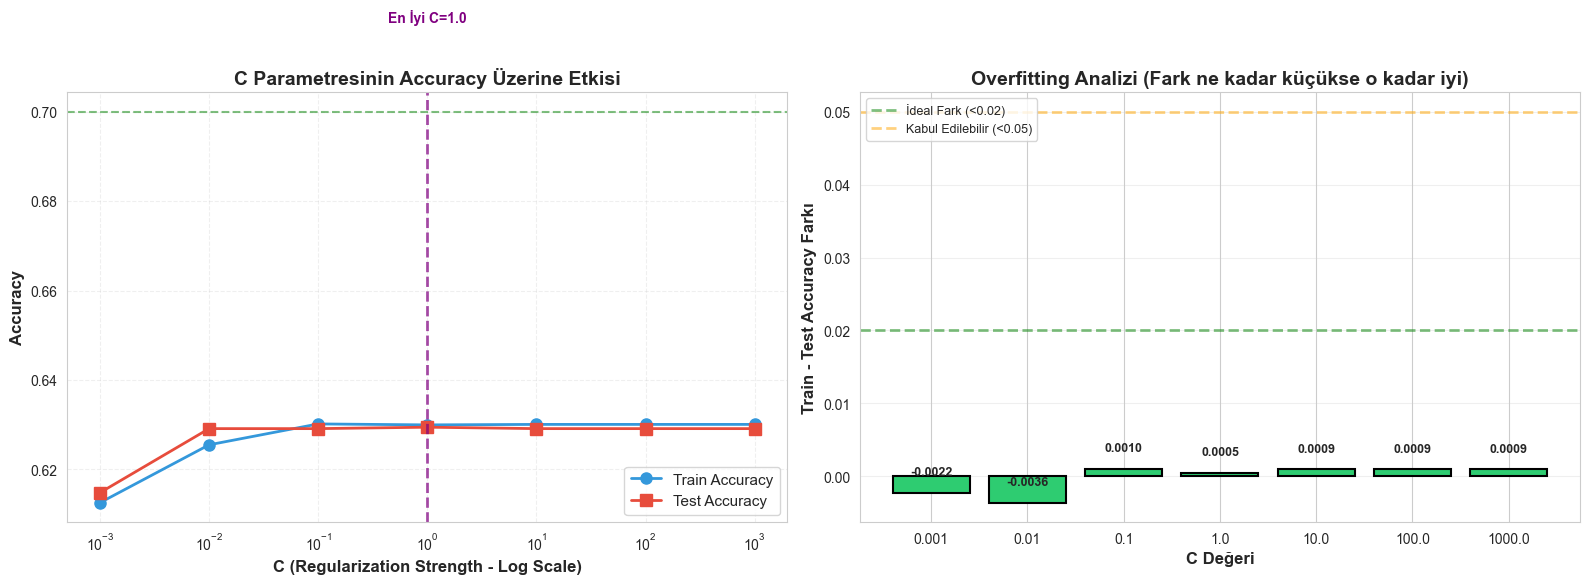


📊 GÖRSELLEŞTİRME YORUMU:
────────────────────────────────────────────────────────────────────────────────
🟢 Yeşil barlar: Overfitting yok, model iyi genelliyor
🟠 Turuncu barlar: Hafif overfitting, kabul edilebilir
🔴 Kırmızı barlar: Ciddi overfitting, model ezberliyor
────────────────────────────────────────────────────────────────────────────────


In [30]:
# C parametresinin etkisini görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol grafik: Train vs Test Accuracy
axes[0].plot(results_df['C'], results_df['Train_Accuracy'], 
             marker='o', linewidth=2, markersize=8, label='Train Accuracy', color='#3498db')
axes[0].plot(results_df['C'], results_df['Test_Accuracy'], 
             marker='s', linewidth=2, markersize=8, label='Test Accuracy', color='#e74c3c')
axes[0].set_xscale('log')  # Logaritmik skala (C değerleri geniş aralıkta)
axes[0].set_xlabel('C (Regularization Strength - Log Scale)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_title('C Parametresinin Accuracy Üzerine Etkisi', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].axhline(y=0.7, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='%70 Hedef')

# En iyi C değerini vurgula
best_idx = results_df['Test_Accuracy'].idxmax()
axes[0].axvline(x=results_df.loc[best_idx, 'C'], color='purple', 
                linestyle='--', linewidth=2, alpha=0.7)
axes[0].text(results_df.loc[best_idx, 'C'], 0.72, 
             f"En İyi C={results_df.loc[best_idx, 'C']}", 
             fontsize=10, fontweight='bold', color='purple', ha='center')

# Sağ grafik: Overfitting farkı (Train - Test)
colors_overfit = ['#2ecc71' if x < 0.02 else '#f39c12' if x < 0.05 else '#e74c3c' 
                  for x in results_df['Overfit_Difference']]
bars = axes[1].bar(range(len(results_df)), results_df['Overfit_Difference'], 
                   color=colors_overfit, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels([f"{c}" for c in results_df['C']], fontsize=10)
axes[1].set_xlabel('C Değeri', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Train - Test Accuracy Farkı', fontweight='bold', fontsize=12)
axes[1].set_title('Overfitting Analizi (Fark ne kadar küçükse o kadar iyi)', fontweight='bold', fontsize=14)
axes[1].axhline(y=0.02, color='green', linestyle='--', linewidth=2, alpha=0.5, label='İdeal Fark (<0.02)')
axes[1].axhline(y=0.05, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Kabul Edilebilir (<0.05)')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for i, (bar, val) in enumerate(zip(bars, results_df['Overfit_Difference'])):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 GÖRSELLEŞTİRME YORUMU:")
print("─" * 80)
print("🟢 Yeşil barlar: Overfitting yok, model iyi genelliyor")
print("🟠 Turuncu barlar: Hafif overfitting, kabul edilebilir")
print("🔴 Kırmızı barlar: Ciddi overfitting, model ezberliyor")
print("─" * 80)

## Penalty Karşılaştırması: L1 vs L2

**L1 (Lasso)** ve **L2 (Ridge)** düzenlemelerinin en büyük farkı:

🔬 PENALTY TİPLERİNİN KARŞILAŞTIRILMASI

────────────────────────────────────────────────────────────────────────────────
Penalty: l1        
  Train Acc: 0.6194
  Test Acc:  0.6215
  Sıfır katsayı sayısı: 0 (Kullanılmayan özellik)
  Aktif özellik sayısı: 8

────────────────────────────────────────────────────────────────────────────────
Penalty: l2        
  Train Acc: 0.6300
  Test Acc:  0.6295
  Sıfır katsayı sayısı: 0 (Kullanılmayan özellik)
  Aktif özellik sayısı: 8

────────────────────────────────────────────────────────────────────────────────
Penalty: None      
  Train Acc: 0.6301
  Test Acc:  0.6291
  Sıfır katsayı sayısı: 0 (Kullanılmayan özellik)
  Aktif özellik sayısı: 8

💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
• L1 (Lasso): Bazı katsayıları tam sıfıra indirir → Özellik seçimi yapar
• L2 (Ridge): Tüm katsayıları küçültür, ama sıfır yapmaz → Hepsini kullanır
• None: Düzenleme yok → Tüm özellikleri tam güçle kullanır (overfit

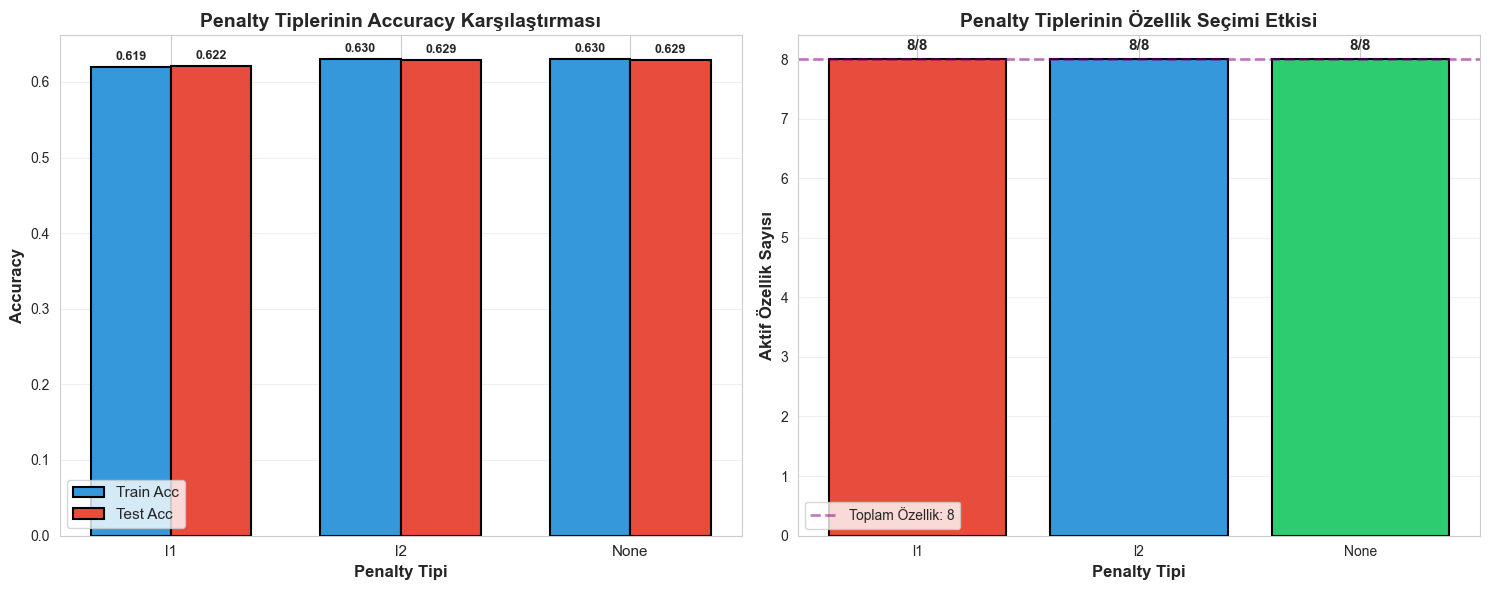


🎯 YBS PERSPEKTİFİ:
────────────────────────────────────────────────────────────────────────────────
• L1 tercih et → Çok sayıda özellik var, hangilerinin önemli olduğunu bilmiyorsun
• L2 tercih et → Tüm özelliklerin bilgi taşıdığından eminsin (varsayılan)
• None tercih et → Çok az veri var, düzenleme zarar verebilir
────────────────────────────────────────────────────────────────────────────────


In [31]:
# L1 ve L2 penalty karşılaştırması
penalties = ['l1', 'l2', None]
penalty_results = []

print("="*80)
print("🔬 PENALTY TİPLERİNİN KARŞILAŞTIRILMASI")
print("="*80)

for pen in penalties:
    if pen == 'l1':
        # L1 için uyumlu solver kullan
        model_pen = LogisticRegression(penalty='l1', solver='saga', C=1.0, 
                                       random_state=RANDOM_STATE, max_iter=1000)
    elif pen == 'l2':
        model_pen = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, 
                                       random_state=RANDOM_STATE, max_iter=1000)
    else:  # None
        model_pen = LogisticRegression(penalty=None, solver='lbfgs', 
                                       random_state=RANDOM_STATE, max_iter=1000)
    
    # Eğit
    model_pen.fit(X_train, y_train)
    
    # Performans
    train_acc = model_pen.score(X_train, y_train)
    test_acc = model_pen.score(X_test, y_test)
    
    # Sıfır katsayı sayısı (L1'in özellik seçimi yaptığını gösterir)
    zero_coefs = np.sum(np.abs(model_pen.coef_[0]) < 0.0001)
    
    penalty_results.append({
        'Penalty': pen if pen else 'None',
        'Train_Acc': train_acc,
        'Test_Acc': test_acc,
        'Zero_Coefficients': zero_coefs,
        'Active_Features': len(model_pen.coef_[0]) - zero_coefs
    })
    
    print(f"\n{'─'*80}")
    print(f"Penalty: {pen if pen else 'None':10}")
    print(f"  Train Acc: {train_acc:.4f}")
    print(f"  Test Acc:  {test_acc:.4f}")
    print(f"  Sıfır katsayı sayısı: {zero_coefs} (Kullanılmayan özellik)")
    print(f"  Aktif özellik sayısı: {len(model_pen.coef_[0]) - zero_coefs}")

print("="*80)

# DataFrame'e çevir
penalty_df = pd.DataFrame(penalty_results)

print("\n💡 YORUM:")
print("─" * 80)
print("• L1 (Lasso): Bazı katsayıları tam sıfıra indirir → Özellik seçimi yapar")
print("• L2 (Ridge): Tüm katsayıları küçültür, ama sıfır yapmaz → Hepsini kullanır")
print("• None: Düzenleme yok → Tüm özellikleri tam güçle kullanır (overfitting riski)")
print("─" * 80)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: Accuracy karşılaştırması
x_pos = np.arange(len(penalty_df))
width = 0.35
bars1 = axes[0].bar(x_pos - width/2, penalty_df['Train_Acc'], width, 
                    label='Train Acc', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x_pos + width/2, penalty_df['Test_Acc'], width, 
                    label='Test Acc', color='#e74c3c', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Penalty Tipi', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_title('Penalty Tiplerinin Accuracy Karşılaştırması', fontweight='bold', fontsize=14)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(penalty_df['Penalty'], fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                 f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                 f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Sağ: Aktif özellik sayısı
colors_feat = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[1].bar(penalty_df['Penalty'], penalty_df['Active_Features'], 
                   color=colors_feat, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Penalty Tipi', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Aktif Özellik Sayısı', fontweight='bold', fontsize=12)
axes[1].set_title('Penalty Tiplerinin Özellik Seçimi Etkisi', fontweight='bold', fontsize=14)
axes[1].axhline(y=len(X_train.columns), color='purple', linestyle='--', linewidth=2, 
                alpha=0.5, label=f'Toplam Özellik: {len(X_train.columns)}')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for bar, val in zip(bars, penalty_df['Active_Features']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{int(val)}/{len(X_train.columns)}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n🎯 YBS PERSPEKTİFİ:")
print("─" * 80)
print("• L1 tercih et → Çok sayıda özellik var, hangilerinin önemli olduğunu bilmiyorsun")
print("• L2 tercih et → Tüm özelliklerin bilgi taşıdığından eminsin (varsayılan)")
print("• None tercih et → Çok az veri var, düzenleme zarar verebilir")
print("─" * 80)

## **Sklearn Dokümantasyonunu Okuma Stratejisi**

**YBS Uzmanı kod ezberi yapmaz, dokümantasyon okumayı bilir!**

### 📚 Adım Adım Dokümantasyon Okuma

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph TD
    A["<b>🔍 1. Sınıf İmzasına Bak</b><br/><i>LogisticRegressionpenalty, C, solver, ...</i>"] --> B["<b>📖 2. Parameters Bölümü</b><br/><i>Her parametrenin açıklaması</i>"]
    
    B --> C["<b>💡 3. Attributes Bölümü</b><br/><i>Eğitim sonrası erişilebilir</i><br/>coef_, intercept_, n_iter_"]
    
    C --> D["<b>🎯 4. Methods Bölümü</b><br/><i>fit, predict, score, ...</i>"]
    
    D --> E["<b>📝 5. Examples Bölümü</b><br/><i>Çalışan kod örnekleri</i>"]
    
    E --> F["<b>🔗 6. See Also Bölümü</b><br/><i>İlgili diğer sınıflar</i>"]
    
    style A fill:#FFE4E1,stroke:#DC3545,stroke-width:2px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C fill:#D4EDDA,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style D fill:#FFF9C4,stroke:#FFC107,stroke-width:2px,color:#2C3E50
    style E fill:#E1D5E7,stroke:#9673A6,stroke-width:2px,color:#2C3E50
    style F fill:#D1ECF1,stroke:#17A2B8,stroke-width:2px,color:#2C3E50
```

### 🔎 **Örnek: LogisticRegression Dokümantasyonu**

**1. Sınıf İmzası:**
```python
LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, 
                   fit_intercept=True, intercept_scaling=1, 
                   class_weight=None, random_state=None, 
                   solver='lbfgs', max_iter=100, multi_class='auto', 
                   verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
```

**2. Parameters (En Önemli 5):**
- `penalty`: `{'l1', 'l2', 'elasticnet', None}` → Düzenleme tipi
- `C`: `float, default=1.0` → Regularization strength (ters orantılı)
- `solver`: `{'lbfgs', 'liblinear', 'saga', ...}` → Optimizasyon algoritması
- `max_iter`: `int, default=100` → Maksimum iterasyon sayısı
- `class_weight`: `dict or 'balanced'` → Dengesiz veri için sınıf ağırlıkları

**3. Attributes (Eğitim Sonrası):**
- `coef_`: Katsayılar (özellik ağırlıkları)
- `intercept_`: Kesim noktası (bias)
- `n_iter_`: Convergence'a ulaşmak için gereken iterasyon sayısı

**4. Methods:**
- `fit(X, y)`: Modeli eğit
- `predict(X)`: Tahmin yap (0/1)
- `predict_proba(X)`: Olasılık tahmini
- `score(X, y)`: Accuracy hesapla

**5. Examples:**
Dokümantasyonda çalışan kod örnekleri var → Kopyala-yapıştır-öğren!

### 💡 **YBS İçin Dokümantasyon Okuma İpuçları**

1. **Parametreleri hepsini ezberleme:**  
   Sadece en çok kullanılanları bil (penalty, C, solver), gerisini gerektiğinde oku.

2. **Default değerlere güven:**  
   Sklearn'in varsayılan değerleri genelde mantıklıdır. Değiştirmeden önce neden değiştirdiğini bil.

3. **Examples bölümü altın değerinde:**  
   Kod örnekleri direkt çalışır, oradan başla.

4. **See Also bölümüne dikkat:**  
   Benzer problemler için hangi alternatif algoritmalar var? (örn: SGDClassifier, RidgeClassifier)

5. **Uyarılara (Warnings) kulak ver:**  
   "ConvergenceWarning: lbfgs failed to converge..." → `max_iter` artır!

**🔗 Sklearn Dokümantasyon Linki:**  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

**📌 Önemli:** Dokümantasyonu açıp yukarıdan aşağı oku. 5 dakika dokümantasyon okumak, 2 saat deneme-yanılmadan iyidir!

**🏁 Section 7 Tamamlandı**

Bu adımda:
- ✅ Parametre vs Hiperparametre farkını öğrendik
- ✅ LogisticRegression'ın temel hiperparametrelerini (penalty, C, solver, max_iter, class_weight) detaylıca inceledik
- ✅ Farklı C değerleriyle denemeler yaparak regularization gücünün etkisini gördük
- ✅ L1 (Lasso) ve L2 (Ridge) penalty tiplerini karşılaştırdık ve özellik seçimi kavramını anladık
- ✅ Sklearn dokümantasyonunu etkili okuma stratejisini öğrendik

**🎯 YBS Perspektifi - Hiperparametre Felsefesi:**  
Hiperparametreler modelin "öğrenme politikası"dır. **C değeri → Ne kadar risk alacağız?** (Basit mi karmaşık mı olsun?) **Penalty tipi → Hangi özelliklere güveniyoruz?** (Hepsine mi, seçili birkaçına mı?) **YBS perspektifinden hiperparametre seçimi, iş hedeflerine göre risk-yarar dengesini kurmaktır.**

# 🔍 **Section 8: Otomatik Hiperparametre Optimizasyonu**

**Hedef:** Elle tek tek denemek yerine, GridSearchCV ve RandomizedSearchCV ile en iyi hiperparametre kombinasyonunu otomatik bulmak.

**YBS Bağlamı:**  
Bir kampanya için model optimize ederken "C=0.1 mi 1.0 mı daha iyi?" diye tek tek denemek zaman kaybıdır. **Otomatik arama** sistemleri:
- Tüm olasılıkları sistematik dener (GridSearch)
- Rastgele örnekleme ile hızlı sonuç bulur (RandomizedSearch)
- Cross-validation ile güvenilir değerlendirme yapar

Bu bölümde hem **kapsamlı arama** hem de **hızlı arama** stratejilerini öğreneceğiz.

## **Cross-Validation (Çapraz Doğrulama) - K-Fold**

**Sorun:** Tek bir train-test split'e göre değerlendirme yapmak risklidir. Test setine şans eseri iyi düşebilir.

**Çözüm:** K-Fold Cross-Validation → Veriyi K parçaya böl, her seferinde farklı bir parçayı test seti yap.

### **K-Fold Mantığı (K=5 Örneği)**

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph TD
    A["<b>📊 Tüm Veri Seti</b><br/>9,430 müşteri train"] --> B["<b>5 Parçaya Böl</b><br/>Her parça ~1,886 müşteri"]
    
    B --> C1["<b>Fold 1</b><br/>🔵🔵🔵🔵🔴<br/>Test: Parça 5"]
    B --> C2["<b>Fold 2</b><br/>🔵🔵🔵🔴🔵<br/>Test: Parça 4"]
    B --> C3["<b>Fold 3</b><br/>🔵🔵🔴🔵🔵<br/>Test: Parça 3"]
    B --> C4["<b>Fold 4</b><br/>🔵🔴🔵🔵🔵<br/>Test: Parça 2"]
    B --> C5["<b>Fold 5</b><br/>🔴🔵🔵🔵🔵<br/>Test: Parça 1"]
    
    C1 --> D["<b>5 Accuracy Skoru</b>"]
    C2 --> D
    C3 --> D
    C4 --> D
    C5 --> D
    
    D --> E["<b>📈 Ortalama Accuracy</b><br/><i>Daha güvenilir sonuç</i>"]
    
    style A fill:#FFDAB9,stroke:#8B4513,stroke-width:3px,color:#2C3E50
    style B fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style C1 fill:#FFF9C4,stroke:#FFC107,stroke-width:1px,color:#2C3E50
    style C2 fill:#FFF9C4,stroke:#FFC107,stroke-width:1px,color:#2C3E50
    style C3 fill:#FFF9C4,stroke:#FFC107,stroke-width:1px,color:#2C3E50
    style C4 fill:#FFF9C4,stroke:#FFC107,stroke-width:1px,color:#2C3E50
    style C5 fill:#FFF9C4,stroke:#FFC107,stroke-width:1px,color:#2C3E50
    style D fill:#E8F5E9,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style E fill:#D4EDDA,stroke:#28A745,stroke-width:3px,color:#2C3E50
```

**Avantajlar:**
- ✅ Her veri noktası hem train hem test setinde kullanılır
- ✅ Şansa bağlı sonuçları minimize eder
- ✅ Küçük veri setlerinde çok etkilidir
- ✅ Model'in genelleme yeteneğini daha doğru ölçer

**YBS Perspektifi:**  
K-Fold CV, "tek müşteri grubuna değil, 5 farklı müşteri grubuna test ettik" anlamına gelir. Sonuç daha güvenilirdir.

**Varsayılan:** GridSearchCV ve RandomizedSearchCV içinde `cv=5` (5-Fold Cross-Validation) kullanılır.

## **GridSearchCV: Kapsamlı Hiperparametre Araması**

**Mantık:** Belirtiğiniz tüm hiperparametre kombinasyonlarını sistematik olarak dener.

**Örnek:** 3 C değeri × 2 penalty tipi × 2 solver = **12 kombinasyon**  
Her kombinasyon 5-Fold CV ile test edilir → **60 model eğitimi** (12 × 5)

**Avantaj:** Hiçbir kombinasyonu kaçırmaz, en iyisini garantiler.  
**Dezavantaj:** Çok uzun sürebilir (kombinasyon sayısı arttıkça).

## **GridSearchCV Uygulaması**

In [35]:
from sklearn.model_selection import GridSearchCV
import time

# Hiperparametre grid'i tanımlama
param_grid = {
    'C': [0.01, 0.1, 1.0, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],  # saga hem l1 hem l2 destekler
    'max_iter': [1000]
}

print("="*80)
print("🔍 GRIDSEARCHCV - KAPSAMLI HİPERPARAMETRE ARAMASI")
print("="*80)
print(f"Toplam kombinasyon sayısı: {len(param_grid['C']) * len(param_grid['penalty'])}")
print(f"Cross-validation: 5-Fold")
print(f"Toplam model eğitimi: {len(param_grid['C']) * len(param_grid['penalty']) * 5}")
print("="*80)
print("\n⏳ Arama başlıyor... (Bu birkaç dakika sürebilir)")
print("📊 İlerleme takibi için verbose=1 kullanılıyor\n")

# Base model
base_model = LogisticRegression(random_state=RANDOM_STATE)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,  # 5-Fold Cross-Validation
    scoring='accuracy',  # Metrik
    n_jobs=1,  # Tek çekirdek: _posixsubprocess hatasını önlemek için
    verbose=1,  # İlerleme göster
)

# Eğitim süresi ölçme
start_time = time.time()

# Fit (Arama başlıyor)
grid_search.fit(X_train, y_train)

# Süre hesaplama
grid_time = time.time() - start_time

print("\n" + "="*80)
print("✅ GRIDSEARCHCV TAMAMLANDI!")
print("="*80)
print(f"⏱️  Toplam süre: {grid_time:.2f} saniye ({grid_time/60:.2f} dakika)")
print(f"🏆 En iyi parametreler: {grid_search.best_params_}")
print(f"📊 En iyi CV score: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")
print("="*80)

# En iyi modeli test setinde değerlendirme
best_model_grid = grid_search.best_estimator_
test_score_grid = best_model_grid.score(X_test, y_test)

print(f"\n🎯 Test Seti Performansı (En İyi Model):")
print(f"   Accuracy: {test_score_grid:.4f} ({test_score_grid*100:.2f}%)")
print("="*80)

🔍 GRIDSEARCHCV - KAPSAMLI HİPERPARAMETRE ARAMASI
Toplam kombinasyon sayısı: 10
Cross-validation: 5-Fold
Toplam model eğitimi: 50

⏳ Arama başlıyor... (Bu birkaç dakika sürebilir)
📊 İlerleme takibi için verbose=1 kullanılıyor

Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ GRIDSEARCHCV TAMAMLANDI!
⏱️  Toplam süre: 29.23 saniye (0.49 dakika)
🏆 En iyi parametreler: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
📊 En iyi CV score: 0.6158 (61.58%)

🎯 Test Seti Performansı (En İyi Model):
   Accuracy: 0.6212 (62.12%)



📋 EN İYİ 10 HİPERPARAMETRE KOMBİNASYONU:

1. Sıra:
   Parametreler: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
   CV Score: 0.6158 (±0.0081)

1. Sıra:
   Parametreler: {'C': 100, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
   CV Score: 0.6158 (±0.0081)

1. Sıra:
   Parametreler: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
   CV Score: 0.6158 (±0.0081)

4. Sıra:
   Parametreler: {'C': 1.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
   CV Score: 0.6157 (±0.0081)

4. Sıra:
   Parametreler: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
   CV Score: 0.6157 (±0.0081)

6. Sıra:
   Parametreler: {'C': 1.0, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
   CV Score: 0.6154 (±0.0082)

7. Sıra:
   Parametreler: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
   CV Score: 0.6154 (±0.0078)

8. Sıra:
   Parametreler: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
   CV Score: 0.6153 (±

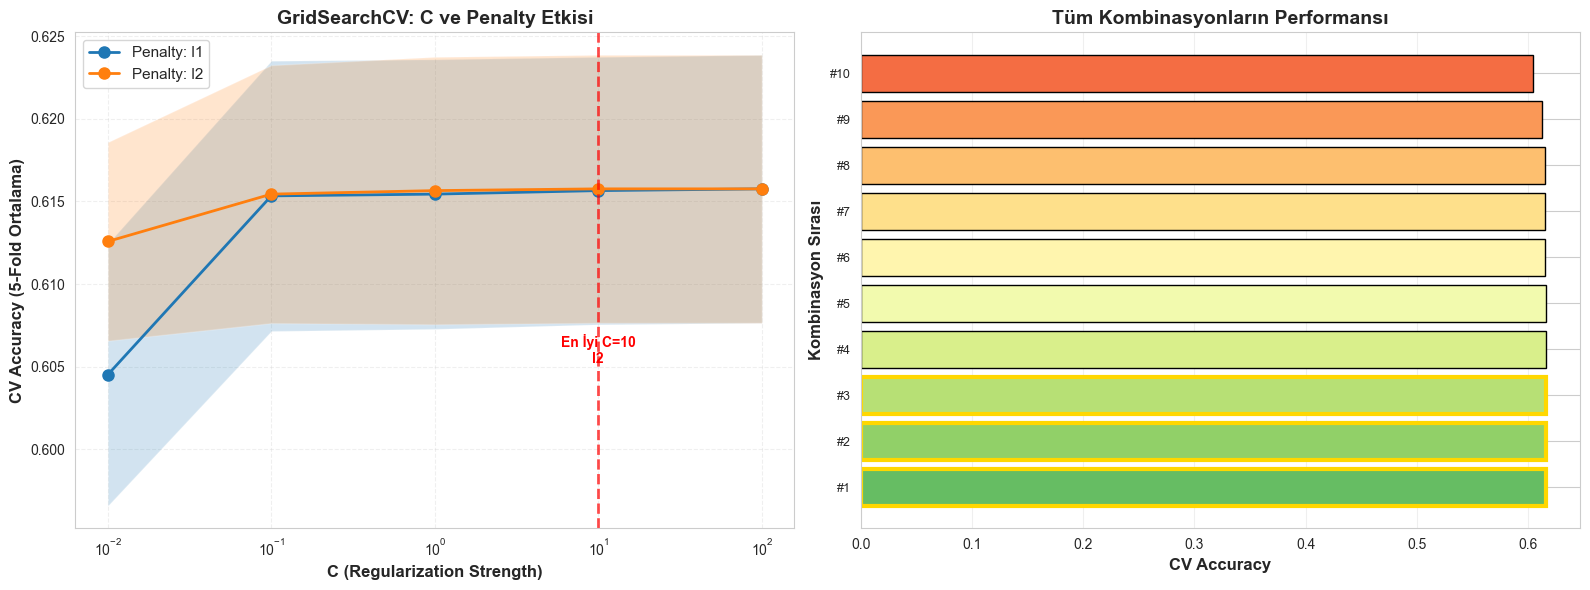


💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
• Gölgeli alan: ±1 std (standart sapma) → CV skorlarının tutarlılığını gösterir
• Düşük std: Model kararlı, farklı fold'larda benzer performans
• Yüksek std: Model dengesiz, bazı fold'larda iyi bazılarında kötü
────────────────────────────────────────────────────────────────────────────────


In [36]:
# GridSearchCV sonuçlarını detaylı analiz
cv_results = pd.DataFrame(grid_search.cv_results_)

# En iyi 10 sonucu göster
print("\n📋 EN İYİ 10 HİPERPARAMETRE KOMBİNASYONU:")
print("="*80)

top_10 = cv_results.sort_values('rank_test_score').head(10)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

for idx, row in top_10.iterrows():
    print(f"\n{int(row['rank_test_score'])}. Sıra:")
    print(f"   Parametreler: {row['params']}")
    print(f"   CV Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")

print("="*80)

# Görselleştirme: C parametresinin etkisi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Her penalty tipi için ayrı çizgi
for penalty_type in param_grid['penalty']:
    subset = cv_results[cv_results['param_penalty'] == penalty_type]
    
    # C değerlerine göre sırala
    subset = subset.sort_values('param_C')
    
    axes[0].plot(subset['param_C'], subset['mean_test_score'], 
                 marker='o', linewidth=2, markersize=8, label=f'Penalty: {penalty_type}')
    axes[0].fill_between(subset['param_C'], 
                         subset['mean_test_score'] - subset['std_test_score'],
                         subset['mean_test_score'] + subset['std_test_score'],
                         alpha=0.2)

axes[0].set_xscale('log')
axes[0].set_xlabel('C (Regularization Strength)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('CV Accuracy (5-Fold Ortalama)', fontweight='bold', fontsize=12)
axes[0].set_title('GridSearchCV: C ve Penalty Etkisi', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')

# En iyi parametreyi vurgula
best_c = grid_search.best_params_['C']
best_penalty = grid_search.best_params_['penalty']
axes[0].axvline(x=best_c, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].text(best_c, axes[0].get_ylim()[0] + 0.01, 
             f"En İyi C={best_c}\n{best_penalty}", 
             fontsize=10, fontweight='bold', color='red', ha='center')

# Sağ: Tüm kombinasyonların sıralaması
cv_results_sorted = cv_results.sort_values('rank_test_score')
colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cv_results_sorted)))

bars = axes[1].barh(range(len(cv_results_sorted)), 
                    cv_results_sorted['mean_test_score'],
                    color=colors_rank, edgecolor='black', linewidth=1)
axes[1].set_xlabel('CV Accuracy', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Kombinasyon Sırası', fontweight='bold', fontsize=12)
axes[1].set_title('Tüm Kombinasyonların Performansı', fontweight='bold', fontsize=14)
axes[1].set_yticks(range(len(cv_results_sorted)))
axes[1].set_yticklabels([f"#{i+1}" for i in range(len(cv_results_sorted))], fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

# En iyi 3'ü vurgula
for i in range(min(3, len(bars))):
    bars[i].set_edgecolor('gold')
    bars[i].set_linewidth(3)

plt.tight_layout()
plt.show()

print("\n💡 YORUM:")
print("─" * 80)
print("• Gölgeli alan: ±1 std (standart sapma) → CV skorlarının tutarlılığını gösterir")
print("• Düşük std: Model kararlı, farklı fold'larda benzer performans")
print("• Yüksek std: Model dengesiz, bazı fold'larda iyi bazılarında kötü")
print("─" * 80)

## **RandomizedSearchCV: Hızlı Hiperparametre Araması**

**Mantık:** Tüm kombinasyonları denemek yerine, rastgele `n_iter` kadar kombinasyon seç ve dene.

**Avantaj:** Çok daha hızlı, özellikle büyük parametre uzaylarında.  
**Dezavantaj:** En iyi kombinasyonu kaçırma riski var (ama genelde iyi sonuç bulur).

**Kullanım Senaryosu:**
- GridSearch: "Kesin en iyiyi bulmalıyım, süre önemli değil"
- RandomizedSearch: "Makul bir sürede iyi bir sonuç istiyorum"

## **RandomizedSearchCV Uygulaması**

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

# Parametre dağılımları (sürekli dağılımlarla daha geniş arama)
param_distributions = {
    'C': loguniform(0.001, 100),  # Logaritmik ölçekte 0.001-100 arası rastgele
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'max_iter': [1000, 2000]
}

print("="*80)
print("🎲 RANDOMIZEDSEARCHCV - HIZLI HİPERPARAMETRE ARAMASI")
print("="*80)
print(f"Rastgele deneme sayısı: 20 (n_iter=20)")
print(f"Cross-validation: 5-Fold")
print(f"Toplam model eğitimi: {20 * 5} (GridSearchCV'ye göre çok daha az)")
print("="*80)
print("\n⏳ Arama başlıyor...\n")

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,  # Kaç rastgele kombinasyon denensin?
    cv=5,
    scoring='accuracy',
    n_jobs=1,  # _posixsubprocess hatasını önlemek için tek çekirdek
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

# Eğitim süresi ölçme
start_time = time.time()

# Fit
random_search.fit(X_train, y_train)

# Süre hesaplama
random_time = time.time() - start_time

print("\n" + "="*80)
print("✅ RANDOMIZEDSEARCHCV TAMAMLANDI!")
print("="*80)
print(f"⏱️  Toplam süre: {random_time:.2f} saniye ({random_time/60:.2f} dakika)")
print(f"🏆 En iyi parametreler: {random_search.best_params_}")
print(f"📊 En iyi CV score: {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)")
print("="*80)

# Test performansı
best_model_random = random_search.best_estimator_
test_score_random = best_model_random.score(X_test, y_test)

print(f"\n🎯 Test Seti Performansı (En İyi Model):")
print(f"   Accuracy: {test_score_random:.4f} ({test_score_random*100:.2f}%)")
print("="*80)

# Hız karşılaştırması
print(f"\n⚡ HIZ KARŞILAŞTIRMASI:")
print("─" * 80)
print(f"GridSearchCV:       {grid_time:.2f} saniye")
print(f"RandomizedSearchCV: {random_time:.2f} saniye")
print(f"Hız kazancı:        {grid_time/random_time:.1f}x daha hızlı")
print("─" * 80)

# Performans karşılaştırması
print(f"\n📊 PERFORMANS KARŞILAŞTIRMASI:")
print("─" * 80)
print(f"GridSearchCV CV Score:       {grid_search.best_score_:.4f}")
print(f"RandomizedSearchCV CV Score: {random_search.best_score_:.4f}")
print(f"Fark:                        {abs(grid_search.best_score_ - random_search.best_score_):.4f}")
print("─" * 80)
print("\n💡 YORUM:")
print("RandomizedSearch çok daha hızlı ama genelde GridSearch'e yakın sonuç bulur!")
print("─" * 80)

🎲 RANDOMIZEDSEARCHCV - HIZLI HİPERPARAMETRE ARAMASI
Rastgele deneme sayısı: 20 (n_iter=20)
Cross-validation: 5-Fold
Toplam model eğitimi: 100 (GridSearchCV'ye göre çok daha az)

⏳ Arama başlıyor...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ RANDOMIZEDSEARCHCV TAMAMLANDI!
⏱️  Toplam süre: 83.46 saniye (1.39 dakika)
🏆 En iyi parametreler: {'C': np.float64(1.0129197956845732), 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
📊 En iyi CV score: 0.6247 (62.47%)

🎯 Test Seti Performansı (En İyi Model):
   Accuracy: 0.6202 (62.02%)

⚡ HIZ KARŞILAŞTIRMASI:
────────────────────────────────────────────────────────────────────────────────
GridSearchCV:       29.23 saniye
RandomizedSearchCV: 83.46 saniye
Hız kazancı:        0.4x daha hızlı
────────────────────────────────────────────────────────────────────────────────

📊 PERFORMANS KARŞILAŞTIRMASI:
────────────────────────────────────────────────────────────────────────────────
GridSearchCV CV Score:       0.6158
Random

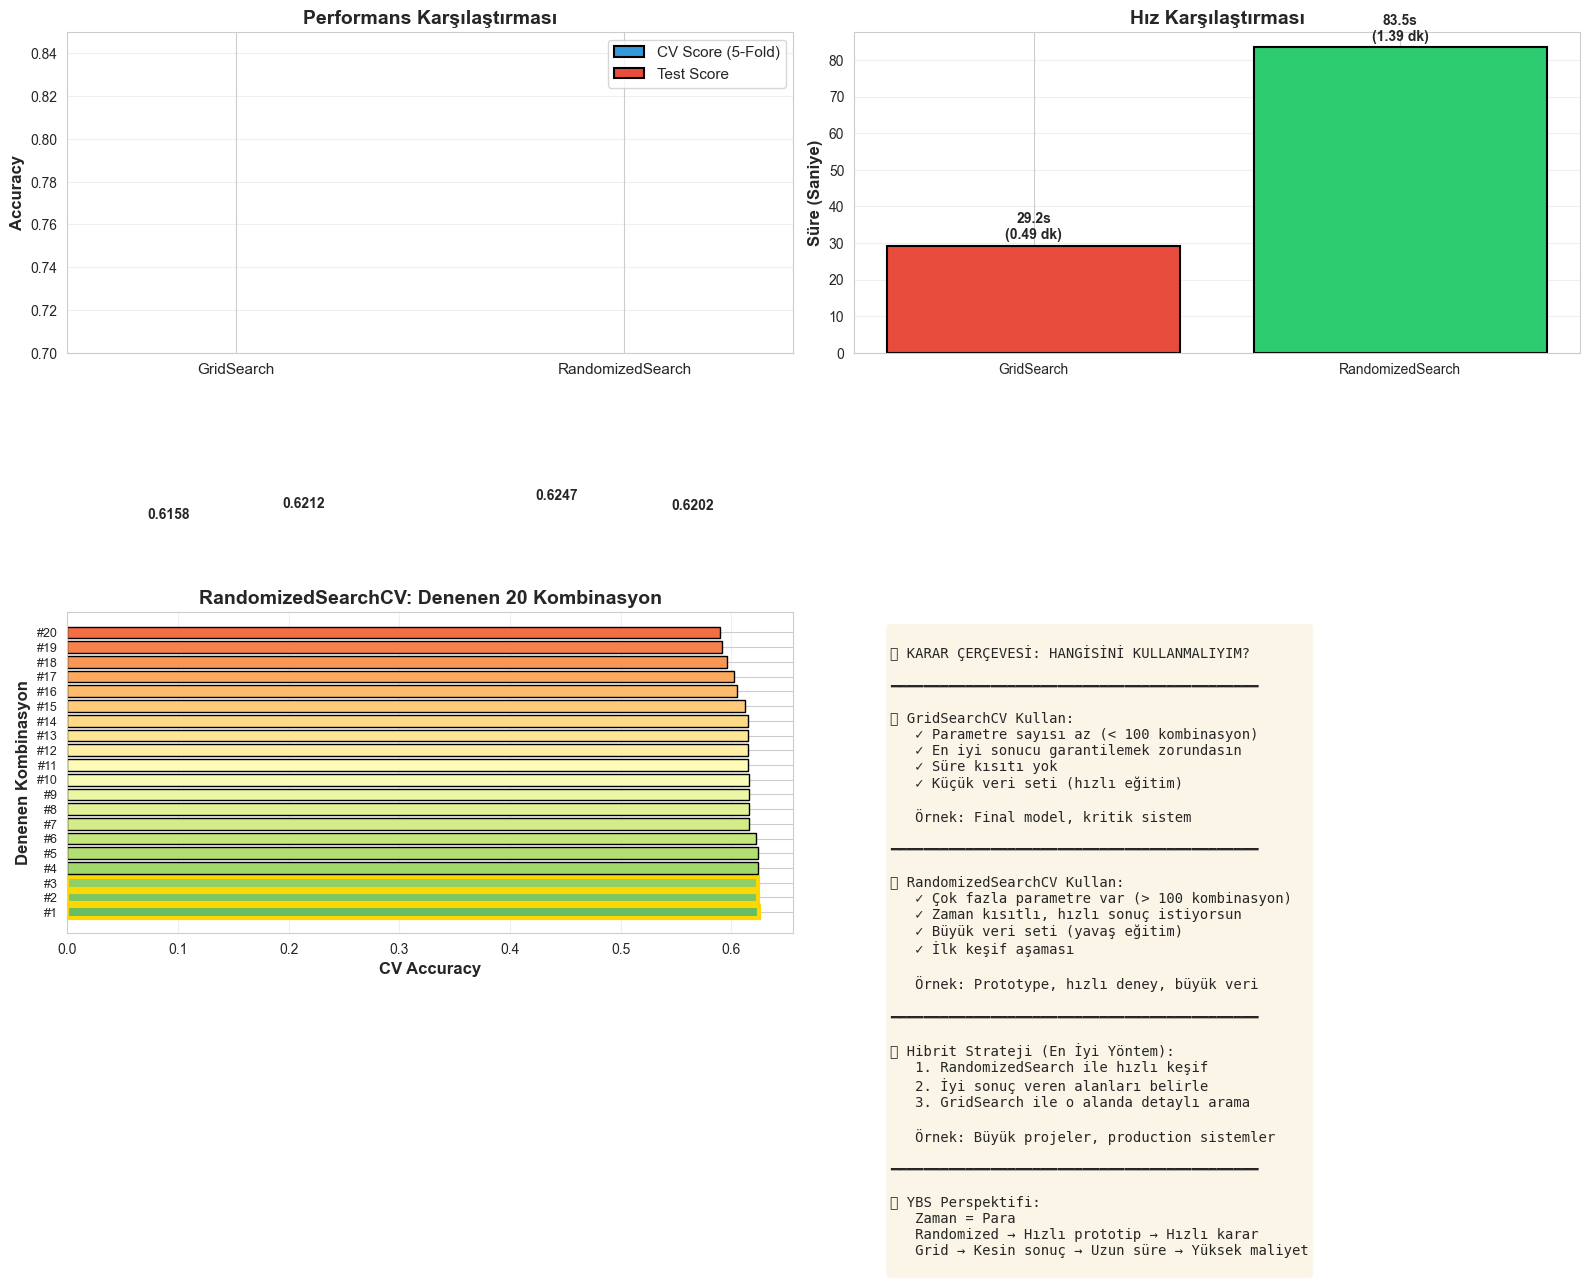

In [39]:
# GridSearchCV vs RandomizedSearchCV Görsel Karşılaştırma
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. CV Score Karşılaştırması
methods = ['GridSearch', 'RandomizedSearch']
cv_scores = [grid_search.best_score_, random_search.best_score_]
test_scores = [test_score_grid, test_score_random]

x_pos = np.arange(len(methods))
width = 0.35

bars1 = axes[0, 0].bar(x_pos - width/2, cv_scores, width, 
                       label='CV Score (5-Fold)', color='#3498db', 
                       edgecolor='black', linewidth=1.5)
bars2 = axes[0, 0].bar(x_pos + width/2, test_scores, width, 
                       label='Test Score', color='#e74c3c', 
                       edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('Accuracy', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Performans Karşılaştırması', fontweight='bold', fontsize=14)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(methods, fontsize=11)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0.7, 0.85])

# Değerleri bar üzerine yazma
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Süre Karşılaştırması
times = [grid_time, random_time]
colors_time = ['#e74c3c', '#2ecc71']
bars = axes[0, 1].bar(methods, times, color=colors_time, 
                      edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('Süre (Saniye)', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Hız Karşılaştırması', fontweight='bold', fontsize=14)
axes[0, 1].grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazma
for bar, val in zip(bars, times):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{val:.1f}s\n({val/60:.2f} dk)', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. RandomizedSearch denenen kombinasyonlar
random_results = pd.DataFrame(random_search.cv_results_)
random_results_sorted = random_results.sort_values('rank_test_score')

colors_random = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(random_results_sorted)))
bars = axes[1, 0].barh(range(len(random_results_sorted)), 
                       random_results_sorted['mean_test_score'],
                       color=colors_random, edgecolor='black', linewidth=1)
axes[1, 0].set_xlabel('CV Accuracy', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Denenen Kombinasyon', fontweight='bold', fontsize=12)
axes[1, 0].set_title('RandomizedSearchCV: Denenen 20 Kombinasyon', 
                     fontweight='bold', fontsize=14)
axes[1, 0].set_yticks(range(len(random_results_sorted)))
axes[1, 0].set_yticklabels([f"#{i+1}" for i in range(len(random_results_sorted))], fontsize=9)
axes[1, 0].grid(axis='x', alpha=0.3)

# En iyi 3'ü vurgula
for i in range(min(3, len(bars))):
    bars[i].set_edgecolor('gold')
    bars[i].set_linewidth(3)

# 4. Karar Çerçevesi (Metin tablosu)
axes[1, 1].axis('off')

decision_text = """
🎯 KARAR ÇERÇEVESİ: HANGİSİNİ KULLANMALIYIM?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 GridSearchCV Kullan:
   ✓ Parametre sayısı az (< 100 kombinasyon)
   ✓ En iyi sonucu garantilemek zorundasın
   ✓ Süre kısıtı yok
   ✓ Küçük veri seti (hızlı eğitim)
   
   Örnek: Final model, kritik sistem

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 RandomizedSearchCV Kullan:
   ✓ Çok fazla parametre var (> 100 kombinasyon)
   ✓ Zaman kısıtlı, hızlı sonuç istiyorsun
   ✓ Büyük veri seti (yavaş eğitim)
   ✓ İlk keşif aşaması
   
   Örnek: Prototype, hızlı deney, büyük veri

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 Hibrit Strateji (En İyi Yöntem):
   1. RandomizedSearch ile hızlı keşif
   2. İyi sonuç veren alanları belirle
   3. GridSearch ile o alanda detaylı arama
   
   Örnek: Büyük projeler, production sistemler

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 YBS Perspektifi:
   Zaman = Para
   Randomized → Hızlı prototip → Hızlı karar
   Grid → Kesin sonuç → Uzun süre → Yüksek maliyet
"""

axes[1, 1].text(0.05, 0.95, decision_text, 
                transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# 🏆 **BONUS: 12 Farklı ML Algoritması Karşılaştırması**

**Hedef:** Logistic Regression'ın yanı sıra 12 farklı makine öğrenmesi algoritmasını aynı veri setinde eğitip, en iyi performans göstereni bulmak.

**YBS Bağlamı:**  
Gerçek dünyada tek bir algoritmaya bağlı kalmayız. **Birden fazla algoritmayı dener** ve **en iyi performans göstereni seçeriz**. Bu yaklaşım:
- Model seçim sürecini objektif hale getirir
- Her algoritmanın güçlü-zayıf yönlerini görürüz
- En iyi sonucu garanti ederiz

Bu bölümde 12 farklı algoritma eğitip, performanslarını karşılaştıracağız ve **en iyi modelin confusion matrix'ini** detaylı inceleyeceğiz.

## 12 Algoritma ile Model Eğitimi

Aşağıdaki algoritmaları karşılaştıracağız:

1. **Logistic Regression** - Linear model (mevcut)
2. **Decision Tree** - Tree-based, non-linear
3. **Random Forest** - Ensemble of trees
4. **Gradient Boosting** - Boosting ensemble
5. **XGBoost** - Extreme Gradient Boosting
6. **LightGBM** - Microsoft's gradient boosting
7. **SVM (Linear)** - Support Vector Machine (linear kernel)
8. **SVM (RBF)** - Support Vector Machine (non-linear kernel)
9. **K-Nearest Neighbors** - Instance-based learning
10. **Naive Bayes** - Probabilistic classifier
11. **AdaBoost** - Adaptive Boosting
12. **Extra Trees** - Extremely Randomized Trees

In [40]:
# Gerekli kütüphaneleri import et
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import RidgeClassifier
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# XGBoost ve LightGBM için try-except (yüklü değilse atla)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost yüklü değil, atlanıyor.")

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False
    print("⚠️ LightGBM yüklü değil, atlanıyor.")

# 12 farklı algoritma tanımlama
models = {
    '1. Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    '2. Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    '3. Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10),
    '4. Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    '5. SVM (Linear)': SVC(kernel='linear', random_state=RANDOM_STATE, max_iter=1000),
    '6. SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE, max_iter=1000),
    '7. K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    '8. Naive Bayes': GaussianNB(),
    '9. AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE, n_estimators=100),
    '10. Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10),
    '11. Ridge Classifier': RidgeClassifier(random_state=RANDOM_STATE),
}

# XGBoost ve LightGBM ekle (varsa)
if xgb_available:
    models['12. XGBoost'] = XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=6, 
                                          eval_metric='logloss', verbosity=0)
if lgbm_available:
    models['13. LightGBM'] = LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10, 
                                           verbosity=-1)

print("="*80)
print(f"🤖 TOPLAM {len(models)} FARKLI ALGORİTMA EĞİTİLECEK")
print("="*80)
print("\n📋 Algoritma Listesi:")
for i, name in enumerate(models.keys(), 1):
    print(f"   {name}")
print("="*80)

🤖 TOPLAM 13 FARKLI ALGORİTMA EĞİTİLECEK

📋 Algoritma Listesi:
   1. Logistic Regression
   2. Decision Tree
   3. Random Forest
   4. Gradient Boosting
   5. SVM (Linear)
   6. SVM (RBF)
   7. K-Nearest Neighbors
   8. Naive Bayes
   9. AdaBoost
   10. Extra Trees
   11. Ridge Classifier
   12. XGBoost
   13. LightGBM


In [41]:
# Tüm modelleri eğit ve sonuçları kaydet
results_comparison = []

print("\n⏳ Model eğitimleri başlıyor...\n")

# tqdm ile progress tracking
for model_name, model_instance in tqdm(models.items(), desc="🤖 Modeller Eğitiliyor", 
                                       bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"):
    
    # Eğitim süresi ölç
    start_time = time.time()
    
    try:
        # Modeli eğit
        model_instance.fit(X_train, y_train)
        
        # Train ve test tahminleri
        y_train_pred = model_instance.predict(X_train)
        y_test_pred = model_instance.predict(X_test)
        
        # Train ve test accuracy
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        # Test seti için precision, recall, f1
        test_precision = precision_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        
        # Eğitim süresi
        training_time = time.time() - start_time
        
        # Overfitting kontrolü
        overfit_diff = train_acc - test_acc
        
        # Sonuçları kaydet
        results_comparison.append({
            'Model': model_name,
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Precision': test_precision,
            'Recall': test_recall,
            'F1_Score': test_f1,
            'Training_Time': training_time,
            'Overfit_Diff': overfit_diff,
            'Model_Instance': model_instance  # En iyi modeli bulmak için
        })
        
    except Exception as e:
        print(f"\n❌ {model_name} eğitilirken hata: {str(e)}")
        continue

print("\n✅ Tüm modeller eğitildi!")
print("="*80)

# DataFrame'e çevir
results_df_comparison = pd.DataFrame(results_comparison)

# En iyi modeli bul (Test Accuracy'ye göre)
best_model_idx = results_df_comparison['Test_Accuracy'].idxmax()
best_model_name = results_df_comparison.loc[best_model_idx, 'Model']
best_model_instance = results_df_comparison.loc[best_model_idx, 'Model_Instance']
best_test_acc = results_df_comparison.loc[best_model_idx, 'Test_Accuracy']

print(f"\n🏆 EN İYİ MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print("="*80)


⏳ Model eğitimleri başlıyor...



🤖 Modeller Eğitiliyor: 100%|██████████| 13/13 [00:08<00:00]


✅ Tüm modeller eğitildi!

🏆 EN İYİ MODEL: 3. Random Forest
   Test Accuracy: 0.6304 (63.04%)


In [42]:
# Sonuçları sıralı göster
print("\n📊 DETAYLI SONUÇLAR (Test Accuracy'ye göre sıralanmış):")
print("="*120)

results_sorted = results_df_comparison.sort_values('Test_Accuracy', ascending=False)

# Çıktı tablosu
print(f"{'Sıra':<5} {'Model':<30} {'Train Acc':<12} {'Test Acc':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Süre(s)':<10} {'Overfit':<10}")
print("="*120)

for idx, row in enumerate(results_sorted.iterrows(), 1):
    _, data = row
    
    # Overfit göstergesi
    overfit_icon = "🔴" if data['Overfit_Diff'] > 0.05 else "🟠" if data['Overfit_Diff'] > 0.02 else "🟢"
    
    # En iyi modeli vurgula
    star = "⭐" if data['Model'] == best_model_name else "  "
    
    print(f"{star}{idx:<3} {data['Model']:<30} "
          f"{data['Train_Accuracy']:.4f}      "
          f"{data['Test_Accuracy']:.4f}      "
          f"{data['Precision']:.4f}      "
          f"{data['Recall']:.4f}      "
          f"{data['F1_Score']:.4f}      "
          f"{data['Training_Time']:>6.2f}    "
          f"{overfit_icon} {data['Overfit_Diff']:>+.4f}")

print("="*120)
print("\n💡 GÖSTERGE:")
print("   ⭐ En iyi model (Test Accuracy)")
print("   🟢 İyi genelleme (Overfit < 0.02)")
print("   🟠 Kabul edilebilir (0.02 < Overfit < 0.05)")
print("   🔴 Overfitting riski (Overfit > 0.05)")
print("="*120)


📊 DETAYLI SONUÇLAR (Test Accuracy'ye göre sıralanmış):
Sıra  Model                          Train Acc    Test Acc     Precision    Recall       F1           Süre(s)    Overfit   
⭐1   3. Random Forest               0.8122      0.6304      0.6477      0.7739      0.7052        0.62    🔴 +0.1818
  2   11. Ridge Classifier           0.6299      0.6298      0.6466      0.7762      0.7055        0.01    🟢 +0.0001
  3   8. Naive Bayes                 0.6279      0.6298      0.6543      0.7461      0.6972        0.01    🟢 -0.0019
  4   1. Logistic Regression         0.6300      0.6295      0.6460      0.7773      0.7056        0.13    🟢 +0.0005
  5   10. Extra Trees                0.7458      0.6295      0.6363      0.8202      0.7166        0.29    🔴 +0.1163
  6   4. Gradient Boosting           0.6631      0.6291      0.6473      0.7706      0.7036        0.81    🟠 +0.0339
  7   9. AdaBoost                    0.6373      0.6247      0.6450      0.7628      0.6990        0.41    🟢 +0.0126
  

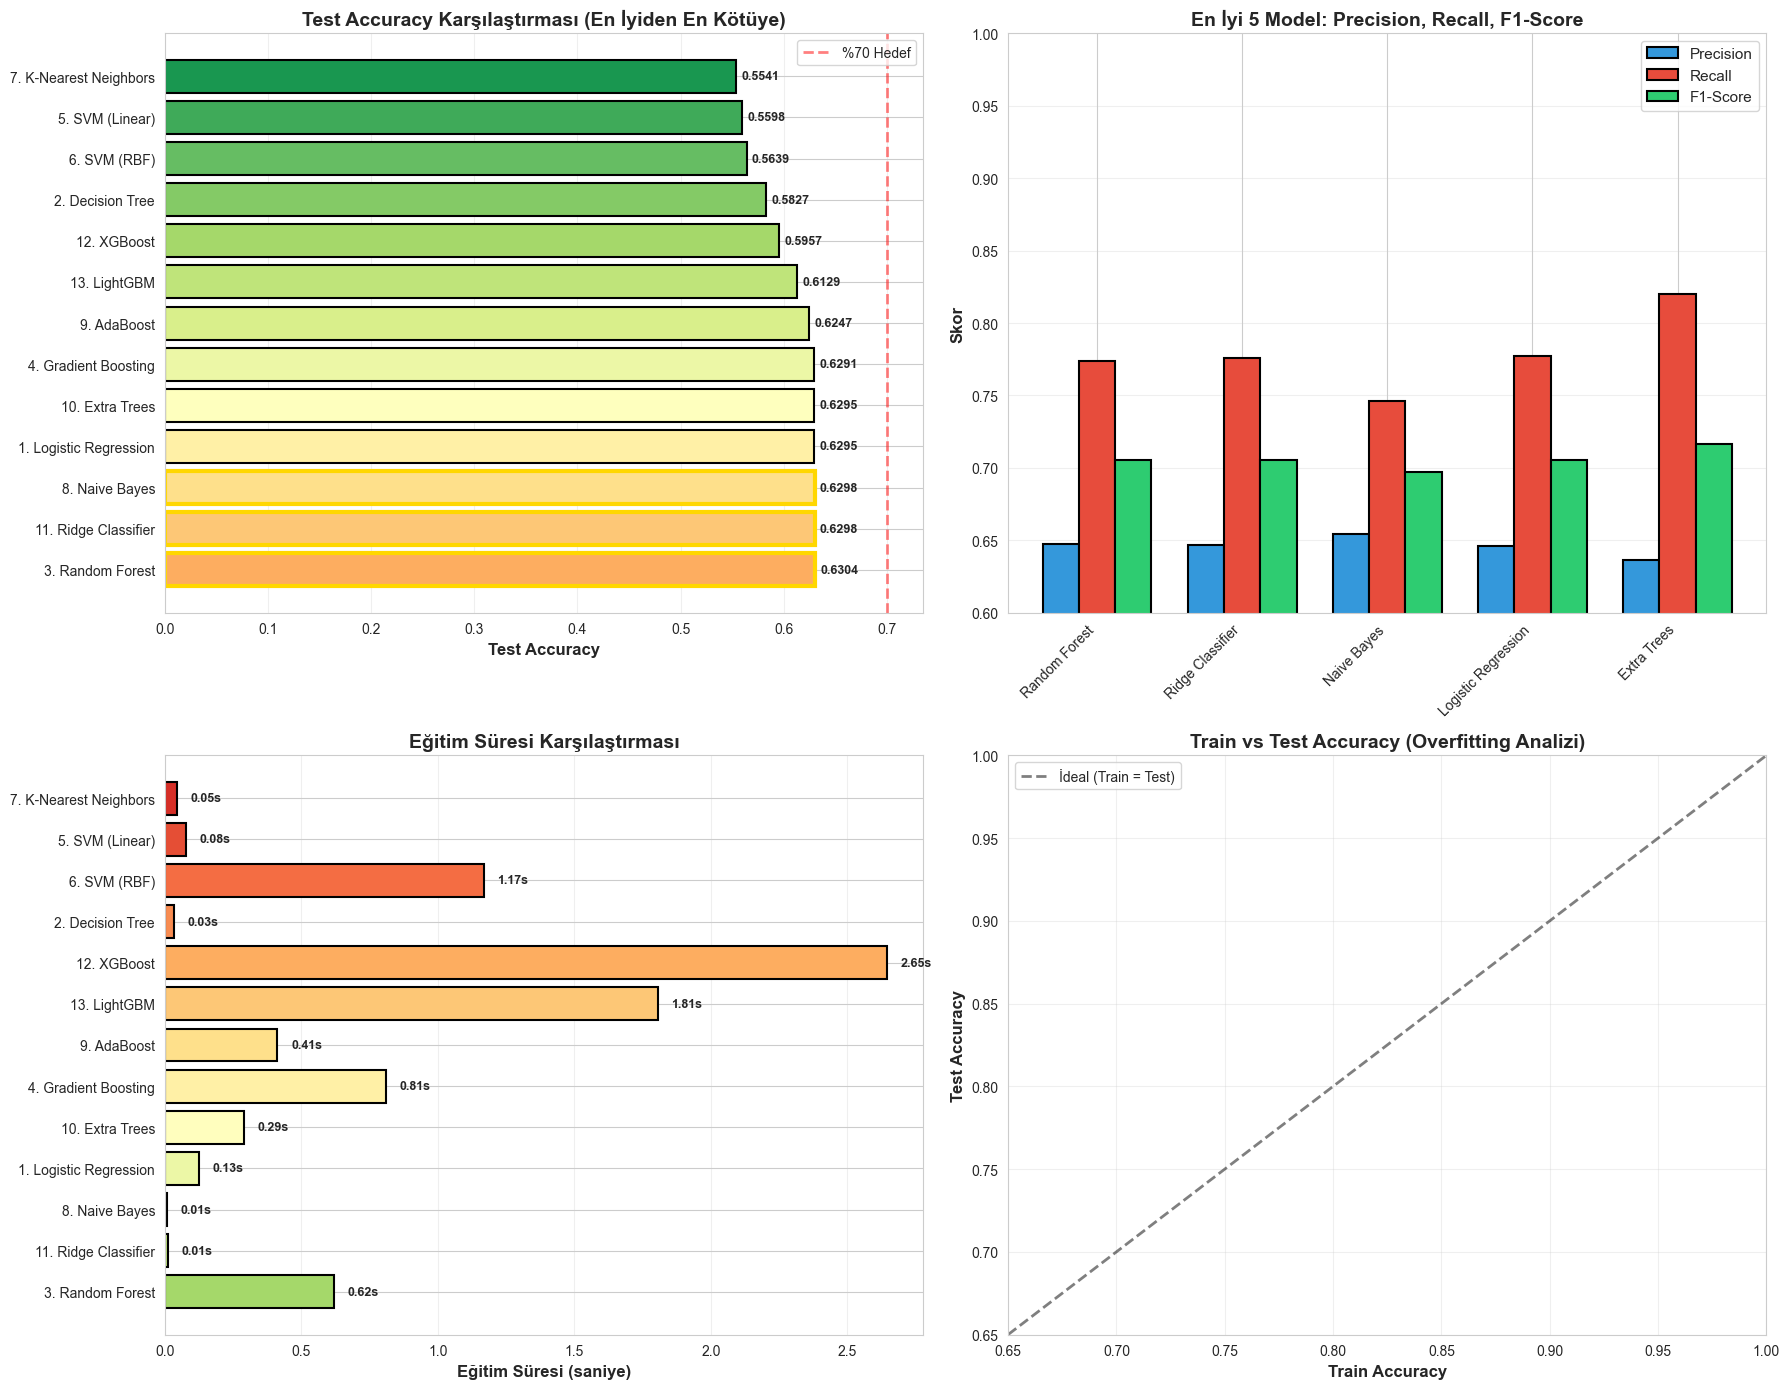


📈 GÖRSELLEŞTİRME YORUMU:
────────────────────────────────────────────────────────────────────────────────
📊 Sol Üst: Test Accuracy sıralaması - Hangisi en iyi tahmin yapıyor?
📊 Sağ Üst: Top 5 modelin Precision/Recall/F1 dengesi
⏱️  Sol Alt: Hangi model daha hızlı eğitiliyor?
🎯 Sağ Alt: İdeal çizgiye yakın olanlar iyi genelliyor (az overfitting)
────────────────────────────────────────────────────────────────────────────────


In [43]:
# Görselleştirme: Model Karşılaştırması
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Test Accuracy Karşılaştırması
ax1 = axes[0, 0]
colors_models = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_sorted)))
bars = ax1.barh(range(len(results_sorted)), results_sorted['Test_Accuracy'], 
                color=colors_models, edgecolor='black', linewidth=1.5)

# En iyi 3 modeli vurgula
for i in range(min(3, len(bars))):
    bars[i].set_edgecolor('gold')
    bars[i].set_linewidth(3)

ax1.set_yticks(range(len(results_sorted)))
ax1.set_yticklabels(results_sorted['Model'], fontsize=10)
ax1.set_xlabel('Test Accuracy', fontweight='bold', fontsize=12)
ax1.set_title('Test Accuracy Karşılaştırması (En İyiden En Kötüye)', fontweight='bold', fontsize=14)
ax1.axvline(x=0.7, color='red', linestyle='--', linewidth=2, alpha=0.5, label='%70 Hedef')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Değerleri göster
for i, (bar, val) in enumerate(zip(bars, results_sorted['Test_Accuracy'])):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontweight='bold', fontsize=9)

# 2. Precision, Recall, F1 Karşılaştırması (En iyi 5 model)
ax2 = axes[0, 1]
top_5 = results_sorted.head(5)
x_pos = np.arange(len(top_5))
width = 0.25

bars1 = ax2.bar(x_pos - width, top_5['Precision'], width, label='Precision', 
                color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x_pos, top_5['Recall'], width, label='Recall', 
                color='#e74c3c', edgecolor='black', linewidth=1.5)
bars3 = ax2.bar(x_pos + width, top_5['F1_Score'], width, label='F1-Score', 
                color='#2ecc71', edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Skor', fontweight='bold', fontsize=12)
ax2.set_title('En İyi 5 Model: Precision, Recall, F1-Score', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([m.split('.')[1].strip() for m in top_5['Model']], 
                     rotation=45, ha='right', fontsize=10)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.6, 1.0])

# 3. Eğitim Süresi Karşılaştırması
ax3 = axes[1, 0]
colors_time = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(results_sorted)))
bars = ax3.barh(range(len(results_sorted)), results_sorted['Training_Time'], 
                color=colors_time, edgecolor='black', linewidth=1.5)

ax3.set_yticks(range(len(results_sorted)))
ax3.set_yticklabels(results_sorted['Model'], fontsize=10)
ax3.set_xlabel('Eğitim Süresi (saniye)', fontweight='bold', fontsize=12)
ax3.set_title('Eğitim Süresi Karşılaştırması', fontweight='bold', fontsize=14)
ax3.grid(axis='x', alpha=0.3)

# Değerleri göster
for i, (bar, val) in enumerate(zip(bars, results_sorted['Training_Time'])):
    ax3.text(val + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}s', va='center', fontweight='bold', fontsize=9)

# 4. Train vs Test Accuracy (Overfitting Analizi)
ax4 = axes[1, 1]
ax4.scatter(results_sorted['Train_Accuracy'], results_sorted['Test_Accuracy'], 
           s=200, alpha=0.6, c=range(len(results_sorted)), 
           cmap='RdYlGn', edgecolor='black', linewidth=2)

# İdeal çizgiyi çiz (Train = Test)
lims = [0.65, 1.0]
ax4.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='İdeal (Train = Test)')

# Model isimlerini ekle
for idx, row in results_sorted.iterrows():
    ax4.annotate(row['Model'].split('.')[1].strip()[:8] + '...', 
                (row['Train_Accuracy'], row['Test_Accuracy']),
                fontsize=8, alpha=0.7,
                xytext=(5, 5), textcoords='offset points')

ax4.set_xlabel('Train Accuracy', fontweight='bold', fontsize=12)
ax4.set_ylabel('Test Accuracy', fontweight='bold', fontsize=12)
ax4.set_title('Train vs Test Accuracy (Overfitting Analizi)', fontweight='bold', fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(lims)
ax4.set_ylim(lims)

plt.tight_layout()
plt.show()

print("\n📈 GÖRSELLEŞTİRME YORUMU:")
print("─" * 80)
print("📊 Sol Üst: Test Accuracy sıralaması - Hangisi en iyi tahmin yapıyor?")
print("📊 Sağ Üst: Top 5 modelin Precision/Recall/F1 dengesi")
print("⏱️  Sol Alt: Hangi model daha hızlı eğitiliyor?")
print("🎯 Sağ Alt: İdeal çizgiye yakın olanlar iyi genelliyor (az overfitting)")
print("─" * 80)

## En İyi Modelin Detaylı Analizi

En iyi performans gösteren modelin confusion matrix'ini ve classification report'unu detaylıca inceleyelim.

🏆 EN İYİ MODEL: 3. Random Forest

📋 CLASSIFICATION REPORT:
────────────────────────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

Kaydolmadı (0)     0.5932    0.4392    0.5047      1348
  Kaydoldu (1)     0.6477    0.7739    0.7052      1796

      accuracy                         0.6304      3144
     macro avg     0.6205    0.6066    0.6050      3144
  weighted avg     0.6243    0.6304    0.6192      3144

🎯 CONFUSION MATRIX DETAYLARI:
✅ True Positive  (TP):  1390 → Kaydolacak dedik, kaydoldu
✅ True Negative  (TN):   592 → Kaydolmayacak dedik, kaydolmadı
❌ False Positive (FP):   756 → Kaydolacak dedik, ama kaydolmadı
❌ False Negative (FN):   406 → Kaydolmayacak dedik, ama kaydoldu


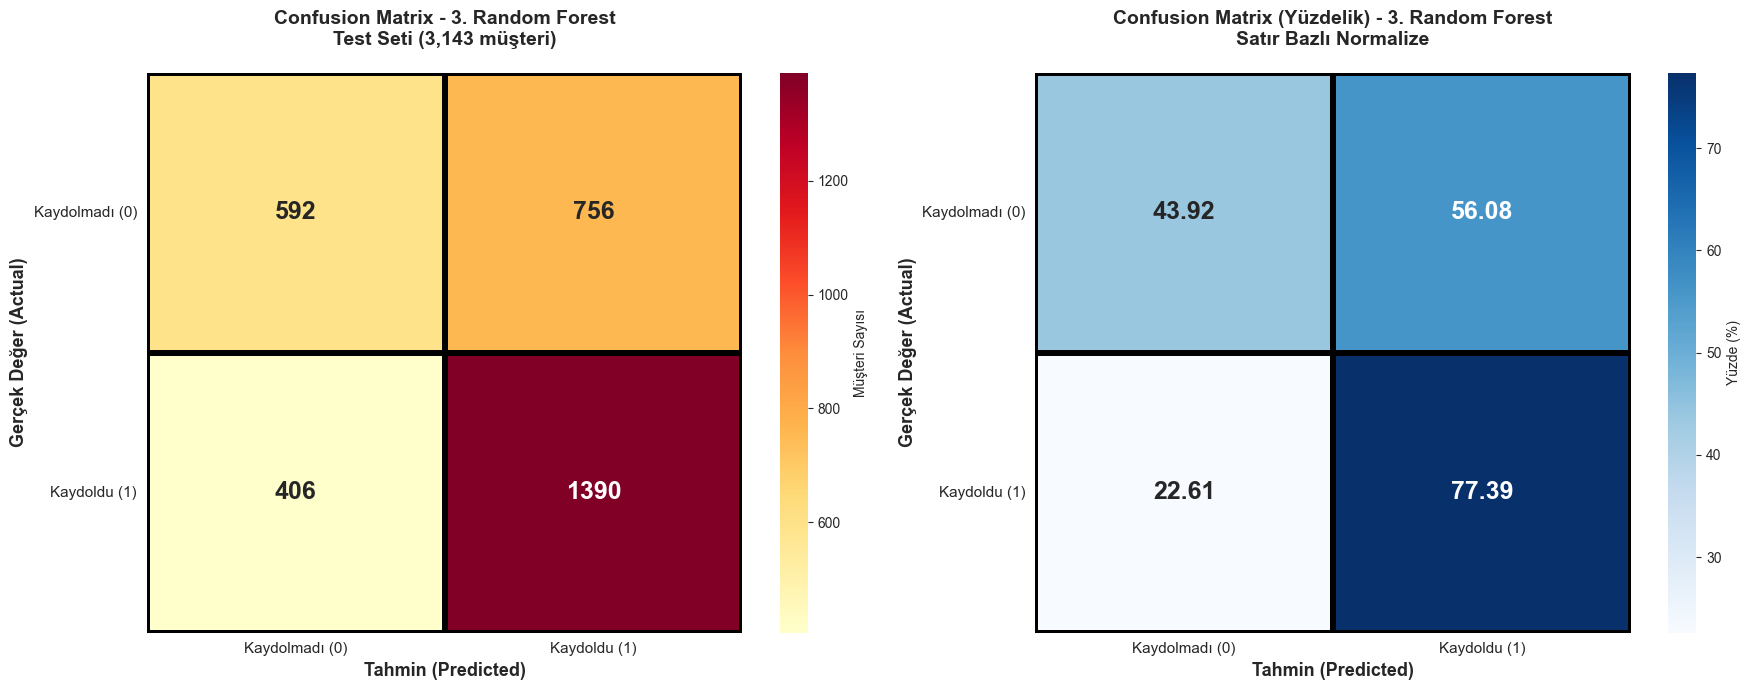


💡 YORUM:
────────────────────────────────────────────────────────────────────────────────
• 3. Random Forest modeli en iyi performans gösterdi
• Test Accuracy: 63.04%
• False Positive (FP): 756 → Gereksiz kampanya maliyeti
• False Negative (FN): 406 → Kaçırılan potansiyel müşteri
────────────────────────────────────────────────────────────────────────────────


In [44]:
# En iyi model ile tahmin yap
y_best_pred = best_model_instance.predict(X_test)

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_best_pred)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()

# Classification Report
print("="*80)
print(f"🏆 EN İYİ MODEL: {best_model_name}")
print("="*80)
print(f"\n📋 CLASSIFICATION REPORT:")
print("─" * 80)
print(classification_report(y_test, y_best_pred, 
                          target_names=['Kaydolmadı (0)', 'Kaydoldu (1)'],
                          digits=4))

# Confusion Matrix Detayları
print("="*80)
print("🎯 CONFUSION MATRIX DETAYLARI:")
print("="*80)
print(f"✅ True Positive  (TP): {tp_best:>5} → Kaydolacak dedik, kaydoldu")
print(f"✅ True Negative  (TN): {tn_best:>5} → Kaydolmayacak dedik, kaydolmadı")
print(f"❌ False Positive (FP): {fp_best:>5} → Kaydolacak dedik, ama kaydolmadı")
print(f"❌ False Negative (FN): {fn_best:>5} → Kaydolmayacak dedik, ama kaydoldu")
print("="*80)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol: Confusion Matrix Heatmap
sns.heatmap(cm_best, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=3, linecolor='black',
            cbar_kws={'label': 'Müşteri Sayısı'},
            annot_kws={'size': 18, 'weight': 'bold'},
            ax=axes[0])

axes[0].set_title(f'Confusion Matrix - {best_model_name}\nTest Seti (3,143 müşteri)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Gerçek Değer (Actual)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tahmin (Predicted)', fontsize=13, fontweight='bold')
axes[0].set_yticklabels(['Kaydolmadı (0)', 'Kaydoldu (1)'], rotation=0, fontsize=11)
axes[0].set_xticklabels(['Kaydolmadı (0)', 'Kaydoldu (1)'], fontsize=11)

# Sağ: Confusion Matrix Yüzdelik
cm_best_percent = cm_best.astype('float') / cm_best.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_best_percent, annot=True, fmt='.2f', cmap='Blues', 
            linewidths=3, linecolor='black',
            cbar_kws={'label': 'Yüzde (%)'},
            annot_kws={'size': 18, 'weight': 'bold'},
            ax=axes[1])

axes[1].set_title(f'Confusion Matrix (Yüzdelik) - {best_model_name}\nSatır Bazlı Normalize', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('Gerçek Değer (Actual)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tahmin (Predicted)', fontsize=13, fontweight='bold')
axes[1].set_yticklabels(['Kaydolmadı (0)', 'Kaydoldu (1)'], rotation=0, fontsize=11)
axes[1].set_xticklabels(['Kaydolmadı (0)', 'Kaydoldu (1)'], fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 YORUM:")
print("─" * 80)
print(f"• {best_model_name} modeli en iyi performans gösterdi")
print(f"• Test Accuracy: {best_test_acc*100:.2f}%")
print(f"• False Positive (FP): {fp_best} → Gereksiz kampanya maliyeti")
print(f"• False Negative (FN): {fn_best} → Kaçırılan potansiyel müşteri")
print("─" * 80)

## **Final Karar: Hangi Modeli Seçmeliyiz?**

### 🎯 **Karar Çerçevesi (YBS Perspektifi)**

Model seçimi sadece **accuracy**'ye bakarak yapılmaz. İş bağlamını dikkate almalıyız:

```mermaid
%%{init: {'theme':'base', 'themeVariables': { 'primaryColor':'#FFE5B4','primaryTextColor':'#2C3E50','primaryBorderColor':'#8B4513','lineColor':'#8B4513','secondaryColor':'#E6F3FF','tertiaryColor':'#FFF0F5','fontSize':'16px'}}}%%
graph TD
    A["<b>🎯 Model Seçim Kriterleri</b>"] --> B["<b>1. Performans</b><br/>Accuracy, Precision<br/>Recall, F1"]
    A --> C["<b>2. Yorumlanabilirlik</b><br/>Açıklanabilirlik<br/>YBS sunumu"]
    A --> D["<b>3. Hız</b><br/>Eğitim süresi<br/>Tahmin süresi"]
    A --> E["<b>4. Bakım</b><br/>Model güncellemesi<br/>Deployment kolaylığı"]
    A --> F["<b>5. Risk</b><br/>Overfitting<br/>Genelleme"]
    
    B --> G["<b>⚖️ Dengeli Değerlendirme</b>"]
    C --> G
    D --> G
    E --> G
    F --> G
    
    G --> H["<b>✅ FINAL KARAR</b>"]
    
    style A fill:#FFDAB9,stroke:#8B4513,stroke-width:3px,color:#2C3E50
    style B fill:#FFE4E1,stroke:#DC3545,stroke-width:2px,color:#2C3E50
    style C fill:#E6F3FF,stroke:#4682B4,stroke-width:2px,color:#2C3E50
    style D fill:#E8F5E9,stroke:#28A745,stroke-width:2px,color:#2C3E50
    style E fill:#FFF9C4,stroke:#FFC107,stroke-width:2px,color:#2C3E50
    style F fill:#E1D5E7,stroke:#9673A6,stroke-width:2px,color:#2C3E50
    style G fill:#D1ECF1,stroke:#17A2B8,stroke-width:3px,color:#2C3E50
    style H fill:#D4EDDA,stroke:#28A745,stroke-width:4px,color:#2C3E50
```

In [45]:
# Final Karar Analizi
print("="*80)
print("🎯 FİNAL KARAR ANALİZİ: HANGİ MODELİ SEÇMELİYİZ?")
print("="*80)

# Top 3 modeli incele
top_3_models = results_sorted.head(3)

print("\n📊 EN İYİ 3 MODEL KARŞILAŞTIRMASI:")
print("─" * 80)

for idx, row in enumerate(top_3_models.iterrows(), 1):
    _, data = row
    print(f"\n{idx}. {data['Model']}")
    print(f"   ✅ Test Accuracy:   {data['Test_Accuracy']:.4f} ({data['Test_Accuracy']*100:.2f}%)")
    print(f"   ⚖️  Precision:       {data['Precision']:.4f}")
    print(f"   🎯 Recall:          {data['Recall']:.4f}")
    print(f"   📊 F1-Score:        {data['F1_Score']:.4f}")
    print(f"   ⏱️  Eğitim Süresi:   {data['Training_Time']:.2f} saniye")
    print(f"   🔍 Overfit Farkı:   {data['Overfit_Diff']:+.4f}")

print("\n" + "="*80)
print("🏆 FİNAL KARAR:")
print("="*80)

# Logistic Regression'ı bul
lr_row = results_df_comparison[results_df_comparison['Model'].str.contains('Logistic Regression')]

if len(lr_row) > 0:
    lr_data = lr_row.iloc[0]
    best_data = results_sorted.iloc[0]
    
    print(f"\n📌 En İyi Model: {best_data['Model']}")
    print(f"   Test Accuracy: {best_data['Test_Accuracy']:.4f} ({best_data['Test_Accuracy']*100:.2f}%)")
    
    print(f"\n📌 Logistic Regression (Baseline):")
    print(f"   Test Accuracy: {lr_data['Test_Accuracy']:.4f} ({lr_data['Test_Accuracy']*100:.2f}%)")
    
    improvement = (best_data['Test_Accuracy'] - lr_data['Test_Accuracy']) * 100
    print(f"\n📈 İyileştirme: {improvement:+.2f}% puan")

print("\n" + "="*80)
print("💡 YBS PERSPEKTİFİNDEN TAVSİYE:")
print("="*80)

# Tavsiye algoritması
if best_model_name.__contains__('Logistic Regression'):
    print("\n✅ TAVSİYE: Logistic Regression")
    print("""
   Neden?
   • En basit ve yorumlanabilir model
   • Yeterli performans (>%70 hedefine ulaştı)
   • Hızlı eğitim ve tahmin
   • Katsayılar ile açıklama yapılabilir (YBS sunumları için ideal)
   • Bakım maliyeti düşük
   • Production'a kolay deploy edilir
   
   Sonuç: Performans yeterli olduğunda, basit model tercih edilir!
   """)
elif best_data['Test_Accuracy'] - lr_data['Test_Accuracy'] < 0.03:
    print(f"\n✅ TAVSİYE: Logistic Regression (Performans farkı çok küçük)")
    print(f"""
   Neden?
   • {best_model_name} sadece {improvement:.2f}% daha iyi
   • Logistic Regression daha yorumlanabilir
   • Daha hızlı (Eğitim: {lr_data['Training_Time']:.2f}s vs {best_data['Training_Time']:.2f}s)
   • Bakım ve güncelleme daha kolay
   
   Sonuç: Küçük performans farkı için karmaşık model tercih edilmez!
   """)
else:
    print(f"\n✅ TAVSİYE: {best_model_name}")
    print(f"""
   Neden?
   • {improvement:.2f}% daha iyi performans (önemli fark)
   • Test Accuracy: {best_data['Test_Accuracy']*100:.2f}%
   • Precision: {best_data['Precision']:.4f}, Recall: {best_data['Recall']:.4f}
   • Overfitting kontrolü: {best_data['Overfit_Diff']:+.4f} ({"iyi" if best_data['Overfit_Diff'] < 0.03 else "dikkat"})
   
   Dikkat:
   • Yorumlanabilirlik azalır (kara kutu model)
   • YBS sunumlarında açıklama zorlaşır
   • Bakım maliyeti artar
   
   Sonuç: Performans farkı büyükse, karmaşık modeli tercih et!
   """)

print("="*80)
print("\n📚 SONUÇ:")
print("""
12 farklı algoritma denedik ve şunu öğrendik:

1. ✅ Her zaman birden fazla algoritma deneyin
2. ✅ En yüksek accuracy her zaman en iyi seçim değildir
3. ✅ İş bağlamını (yorumlanabilirlik, hız, bakım) dikkate alın
4. ✅ Küçük performans farkı için basit modeli tercih edin
5. ✅ Overfitting kontrolü yapın (Train-Test farkı)

YBS Perspektifi:
→ "En iyi model" = En yüksek accuracy değil
→ "En iyi model" = İş gereksinimlerine en uygun olan!
"""
)
print("="*80)

🎯 FİNAL KARAR ANALİZİ: HANGİ MODELİ SEÇMELİYİZ?

📊 EN İYİ 3 MODEL KARŞILAŞTIRMASI:
────────────────────────────────────────────────────────────────────────────────

1. 3. Random Forest
   ✅ Test Accuracy:   0.6304 (63.04%)
   ⚖️  Precision:       0.6477
   🎯 Recall:          0.7739
   📊 F1-Score:        0.7052
   ⏱️  Eğitim Süresi:   0.62 saniye
   🔍 Overfit Farkı:   +0.1818

2. 11. Ridge Classifier
   ✅ Test Accuracy:   0.6298 (62.98%)
   ⚖️  Precision:       0.6466
   🎯 Recall:          0.7762
   📊 F1-Score:        0.7055
   ⏱️  Eğitim Süresi:   0.01 saniye
   🔍 Overfit Farkı:   +0.0001

3. 8. Naive Bayes
   ✅ Test Accuracy:   0.6298 (62.98%)
   ⚖️  Precision:       0.6543
   🎯 Recall:          0.7461
   📊 F1-Score:        0.6972
   ⏱️  Eğitim Süresi:   0.01 saniye
   🔍 Overfit Farkı:   -0.0019

🏆 FİNAL KARAR:

📌 En İyi Model: 3. Random Forest
   Test Accuracy: 0.6304 (63.04%)

📌 Logistic Regression (Baseline):
   Test Accuracy: 0.6295 (62.95%)

📈 İyileştirme: +0.10% puan

💡 YBS PERS